# SLA Prediction
**Upper Gulf of Thailand · monthly Sea Level Anomaly (SLA)**

พยากรณ์ SLA ล่วงหน้า **1 เดือน (t+1)** ของ **4 สถานี** ในอ่าวไทยตอนบน
เปรียบเทียบ 3 โมเดลบน **ข้อมูล / split / target / forecast horizon ชุดเดียวกัน**:
  1. **SARIMA** (Seasonal Autoregressive Integrated Moving Average) — univariate SLA
  2. **Random Forest Regression (RF)** — ตารางฟีเจอร์ (SLA lag + ERA5 + สัญญาณฤดูกาล)
  3. **Single-layer LSTM** — sequence ย้อนหลัง 12 เดือน

ทุกอย่างที่อาจทำให้การเปรียบเทียบลำเอียงถูกกำหนดให้เหมือนกันตั้งแต่ต้น
และมี runtime `assert` ตรวจเงื่อนไขเหล่านั้นให้เห็นสด ๆ ระหว่างรัน

https://www.geeksforgeeks.org/machine-learning/sarima-seasonal-autoregressive-integrated-moving-average/

ค่า SLA ของเดือนนี้อาจสัมพันธ์กับค่า SLA ของเดือนเดียวกันเมื่อปีที่แล้ว
มกราคม 2024 อาจสัมพันธ์กับมกราคม 2023
กรกฎาคม 2024 อาจสัมพันธ์กับกรกฎาคม 2023
รูปแบบการเขียน SARIMA

SARIMA มักเขียนว่า
SARIMA(p,d,q)(P,D,Q)s

แบ่งเป็นสองส่วน

ส่วนปกติ (p,d,q)
p คือจำนวนค่าในอดีตที่นำมาใช้ เช่น SLA เดือนก่อนหน้า
d คือจำนวนครั้งที่หาผลต่าง เพื่อทำให้ข้อมูลนิ่ง
q คือจำนวนค่าความผิดพลาดในอดีตที่นำมาใช้
ส่วนฤดูกาล (P,D,Q)s
	​
P คือความสัมพันธ์กับค่าฤดูกาลในอดีต
D คือการหาผลต่างตามฤดูกาล
Q คือความผิดพลาดตามฤดูกาลในอดีต
s คือความยาวของฤดูกาล

สำหรับข้อมูลรายเดือนที่มีรูปแบบวนซ้ำทุกปี:
s=12

ตัวอย่าง:
SARIMA(1,1,1)(1,1,1)
12
หมายความว่าโมเดลใช้ทั้ง:

ความสัมพันธ์กับเดือนก่อนหน้า
การเปลี่ยนแปลงของข้อมูล
ความผิดพลาดที่ผ่านมา
ความสัมพันธ์กับเดือนเดียวกันเมื่อ 12 เดือนก่อน

In [1]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")   # quiet TF info/warnings
import random
import numpy as np


def set_global_seed(seed: int = 42) -> None:
    """ตั้ง seed ให้ Python / NumPy / TensorFlow พร้อมกัน — ใช้ seed เดียวทั้งโน้ตบุ๊ก
    (Random Forest รับ seed ผ่าน random_state=SEED โดยตรง)"""
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["TF_DETERMINISTIC_OPS"] = "1"      # legacy flag (TF < 2.8)
    random.seed(seed)
    np.random.seed(seed)
    try:
        import tensorflow as tf
        tf.keras.utils.set_random_seed(seed)      # seeds python/numpy/tf at once
        try:
            tf.config.experimental.enable_op_determinism()  # TF >= 2.8
        except Exception:
            pass
    except ImportError:
        pass


SEED = 42
set_global_seed(SEED)


# ฟอนต์ภาษาไทยสำหรับกราฟทั้งโน้ตบุ๊ก
# ฟอนต์ default ของ matplotlib (DejaVu Sans) ไม่มีอักขระไทย → ข้อความไทยกลายเป็นกล่อง
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Tahoma", "Leelawadee UI", "Segoe UI", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False   # เครื่องหมายลบบนแกนใช้ "-" ปกติ กันเป็นกล่อง

***ตั้งค่าไฟล์โปรเจค***

In [2]:
from pathlib import Path

# หาโฟลเดอร์โปรเจกต์เอง โดยดูว่า "ที่ไหนมีไฟล์ข้อมูลจริง" ไม่ใช่เดาจาก path ที่พิมพ์ไว้
# (เดิม hard-code r"D:\defence_sla" → พังทันทีเมื่อย้าย/ก็อปโปรเจกต์ไปโฟลเดอร์อื่น
#  และ mkdir ยังสร้างโฟลเดอร์เปล่าผิดที่ให้อีก ทำให้ error ชี้ไปโฟลเดอร์ที่ว่างเปล่า)
DATA_MARKER = Path("Rawdata") / "sla_monthly_1993_2024.nc"


def find_project_dir(start: Path = None) -> Path:
    """ไล่หาโฟลเดอร์โปรเจกต์จากโฟลเดอร์ปัจจุบันขึ้นไปทีละชั้น
    แต่ละชั้นเช็คทั้งตัวมันเองและโฟลเดอร์ลูกชั้นเดียว (เผื่อโปรเจกต์ซ้อนชื่อเดียวกัน)"""
    here = (start or Path.cwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / DATA_MARKER).exists():
            return cand
        try:
            for sub in sorted(p for p in cand.iterdir() if p.is_dir()):
                if (sub / DATA_MARKER).exists():
                    return sub
        except PermissionError:
            continue
    raise FileNotFoundError(
        f"หา {DATA_MARKER} ไม่เจอ (เริ่มค้นจาก {here})\n"
        "ถ้าเก็บข้อมูลไว้ที่อื่น ให้กำหนดเองตรงนี้: BASE_DIR = Path(r'...')")


BASE_DIR   = find_project_dir()                      # โฟลเดอร์หลักของโปรเจกต์
RAW_DIR    = BASE_DIR / "Rawdata"                    # ไฟล์ .nc (sla / era5)
OUT_DIR    = BASE_DIR / "outputs_fair_comparison"    # ผลลัพธ์ (ตาราง/กราฟ)
EXPORT_DIR = BASE_DIR / "train_model_final"          # ตารางฟีเจอร์ต่อสถานี

# สร้างเฉพาะโฟลเดอร์ผลลัพธ์ — ไม่สร้าง Rawdata เปล่า ๆ (กันโฟลเดอร์หลอกผิดที่แบบเดิม)
for d in [OUT_DIR, EXPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("BASE_DIR :", BASE_DIR)
for f in ["sla_monthly_1993_2024.nc", "era5_monthly_1993_2024.nc"]:
    p = RAW_DIR / f
    print(("พบไฟล์  : " if p.exists() else "ไม่พบไฟล์: ") + str(p))


BASE_DIR : D:\defence_sla_WSL_backup
พบไฟล์  : D:\defence_sla_WSL_backup\Rawdata\sla_monthly_1993_2024.nc
พบไฟล์  : D:\defence_sla_WSL_backup\Rawdata\era5_monthly_1993_2024.nc


#ติดตั้งไลบรารี (Python packages) ที่ใช้ในการทำงานด้านข้อมูลภูมิสารสนเทศ (GIS) และการสร้างแผนที่

ใช้สำหรับดึง Base map ลงกราฟ Matplotlib

In [3]:
# ติดตั้ง libraries
# !pip install geopandas folium shapely matplotlib-scalebar contextily

import geopandas as gpd            # จัดการข้อมูลภูมิศาสตร์ (shapefile, GeoJSON)
import folium                      # สร้างแผนที่
from folium import plugins         # plugins เสริม (fullscreen, minimap, measure)
from shapely.geometry import Point, Polygon, box   # สร้าง geometry
import matplotlib.pyplot as plt    # วาดกราฟ / scale bar
from matplotlib.patches import Rectangle
import numpy as np

print("Geospatial libraries loaded")
print(f"   geopandas: {gpd.__version__}")
print(f"   folium:    {folium.__version__}")

Geospatial libraries loaded
   geopandas: 1.1.4
   folium:    0.20.0


**กำหนดขอบเขตพื้นที่ศึกษา 4 สถานีอ่าวไทย**

In [4]:
import os
from pathlib import Path

# ต้องรันเซลล์ "ตั้งค่าโฟลเดอร์โปรเจกต์ (BASE_DIR)" ก่อนเซลล์นี้ — path ทั้งหมดอ้างจากตรงนั้น
try:
    BASE_DIR, RAW_DIR, OUT_DIR
except NameError:
    raise RuntimeError(
        "ยังไม่มี BASE_DIR — ให้รันเซลล์ 'ตั้งค่าโฟลเดอร์โปรเจกต์ (BASE_DIR)' ก่อนเซลล์นี้")

CONFIG = {

    # 1. Study stations: Upper Gulf of Thailand

    "stations": {
        "Wat Khun Samut Chin": {
            "lat": 13.5061216,
            "lon": 100.5312743,
        },
        "Laem Chabang Port": {
            "lat": 13.047551,
            "lon": 100.868826,
        },
        "Upper Gulf Offshore": {
            "lat": 12.6250,
            "lon": 100.3750,
        },
        "Phetchaburi Bangkawe": {
            "lat": 13.099714,
            "lon": 100.065466,
        },
    },


    # 2. Spatial averaging

    # เลือกข้อมูลภายใน +/-0.25 องศา จากพิกัดสถานี (พื้นที่รวมประมาณ 0.5 x 0.5 องศา)
    # NB: โค้ดในโน้ตบุ๊กเรียกด้วยคีย์ตัวใหญ่ CONFIG["BUFFER"]
    "BUFFER": 0.25,


    # 3. Forecast settings

    # LSTM ใช้ข้อมูลย้อนหลังต่อเนื่อง 12 เดือน
    "lookback": 12,

    # ทุกโมเดลใช้ข้อมูลที่มีถึงเดือน t เพื่อพยากรณ์ SLA เดือน t+1
    "forecast_horizon": 1,

    # คาบฤดูกาลของข้อมูลรายเดือน
    "seasonal_period": 12,


    # 4. Temporal split

    "train_start": "1993-01-01",
    "train_end":   "2016-12-31",

    "val_start":   "2017-01-01",
    "val_end":     "2019-12-31",

    "test_start":  "2020-01-01",
    "test_end":    "2024-12-31",


    # 5. Data paths — อ้างจาก BASE_DIR ที่ตรวจหาอัตโนมัติ (ห้าม hard-code absolute path)

    "sla_path":   str(RAW_DIR / "sla_monthly_1993_2024.nc"),

    "era5_path":  str(RAW_DIR / "era5_monthly_1993_2024.nc"),

    "output_dir": str(OUT_DIR),
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)


# 6. Features / target ที่ build_dataset() สร้างขึ้น
#    (โค้ดใช้ FEATURE_COLS / TARGET_COL แต่เดิมไม่มีเซลล์นิยาม จึงเติมให้ตรงนี้)

FEATURE_COLS = [
    "SLA_hist",                              # SLA เดือนปัจจุบัน (t)
    "SST", "SLP", "u10", "v10",              # ตัวขับจาก ERA5
    "SLA_lag1", "SLA_lag3", "SLA_lag6", "SLA_lag12",
    "month_sin", "month_cos",                # ฤดูกาล
]

TARGET_COL = "SLA_target"                    # SLA เดือน t + forecast_horizon


# 7. Feature sets แยกต่อโมเดล — preprocessing แยกตามธรรมชาติของแต่ละโมเดล
#
#    SARIMA : univariate — ใช้อนุกรม SLA ล้วน (build_sarima_series)
#             ไม่ผ่าน lag column / dropna ของ RF จึงเริ่มได้ตั้งแต่ Jan 1993
#
#    RF     : ตารางฟีเจอร์เต็มจาก build_dataset() — คงเดิมทุกประการ
#             มี SLA_lag1/3/6/12 เพราะ tree ไม่มีความจำ ต้องป้อนค่าย้อนหลังเป็นคอลัมน์
#             ผลข้างเคียงคือ dropna(SLA_lag12) ตัดข้อมูล 12 เดือนแรกทิ้ง (target เริ่ม Feb 1994)
#
#    LSTM   : build_lstm_dataset() — ไม่มี lag column
#             เพราะ LSTM เห็นค่าย้อนหลังผ่าน sliding sequence 12 เดือนอยู่แล้ว
#             (lag k = SLA_hist ที่ timestep t-k ภายใน window เดียวกัน = ข้อมูลซ้ำ)
#             การเอา SLA_lag12 ออกทำให้ไม่ถูก dropna ของ RF ตัดหัวอนุกรมทิ้งโดยไม่จำเป็น

RF_FEATURE_COLS = [
    "SLA_hist",                              # SLA เดือนปัจจุบัน (t)
    "SST", "SLP", "u10", "v10",              # ตัวขับจาก ERA5
    "SLA_lag1", "SLA_lag3", "SLA_lag6", "SLA_lag12",   # ค่าย้อนหลัง
    "month_sin", "month_cos",                # ฤดูกาล
]

LSTM_FEATURE_COLS = [
    "SLA_hist",                              # SLA เดือนปัจจุบัน (t)
    "SST", "SLP", "u10", "v10",              # ตัวขับจาก ERA5
    "month_sin", "month_cos",                # ฤดูกาล
]

# กันพลาด: ฟีเจอร์ของ RF ต้องเป็นชุดเดียวกับที่ build_dataset() สร้างไว้
assert set(RF_FEATURE_COLS) <= set(FEATURE_COLS), (
    "RF_FEATURE_COLS มีคอลัมน์ที่ build_dataset() ไม่ได้สร้าง")
assert set(LSTM_FEATURE_COLS) <= set(FEATURE_COLS), (
    "LSTM_FEATURE_COLS มีคอลัมน์ที่ build_lstm_dataset() ไม่ได้สร้าง")

# RF ต้องยังมี lag ครบ / LSTM ต้องไม่มี lag เลย (ไม่งั้น dropna จะกินหัวอนุกรมกลับมาอีก)
assert all(c in RF_FEATURE_COLS for c in
           ["SLA_lag1", "SLA_lag3", "SLA_lag6", "SLA_lag12"]), (
    "RF ต้องคงคอลัมน์ lag ไว้ครบ 4 ตัว")
assert not any(c.startswith("SLA_lag") for c in LSTM_FEATURE_COLS), (
    "LSTM ต้องไม่มี SLA_lag* — ค่าย้อนหลังมาจาก sequence 12 เดือนแล้ว")
assert len(LSTM_FEATURE_COLS) == 7, (
    f"LSTM ต้องใช้ 7 ฟีเจอร์ แต่ได้ {len(LSTM_FEATURE_COLS)}")

print("CONFIG พร้อมใช้งาน:",
      len(CONFIG["stations"]), "สถานี |",
      f"RF {len(RF_FEATURE_COLS)} feat | LSTM {len(LSTM_FEATURE_COLS)} feat |",
      "SARIMA univariate |",
      "target =", TARGET_COL)

CONFIG พร้อมใช้งาน: 4 สถานี | RF 11 feat | LSTM 7 feat | SARIMA univariate | target = SLA_target


**3. DATA LOADING**
- ***เลือก latitude/longitude ตามทิศทาง coordinate จริง***
- ***แปลง SST/SLP ตาม metadata units ไม่ใช้ค่าคงที่แบบ hard-code***

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd


def _find_coord_name(ds, candidates, label):
    """คืนชื่อ coordinate/dimension แรกที่พบจาก candidates."""
    for name in candidates:
        if name in ds.coords or name in ds.dims:
            return name
    raise KeyError(
        f"ไม่พบ coordinate {label}; candidates={candidates}, "
        f"available={list(ds.coords)}"
    )


def _resolve_variable(ds, candidates, label):
    """คืนชื่อตัวแปรจริงจากรายชื่อที่รองรับ."""
    for name in candidates:
        if name in ds.data_vars:
            return name
    raise KeyError(
        f"ไม่พบตัวแปร {label}; candidates={candidates}, "
        f"available={list(ds.data_vars)}"
    )


def coordinate_slice(coord, lower, upper):
    """สร้าง slice ให้ตรงกับทิศทาง ascending/descending ของ coordinate จริง."""
    values = np.asarray(coord.values, dtype=float)
    if values.ndim != 1 or values.size == 0:
        raise ValueError(f"coordinate '{coord.name}' ต้องเป็นข้อมูล 1 มิติและไม่ว่าง")
    if values[0] <= values[-1]:
        return slice(lower, upper)
    return slice(upper, lower)


def _normalise_units(units):
    return str(units or "").strip().lower().replace(" ", "_")


def _sst_to_celsius(series: pd.Series, units, variable_name: str) -> pd.Series:
    """แปลง SST เป็น °C โดยอ้างอิง metadata units เท่านั้น."""
    u = _normalise_units(units)
    kelvin_units = {
        "k", "kelvin", "degree_kelvin", "degrees_kelvin"
    }
    celsius_units = {
        "c", "°c", "degc", "celsius", "degree_celsius", "degrees_celsius",
        "degree_c", "degrees_c"
    }
    if u in kelvin_units:
        return series - 273.15
    if u in celsius_units:
        return series
    raise ValueError(
        f"ไม่รู้จักหน่วย SST ของตัวแปร '{variable_name}': {units!r}. "
        "กรุณาตรวจ metadata ก่อนรันโมเดล"
    )


def _slp_to_hpa(series: pd.Series, units, variable_name: str) -> pd.Series:
    """แปลง SLP เป็น hPa โดยอ้างอิง metadata units เท่านั้น."""
    u = _normalise_units(units)
    pa_units = {"pa", "pascal", "pascals"}
    hpa_units = {
        "hpa", "hectopascal", "hectopascals", "mbar", "millibar", "millibars"
    }
    if u in pa_units:
        return series / 100.0
    if u in hpa_units:
        return series
    raise ValueError(
        f"ไม่รู้จักหน่วย SLP ของตัวแปร '{variable_name}': {units!r}. "
        "กรุณาตรวจ metadata ก่อนรันโมเดล"
    )


def _subset_box(ds, da, lat_c, lon_c, buf):
    """เลือกกริดรอบสถานี โดยรองรับ coordinate ที่เรียงได้ทั้งสองทิศทาง."""
    lat_name = _find_coord_name(ds, ("latitude", "lat"), "latitude")
    lon_name = _find_coord_name(ds, ("longitude", "lon"), "longitude")
    subset = da.sel({
        lat_name: coordinate_slice(ds[lat_name], lat_c - buf, lat_c + buf),
        lon_name: coordinate_slice(ds[lon_name], lon_c - buf, lon_c + buf),
    })
    if subset.sizes.get(lat_name, 0) == 0 or subset.sizes.get(lon_name, 0) == 0:
        raise ValueError(
            f"ไม่พบ grid cell ใน buffer ±{buf}° รอบ ({lat_c}, {lon_c}) "
            f"สำหรับตัวแปร '{da.name}'"
        )
    return subset, lat_name, lon_name


def load_sla(station_info: dict) -> pd.Series:
    """Box-averaged monthly SLA รอบสถานี โดยคงหน่วยตามไฟล์ NetCDF."""
    import xarray as xr

    path = Path(CONFIG["sla_path"])
    if not path.exists():
        raise FileNotFoundError(f"ไม่พบไฟล์ SLA: {path}")

    lat_c = station_info["lat"]
    lon_c = station_info["lon"]
    buf = CONFIG["BUFFER"]

    with xr.open_dataset(path) as ds:
        var_name = _resolve_variable(ds, ("sla",), "SLA")
        subset, lat_name, lon_name = _subset_box(
            ds, ds[var_name], lat_c, lon_c, buf
        )
        spatial_mean = subset.mean(
            dim=[lat_name, lon_name], skipna=True
        ).load()

    sla = spatial_mean.to_series().sort_index()
    sla.name = "SLA"
    return sla


def load_era5(station_info: dict) -> pd.DataFrame:
    """Box-averaged ERA5: SST (°C), SLP (hPa), u10/v10 (หน่วยเดิมจากไฟล์)."""
    import xarray as xr

    path = Path(CONFIG["era5_path"])
    if not path.exists():
        raise FileNotFoundError(f"ไม่พบไฟล์ ERA5: {path}")

    lat_c = station_info["lat"]
    lon_c = station_info["lon"]
    buf = CONFIG["BUFFER"]

    with xr.open_dataset(path) as ds:
        def extract(candidates, label):
            name = _resolve_variable(ds, candidates, label)
            da = ds[name]
            units = da.attrs.get("units")
            subset, lat_name, lon_name = _subset_box(
                ds, da, lat_c, lon_c, buf
            )
            series = subset.mean(
                dim=[lat_name, lon_name], skipna=True
            ).load().to_series().sort_index()
            return series, units, name

        sst_raw, sst_units, sst_name = extract(
            ("sst", "sea_surface_temperature"), "SST"
        )
        slp_raw, slp_units, slp_name = extract(
            ("msl", "mean_sea_level_pressure"), "SLP"
        )
        u10, _, _ = extract(
            ("u10", "10m_u_component_of_wind"), "u10"
        )
        v10, _, _ = extract(
            ("v10", "10m_v_component_of_wind"), "v10"
        )

    sst = _sst_to_celsius(sst_raw, sst_units, sst_name)
    slp = _slp_to_hpa(slp_raw, slp_units, slp_name)

    for series, name in [(sst, "SST"), (slp, "SLP"), (u10, "u10"), (v10, "v10")]:
        series.name = name

    return pd.concat([sst, slp, u10, v10], axis=1).sort_index()


def build_dataset(station_name: str) -> pd.DataFrame:
    info = CONFIG["stations"][station_name]

    df = pd.concat(
        [load_sla(info), load_era5(info)],
        axis=1,
        join="inner"
    ).sort_index()

    h = CONFIG["forecast_horizon"]

    # Features ที่ทราบ ณ เดือน t
    df["SLA_hist"] = df["SLA"]

    for lag in (1, 3, 6, 12):
        df[f"SLA_lag{lag}"] = df["SLA"].shift(lag)

    # Target คือ SLA เดือน t+h
    df[TARGET_COL] = df["SLA"].shift(-h)

    # index ใหม่ต้องเป็นเดือนของ Target (t+h)
    df["target_time"] = (
        df.index.to_period("M") + h
    ).to_timestamp(how="start")

    # สัญญาณฤดูกาลคำนวณจากเดือนของ target_time
    target_month = df["target_time"].dt.month
    df["month_sin"] = np.sin(
        2 * np.pi * target_month / CONFIG["seasonal_period"]
    )
    df["month_cos"] = np.cos(
        2 * np.pi * target_month / CONFIG["seasonal_period"]
    )

    df = df.dropna(subset=FEATURE_COLS + [TARGET_COL]).copy()
    df = df.set_index("target_time").sort_index()
    df.index.name = "time"

    if df.index.duplicated().any():
        duplicated = df.index[df.index.duplicated()].unique()
        raise ValueError(
            f"{station_name}: พบเดือนซ้ำ "
            f"{duplicated.strftime('%Y-%m').tolist()}"
        )

    periods = df.index.to_period("M")
    expected = pd.period_range(periods.min(), periods.max(), freq="M")
    missing_months = expected.difference(periods.unique())
    if len(missing_months) > 0:
        raise ValueError(
            f"{station_name}: พบเดือนขาดหาย "
            f"{[str(p) for p in missing_months]}"
        )

    return df[FEATURE_COLS + [TARGET_COL]]



#  PREPROCESSING แยกตามธรรมชาติของแต่ละโมเดล
#
#      Raw NetCDF
#        ├── spatial averaging SLA
#        │     └── build_sarima_series()  -> SARIMA  (univariate, Jan 1993 เป็นต้นไป)
#        └── spatial averaging SLA + ERA5
#              ├── build_dataset()        -> RF      (มี SLA_lag1/3/6/12 + dropna — ของเดิม)
#              └── build_lstm_dataset()   -> LSTM    (ไม่มี lag column ใช้ sequence 12 เดือน)
#
#  เหตุผล: dropna(SLA_lag12) ของ RF ตัดข้อมูล 12 เดือนแรกทิ้ง ซึ่งจำเป็นสำหรับ RF
#  (tree ไม่มีความจำ ต้องมีค่าย้อนหลังครบทุกคอลัมน์) แต่ไม่จำเป็นสำหรับ SARIMA
#  (ใช้อนุกรมล้วน) และ LSTM (เห็นอดีตผ่าน sliding window อยู่แล้ว)



def _check_monthly_index(index, station_name: str, label: str) -> None:
    """ตรวจ index รายเดือน: เรียงเวลา / ไม่มีเดือนซ้ำ / ไม่มีเดือนขาด"""
    index = pd.DatetimeIndex(index)

    if not index.is_monotonic_increasing:
        raise ValueError(f"{station_name} [{label}]: index ไม่ได้เรียงตามเวลา")

    periods = index.to_period("M")

    if periods.duplicated().any():
        duplicated = periods[periods.duplicated()].unique()
        raise ValueError(
            f"{station_name} [{label}]: พบเดือนซ้ำ "
            f"{[str(p) for p in duplicated]}"
        )

    expected = pd.period_range(periods.min(), periods.max(), freq="M")
    missing_months = expected.difference(periods.unique())
    if len(missing_months) > 0:
        raise ValueError(
            f"{station_name} [{label}]: พบเดือนขาดหาย "
            f"{[str(p) for p in missing_months]}"
        )


def build_sarima_series(station_name: str) -> pd.Series:
    """อนุกรม SLA รายเดือนสำหรับ SARIMA (univariate model)

    - ใช้ SLA จาก load_sla() หลัง spatial averaging โดยตรง
    - index = เดือนจริงของ SLA (ไม่ shift เวลา ไม่มี target_time)
    - ไม่สร้าง lag / ไม่ใช้ ERA5 / ไม่ผ่าน dropna ของ RF
    - ตรวจ NaN, Inf, เดือนซ้ำ, เดือนขาด และเรียงตามเวลา
    ผลที่ควรได้: Jan 1993 – Dec 2024 = 384 เดือนต่อสถานี
    """
    info = CONFIG["stations"][station_name]

    sla = load_sla(info).astype(float)

    # normalise ให้เป็นวันที่ 1 ของเดือน (ไม่เลื่อนเดือน — แค่ทำให้ label สม่ำเสมอ)
    sla.index = pd.DatetimeIndex(sla.index).to_period("M").to_timestamp(how="start")
    sla.index.name = "time"
    sla = sla.sort_index()
    sla.name = "SLA"

    values = sla.to_numpy(dtype=float)

    if np.isnan(values).any():
        bad = sla.index[np.isnan(values)]
        raise ValueError(
            f"{station_name} [SARIMA]: พบ NaN {len(bad)} เดือน "
            f"({bad.strftime('%Y-%m').tolist()[:12]}...)"
        )

    if np.isinf(values).any():
        bad = sla.index[np.isinf(values)]
        raise ValueError(
            f"{station_name} [SARIMA]: พบค่า Inf ที่ "
            f"{bad.strftime('%Y-%m').tolist()}"
        )

    _check_monthly_index(sla.index, station_name, "SARIMA")

    return sla


def build_lstm_dataset(station_name: str) -> pd.DataFrame:
    """ตารางฟีเจอร์สำหรับ LSTM — เหมือน build_dataset() ทุกอย่าง ยกเว้น "ไม่สร้าง lag column"

    สร้างเฉพาะ: SLA_hist, SST, SLP, u10, v10, month_sin, month_cos, SLA_target
    index = target_time (เดือนของค่าที่พยากรณ์) เช่นเดียวกับ build_dataset()
    ผลที่ควรได้: target Feb 1993 – Dec 2024 = 383 แถวต่อสถานี
    (ตัดเฉพาะแถวสุดท้ายของอนุกรมที่ยังไม่มี SLA(t+1) จริง)
    """
    info = CONFIG["stations"][station_name]

    df = pd.concat(
        [load_sla(info), load_era5(info)],
        axis=1,
        join="inner"
    ).sort_index()

    h = CONFIG["forecast_horizon"]

    # Features ที่ทราบ ณ เดือน t  (ไม่มี SLA_lag* — LSTM เห็นอดีตผ่าน sequence)
    df["SLA_hist"] = df["SLA"]

    # Target คือ SLA เดือน t+h
    df[TARGET_COL] = df["SLA"].shift(-h)

    # index ใหม่ต้องเป็นเดือนของ Target (t+h)
    df["target_time"] = (
        df.index.to_period("M") + h
    ).to_timestamp(how="start")

    # สัญญาณฤดูกาลคำนวณจากเดือนของ target_time (นิยามเดียวกับ build_dataset)
    target_month = df["target_time"].dt.month
    df["month_sin"] = np.sin(
        2 * np.pi * target_month / CONFIG["seasonal_period"]
    )
    df["month_cos"] = np.cos(
        2 * np.pi * target_month / CONFIG["seasonal_period"]
    )

    # dropna เฉพาะฟีเจอร์ของ LSTM + target — ไม่มี lag จึงไม่ตัดหัวอนุกรมทิ้ง
    df = df.dropna(subset=LSTM_FEATURE_COLS + [TARGET_COL]).copy()
    df = df.set_index("target_time").sort_index()
    df.index.name = "time"

    assert not any(str(c).startswith("SLA_lag") for c in LSTM_FEATURE_COLS), (
        f"{station_name} [LSTM]: ห้ามมี SLA_lag* ใน LSTM_FEATURE_COLS")

    _check_monthly_index(df.index, station_name, "LSTM")

    out = df[LSTM_FEATURE_COLS + [TARGET_COL]]

    if not np.isfinite(out.to_numpy(dtype=float)).all():
        raise ValueError(f"{station_name} [LSTM]: พบ NaN/Inf ในตารางฟีเจอร์")

    return out

## 3b. ตรวจสอบไฟล์ NetCDF จริงก่อน Feature Engineering

ตรวจไฟล์ SLA และ ERA5 จาก path ใน `CONFIG`: เปิดได้ / มิติ-พิกัด-ตัวแปร / ชื่อตัวแปรจริง + หน่วย / ช่วงเวลา-timestamp ซ้ำ-เดือนขาด / ช่วงเวลาทับซ้อน / ทิศ latitude / grid spacing / จำนวน grid cell ต่อสถานี / NaN-Inf หลังเฉลี่ยเชิงพื้นที่ หากสถานีใดเลือกไม่ได้แม้แต่ 1 cell หรือมีเดือนขาด จะหยุดก่อนฝึกโมเดล

In [6]:
#  3b. NETCDF VALIDATION — ตรวจไฟล์จริงก่อน feature engineering

# หยุดก่อนฝึกโมเดลเมื่อ: ไฟล์หาย, เดือนขาด/ซ้ำ, split อยู่นอกช่วงข้อมูล,
# grid cell เป็นศูนย์, หรือ spatial mean มี NaN/Inf

from pathlib import Path
import os
import numpy as np
import pandas as pd
import xarray as xr

VAR_SPEC = {
    "SLA": ("sla",),
    "SST": ("sst", "sea_surface_temperature"),
    "SLP": ("msl", "mean_sea_level_pressure"),
    "u10": ("u10", "10m_u_component_of_wind"),
    "v10": ("v10", "10m_v_component_of_wind"),
}


def _time_coord(ds):
    return _find_coord_name(ds, ("time", "valid_time", "date"), "time")


def _inspect_file(path, wanted_variables):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"ไม่พบไฟล์ NetCDF: {path}")

    with xr.open_dataset(path) as ds:
        time_name = _time_coord(ds)
        lat_name = _find_coord_name(ds, ("latitude", "lat"), "latitude")
        lon_name = _find_coord_name(ds, ("longitude", "lon"), "longitude")

        idx = pd.DatetimeIndex(pd.to_datetime(ds[time_name].values)).sort_values()
        lat = np.asarray(ds[lat_name].values, dtype=float)
        lon = np.asarray(ds[lon_name].values, dtype=float)

        print(f"\nไฟล์: {path}")
        print(f"  dims      : {dict(ds.sizes)}")
        print(f"  coords    : {list(ds.coords)}")
        print(f"  data_vars : {list(ds.data_vars)}")

        resolved = {}
        units = {}
        for key in wanted_variables:
            var_name = _resolve_variable(ds, VAR_SPEC[key], key)
            resolved[key] = var_name
            units[key] = ds[var_name].attrs.get("units")
            encoding = ds[var_name].encoding
            fill = encoding.get("_FillValue", ds[var_name].attrs.get("_FillValue"))
            missing_value = encoding.get(
                "missing_value", ds[var_name].attrs.get("missing_value")
            )
            print(
                f"  {key:3s} <- '{var_name}'  units={units[key]!r}  "
                f"_FillValue={fill}  missing_value={missing_value}"
            )

    monthly_periods = idx.to_period("M")
    duplicate_months = monthly_periods[monthly_periods.duplicated()].unique()
    expected_months = pd.period_range(
        monthly_periods.min(), monthly_periods.max(), freq="M"
    )
    missing_months = expected_months.difference(monthly_periods.unique())

    lat_diff = np.diff(lat)
    lon_diff = np.diff(lon)
    lat_order = (
        "ascending" if np.all(lat_diff > 0)
        else "descending" if np.all(lat_diff < 0)
        else "not_monotonic"
    )
    lon_order = (
        "ascending" if np.all(lon_diff > 0)
        else "descending" if np.all(lon_diff < 0)
        else "not_monotonic"
    )
    dlat = float(np.nanmedian(np.abs(lat_diff))) if lat_diff.size else np.nan
    dlon = float(np.nanmedian(np.abs(lon_diff))) if lon_diff.size else np.nan

    print(f"  time      : {idx.min():%Y-%m} .. {idx.max():%Y-%m}  (n={len(idx)})")
    print(f"  duplicate months : {[str(p) for p in duplicate_months] or 'ไม่มี'}")
    print(f"  missing months   : {[str(p) for p in missing_months] or 'ไม่มี'}")
    print(
        f"  latitude  : {lat_order}, spacing≈{dlat:.6g}° | "
        f"longitude: {lon_order}, spacing≈{dlon:.6g}°"
    )

    return {
        "path": str(path),
        "time": idx,
        "periods": monthly_periods,
        "lat": lat,
        "lon": lon,
        "lat_name": lat_name,
        "lon_name": lon_name,
        "missing": missing_months,
        "duplicates": duplicate_months,
        "resolved": resolved,
        "units": units,
        "lat_order": lat_order,
        "lon_order": lon_order,
        "dlat": dlat,
        "dlon": dlon,
    }


sla_info = _inspect_file(CONFIG["sla_path"], ["SLA"])
era5_info = _inspect_file(CONFIG["era5_path"], ["SST", "SLP", "u10", "v10"])

# ยืนยันหน่วยที่ฟังก์ชัน load_era5 รองรับก่อนคำนวณจริง
_ = _sst_to_celsius(
    pd.Series([0.0]), era5_info["units"]["SST"], era5_info["resolved"]["SST"]
)
_ = _slp_to_hpa(
    pd.Series([0.0]), era5_info["units"]["SLP"], era5_info["resolved"]["SLP"]
)

# ช่วงเวลาทับซ้อน SLA ∩ ERA5 — เปรียบเทียบระดับเดือน
sla_start = sla_info["periods"].min()
sla_end = sla_info["periods"].max()
era5_start = era5_info["periods"].min()
era5_end = era5_info["periods"].max()
ov_start = max(sla_start, era5_start)
ov_end = min(sla_end, era5_end)
print(f"\nช่วงเวลาทับซ้อน SLA ∩ ERA5 : {ov_start} .. {ov_end}")
if ov_start > ov_end:
    raise RuntimeError("SLA และ ERA5 ไม่มีช่วงเวลาทับซ้อนกัน")

# ช่วง Train–Validation–Test ต้องอยู่ในข้อมูลจริงทั้งหมด
required_start = pd.Period(pd.Timestamp(CONFIG["train_start"]), freq="M")
required_end = pd.Period(pd.Timestamp(CONFIG["test_end"]), freq="M")
if required_start < ov_start or required_end > ov_end:
    raise RuntimeError(
        "ช่วง Train–Validation–Test อยู่นอกช่วงข้อมูลจริง: "
        f"ต้องการ {required_start}..{required_end}, "
        f"แต่ช่วงซ้อนทับมี {ov_start}..{ov_end}"
    )

buf = CONFIG["BUFFER"]


def _cells_in_buffer(info, lat_c, lon_c):
    lat = info["lat"]
    lon = info["lon"]
    n_lat = int(((lat >= lat_c - buf) & (lat <= lat_c + buf)).sum())
    n_lon = int(((lon >= lon_c - buf) & (lon <= lon_c + buf)).sum())
    return n_lat, n_lon, n_lat * n_lon


rows = []
problems = []
for station, meta in CONFIG["stations"].items():
    lat_c = meta["lat"]
    lon_c = meta["lon"]

    sla_nlat, sla_nlon, sla_cells = _cells_in_buffer(sla_info, lat_c, lon_c)
    era_nlat, era_nlon, era5_cells = _cells_in_buffer(era5_info, lat_c, lon_c)

    if sla_cells == 0 or era5_cells == 0:
        problems.append(
            f"{station}: SLA cells={sla_cells}, ERA5 cells={era5_cells}"
        )
        sla_nan = era_nan = sla_inf = era_inf = np.nan
    else:
        # ใช้ฟังก์ชันเดียวกับ pipeline จริง จึงตรวจทั้ง slice และ unit conversion พร้อมกัน
        sla_series = load_sla(meta)
        era_df = load_era5(meta)
        sla_nan = int(sla_series.isna().sum())
        era_nan = int(era_df.isna().sum().sum())
        sla_inf = int(np.isinf(sla_series.to_numpy()).sum())
        era_inf = int(np.isinf(era_df.to_numpy()).sum())

    rows.append({
        "station": station,
        "sla_lat_cells": sla_nlat,
        "sla_lon_cells": sla_nlon,
        "sla_grid_cells": sla_cells,
        "era5_lat_cells": era_nlat,
        "era5_lon_cells": era_nlon,
        "era5_grid_cells": era5_cells,
        "sla_nan_after_mean": sla_nan,
        "era5_nan_after_mean": era_nan,
        "sla_inf_after_mean": sla_inf,
        "era5_inf_after_mean": era_inf,
    })

summary = pd.DataFrame(rows)
print(
    "\nสรุปต่อสถานี "
    f"(grid cells ภายใน buffer ±{buf:.2f}° และ NaN/Inf หลัง spatial mean):"
)
try:
    display(summary)
except NameError:
    print(summary.to_string(index=False))

fatal = []
if len(sla_info["duplicates"]) or len(era5_info["duplicates"]):
    fatal.append("พบ timestamp ซ้ำในระดับเดือน")
if len(sla_info["missing"]) or len(era5_info["missing"]):
    fatal.append("มีเดือนขาดหายในไฟล์ NetCDF")
if sla_info["lat_order"] == "not_monotonic" or era5_info["lat_order"] == "not_monotonic":
    fatal.append("latitude ไม่ได้เรียงแบบ monotonic")
if sla_info["lon_order"] == "not_monotonic" or era5_info["lon_order"] == "not_monotonic":
    fatal.append("longitude ไม่ได้เรียงแบบ monotonic")
fatal.extend(problems)

nan_columns = ["sla_nan_after_mean", "era5_nan_after_mean"]
inf_columns = ["sla_inf_after_mean", "era5_inf_after_mean"]
if summary[nan_columns].fillna(0).to_numpy().sum() > 0:
    failed = summary.loc[
        summary[nan_columns].fillna(0).sum(axis=1) > 0,
        ["station"] + nan_columns,
    ]
    fatal.append(
        "พบค่า NaN หลัง spatial mean:\n" + failed.to_string(index=False)
    )
if summary[inf_columns].fillna(0).to_numpy().sum() > 0:
    failed = summary.loc[
        summary[inf_columns].fillna(0).sum(axis=1) > 0,
        ["station"] + inf_columns,
    ]
    fatal.append(
        "พบค่า Inf หลัง spatial mean:\n" + failed.to_string(index=False)
    )

if fatal:
    raise RuntimeError("การตรวจ NetCDF ไม่ผ่าน:\n  - " + "\n  - ".join(fatal))

output_path = Path(CONFIG["output_dir"]) / "netcdf_validation_summary.csv"
summary.to_csv(output_path, index=False, encoding="utf-8-sig")
print(f"\nNetCDF validation ผ่าน — บันทึก {output_path}")



ไฟล์: D:\defence_sla_WSL_backup\Rawdata\sla_monthly_1993_2024.nc
  dims      : {'time': 384, 'latitude': 8, 'longitude': 8}
  coords    : ['latitude', 'longitude', 'time']
  data_vars : ['sla']
  SLA <- 'sla'  units='m'  _FillValue=-2147483648  missing_value=None
  time      : 1993-01 .. 2024-12  (n=384)
  duplicate months : ไม่มี
  missing months   : ไม่มี
  latitude  : ascending, spacing≈0.25° | longitude: ascending, spacing≈0.25°

ไฟล์: D:\defence_sla_WSL_backup\Rawdata\era5_monthly_1993_2024.nc
  dims      : {'valid_time': 384, 'latitude': 9, 'longitude': 9}
  coords    : ['number', 'valid_time', 'latitude', 'longitude', 'expver']
  data_vars : ['sst', 'msl', 'u10', 'v10']
  SST <- 'sst'  units='K'  _FillValue=nan  missing_value=None
  SLP <- 'msl'  units='Pa'  _FillValue=nan  missing_value=None
  u10 <- 'u10'  units='m s**-1'  _FillValue=nan  missing_value=None
  v10 <- 'v10'  units='m s**-1'  _FillValue=nan  missing_value=None
  time      : 1993-01 .. 2024-12  (n=384)
  duplicat

,station,sla_lat_cells,sla_lon_cells,sla_grid_cells,era5_lat_cells,era5_lon_cells,era5_grid_cells,sla_nan_after_mean,era5_nan_after_mean,sla_inf_after_mean,era5_inf_after_mean
0,Wat Khun Samut Chin,2,2,4,2,2,4,0,0,0,0
1,Laem Chabang Port,2,2,4,2,2,4,0,0,0,0
2,Upper Gulf Offshore,3,3,9,2,2,4,0,0,0,0
3,Phetchaburi Bangkawe,2,2,4,2,2,4,0,0,0,0



NetCDF validation ผ่าน — บันทึก D:\defence_sla_WSL_backup\outputs_fair_comparison\netcdf_validation_summary.csv


#  สร้าง GeoDataFrame ของสถานี

**GeoDataFrame** คือ DataFrame ที่มีคอลัมน์พิเศษ `geometry` ซึ่งเก็บข้อมูลเชิงพื้นที่ (Point, Polygon, etc.)

In [7]:
import geopandas as gpd
from shapely.geometry import Point, box

def create_stations_gdf(stations_dict: dict, buffer_deg: float = 0.25) -> gpd.GeoDataFrame:
    """
    สร้าง GeoDataFrame จาก stations dict

    Returns:
        gdf_points: GeoDataFrame ของจุดสถานี
        gdf_bboxes: GeoDataFrame ของ bounding boxes (สำหรับ ERA5 extraction)
    """
    # จุดสถานี
    records = []
    for name, info in stations_dict.items():
        records.append({
            "station": name,
            "lat": info["lat"],
            "lon": info["lon"],
            "geometry": Point(info["lon"], info["lat"]),
        })
    gdf_points = gpd.GeoDataFrame(records, crs="EPSG:4326")

    # Bounding boxes รอบสถานี
    bbox_records = []
    for name, info in stations_dict.items():
        lat, lon = info["lat"], info["lon"]
        bbox_geom = box(
            lon - buffer_deg, lat - buffer_deg,
            lon + buffer_deg, lat + buffer_deg,
        )
        bbox_records.append({
            "station": name,
            "geometry": bbox_geom,
            "area_deg2": (buffer_deg * 2) ** 2,
        })
    gdf_bboxes = gpd.GeoDataFrame(bbox_records, crs="EPSG:4326")

    return gdf_points, gdf_bboxes


# สร้าง GeoDataFrames
gdf_points, gdf_bboxes = create_stations_gdf(
    CONFIG["stations"],
    buffer_deg=CONFIG["BUFFER"],
)

print("Stations GeoDataFrame:")
print(gdf_points[["station", "lat", "lon"]].to_string(index=False))
print(f"\nBounding boxes GeoDataFrame: {len(gdf_bboxes)} boxes (+/-{CONFIG['BUFFER']}deg)")

Stations GeoDataFrame:
             station       lat        lon
 Wat Khun Samut Chin 13.506122 100.531274
   Laem Chabang Port 13.047551 100.868826
 Upper Gulf Offshore 12.625000 100.375000
Phetchaburi Bangkawe 13.099714 100.065466

Bounding boxes GeoDataFrame: 4 boxes (+/-0.25deg)


แผนที่แบบ Static ด้วย GeoPandas + Matplotlib

**เหมาะสำหรับ:** ใส่ในรายงาน/วิทยานิพนธ์ (PDF) เพราะ interactive map ไม่สามารถ embed **ได้**

✅ Static map saved: D:\defence_sla_WSL_backup\outputs_fair_comparison\stations_static_map.png


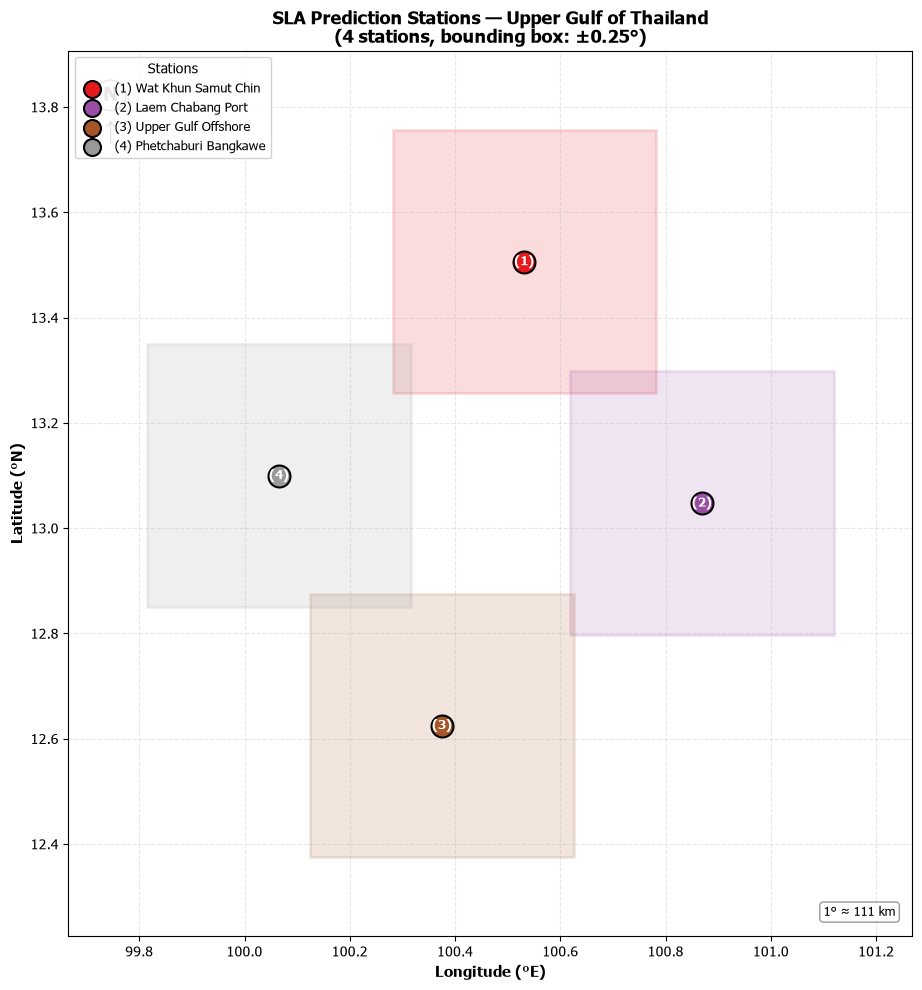

(<Figure size 1200x1000 with 1 Axes>,
 <Axes: title={'center': 'SLA Prediction Stations — Upper Gulf of Thailand\n(4 stations, bounding box: ±0.25°)'}, xlabel='Longitude (°E)', ylabel='Latitude (°N)'>)

In [8]:
def plot_static_map(gdf_points: gpd.GeoDataFrame,
                    gdf_bboxes: gpd.GeoDataFrame,
                    output_path: str = None,
                    figsize: tuple = (12, 10)):
    """
    วาดแผนที่ static แบบสวยงามสำหรับ report/thesis
    """
    fig, ax = plt.subplots(figsize=figsize)

    # สีสำหรับแต่ละสถานี
    colors = plt.cm.Set1(np.linspace(0, 1, len(gdf_points)))

    # วาด bounding boxes
    for (idx, bbox_row), color in zip(gdf_bboxes.iterrows(), colors):
        x, y = bbox_row["geometry"].exterior.xy
        ax.fill(x, y, alpha=0.15, color=color, edgecolor=color, linewidth=2)

    # วาด station points
    for (idx, row), color in zip(gdf_points.iterrows(), colors):
        ax.scatter(
            row["lon"], row["lat"],
            s=250, color=color,
            edgecolor="black", linewidth=1.5,
            zorder=5,
            label=row["station"],
        )

        # Label text
        ax.annotate(
            f"({idx+1})",
            xy=(row["lon"], row["lat"]),
            xytext=(0, 0),
            textcoords="offset points",
            ha="center", va="center",
            fontsize=9, fontweight="bold",
            color="white",
            zorder=6,
        )

    # ตั้งค่าแกน
    lon_min, lon_max = gdf_bboxes.total_bounds[0], gdf_bboxes.total_bounds[2]
    lat_min, lat_max = gdf_bboxes.total_bounds[1], gdf_bboxes.total_bounds[3]

    margin = 0.15
    ax.set_xlim(lon_min - margin, lon_max + margin)
    ax.set_ylim(lat_min - margin, lat_max + margin)

    ax.set_xlabel("Longitude (°E)", fontsize=11, fontweight="bold")
    ax.set_ylabel("Latitude (°N)",  fontsize=11, fontweight="bold")
    ax.set_title(
        f"SLA Prediction Stations — Upper Gulf of Thailand\n"
        f"({len(gdf_points)} stations, bounding box: ±{CONFIG['BUFFER']}°)",
        fontsize=13, fontweight="bold",
    )

    # Grid
    ax.grid(True, alpha=0.3, linestyle="--")

    # Legend (สถานี + เลขลำดับ)
    legend_labels = [f"({i+1}) {name}" for i, name in enumerate(gdf_points["station"])]
    legend_handles = [
        plt.scatter([], [], s=150, color=colors[i], edgecolor="black", linewidth=1.5)
        for i in range(len(gdf_points))
    ]
    ax.legend(
        legend_handles, legend_labels,
        loc="upper left",
        fontsize=9,
        framealpha=0.9,
        title="Stations",
        title_fontsize=10,
    )

    # North arrow
    ax.annotate(
        "N", xy=(0.05, 0.95), xycoords="axes fraction",
        ha="center", va="center",
        fontsize=14, fontweight="bold",
        bbox=dict(boxstyle="circle,pad=0.3", fc="white", ec="black"),
    )
    ax.annotate(
        "↑", xy=(0.05, 0.91), xycoords="axes fraction",
        ha="center", va="center",
        fontsize=20,
    )

    # Scale bar indicator (text)
    scale_km = 111  # 1° ≈ 111 km at equator
    ax.text(
        0.98, 0.02,
        f"1° ≈ {scale_km} km",
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
    )

    ax.set_aspect("equal")
    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, dpi=200, bbox_inches="tight")
        print(f"✅ Static map saved: {output_path}")

    plt.show()
    return fig, ax


# สร้างและแสดงแผนที่
static_map_path = os.path.join(CONFIG["output_dir"], "stations_static_map.png")
plot_static_map(gdf_points, gdf_bboxes, static_map_path)

# Load SLA (Sea Level Anomaly) from CMEMS/AVISO

SLA overview saved: D:\defence_sla_WSL_backup\outputs_fair_comparison\sla_overview_1993_2024.png


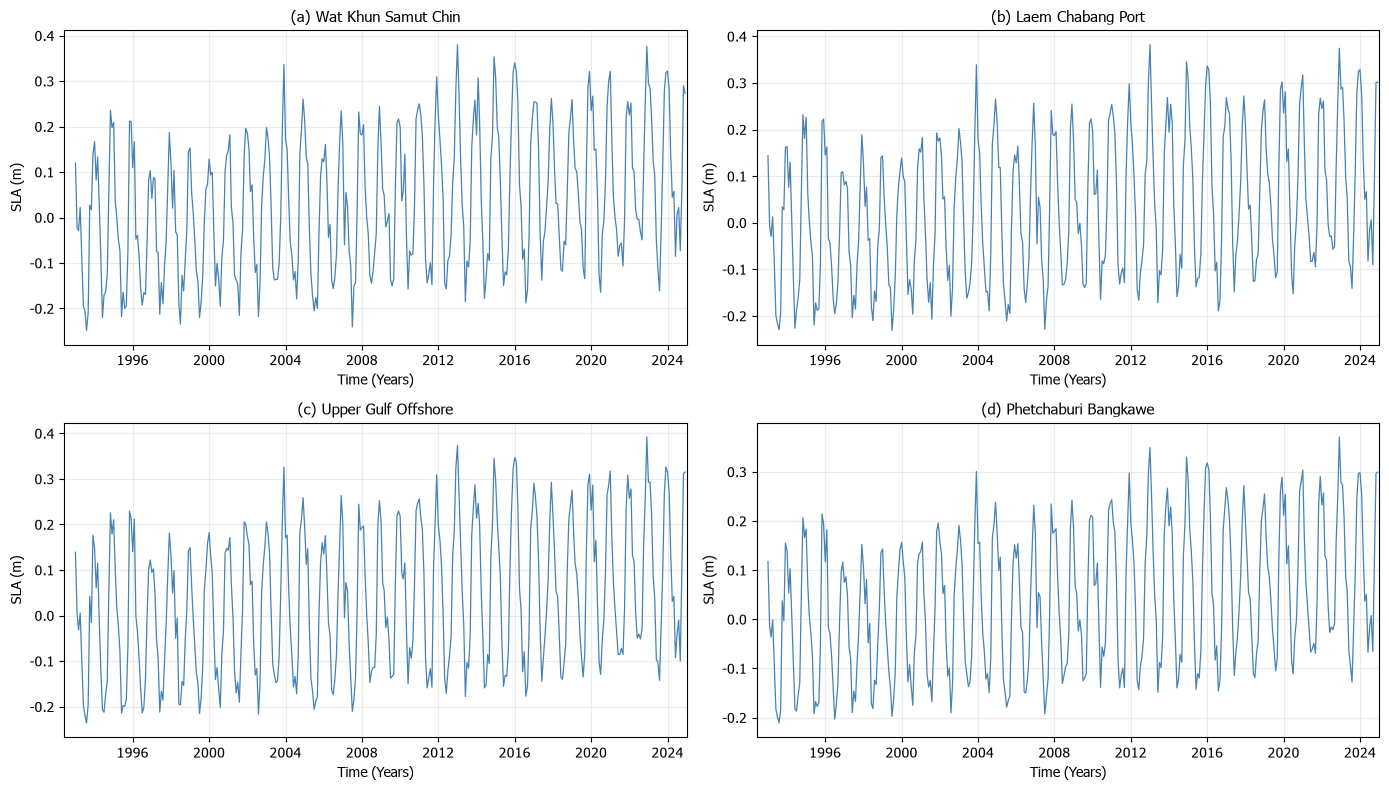

In [9]:
# Plot Raw SLA Time Series — 4 Stations (1993-2024)
import string
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# load_sla ใช้นิยามเดียวจาก Section 3 (เซลล์ DATA LOADING) — ลบสำเนาซ้ำออกแล้ว
def plot_sla_overview(stations_dict: dict,
                      output_path: str = None,
                      figsize: tuple = (14, 8)):
    """
    Plot raw SLA time series ของทุกสถานี ในรูปแบบ 2x2 grid
    """
    n = len(stations_dict)
    cols = 2
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).flatten() if n > 1 else [axes]

    labels = list(string.ascii_lowercase)  # a, b, c, d, ...

    for ax, (label, (station_name, info)) in zip(axes,
                                                  zip(labels, stations_dict.items())):
        # โหลด SLA แบบ raw
        # หมายเหตุ: ฟังก์ชัน load_sla ที่ถูกเรียกใช้ต้องรองรับการรับ arguments ตามที่ส่งไป
        # Corrected the call to load_sla to pass only the 'info' dictionary
        sla_series = load_sla(info)

        ax.plot(sla_series.index, sla_series.values,
                color="steelblue", linewidth=0.9)

        ax.set_title(f"({label}) {station_name}",
                     fontsize=11, fontweight="normal")
        ax.set_xlabel("Time (Years)")
        ax.set_ylabel("SLA (m)")
        ax.grid(True, alpha=0.25)

        # จัดแกน x ให้แสดงปีเป็นช่วงๆ
        ax.set_xlim(pd.Timestamp("1992-06-01"), pd.Timestamp("2024-12-31"))

    # ซ่อน subplot ที่ไม่ใช้
    for ax in axes[n:]:
        ax.set_visible(False)

    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, dpi=200, bbox_inches="tight")
        print(f"SLA overview saved: {output_path}")

    plt.show()

# เรียกใช้
sla_overview_path = os.path.join(CONFIG["output_dir"], "sla_overview_1993_2024.png")
plot_sla_overview(CONFIG["stations"], sla_overview_path)

ตารางที่ 4.x  ค่าเฉลี่ยรายเดือนตามปฏิทินของค่าความผิดปกติของระดับน้ำทะเล (เมตร)
              คำนวณจากข้อมูล 32 ปี (ค.ศ. 1993–2024)



Station_TH,ชายฝั่งทะเลตำบลบางแก้ว,ท่าเรือแหลมฉบัง,พื้นที่ตอนล่างของอ่าวไทยตอนบน,วัดขุนสมุทรจีน
Month_TH,,,,
ม.ค.,0.1985,0.2123,0.2163,0.2062
ก.พ.,0.1500,0.1558,0.1673,0.1554
มี.ค.,0.0940,0.0979,0.1043,0.0993
เม.ย.,0.0276,0.0259,0.0281,0.0285
พ.ค.,-0.0420,-0.0549,-0.0550,-0.0478
มิ.ย.,-0.1201,-0.1377,-0.1420,-0.1303
ก.ค.,-0.1198,-0.1337,-0.1405,-0.1281
ส.ค.,-0.1177,-0.1320,-0.1384,-0.1306
ก.ย.,-0.0850,-0.0977,-0.0994,-0.1031



สรุปรายสถานี


,สถานี,เดือนสูงสุด,ค่าสูงสุด (m),เดือนต่ำสุด,ค่าต่ำสุด (m),ช่วงแกว่ง (m),ช่วงแกว่งหลังขจัดแนวโน้ม (m)
0,วัดขุนสมุทรจีน,ธ.ค.,0.2320,ส.ค.,-0.1306,0.3625,0.3609
1,ท่าเรือแหลมฉบัง,ธ.ค.,0.2365,มิ.ย.,-0.1377,0.3743,0.3719
2,พื้นที่ตอนล่างของอ่าวไทยตอนบน,ธ.ค.,0.2462,มิ.ย.,-0.1420,0.3882,0.3859
3,ชายฝั่งทะเลตำบลบางแก้ว,ธ.ค.,0.2301,มิ.ย.,-0.1201,0.3503,0.3480


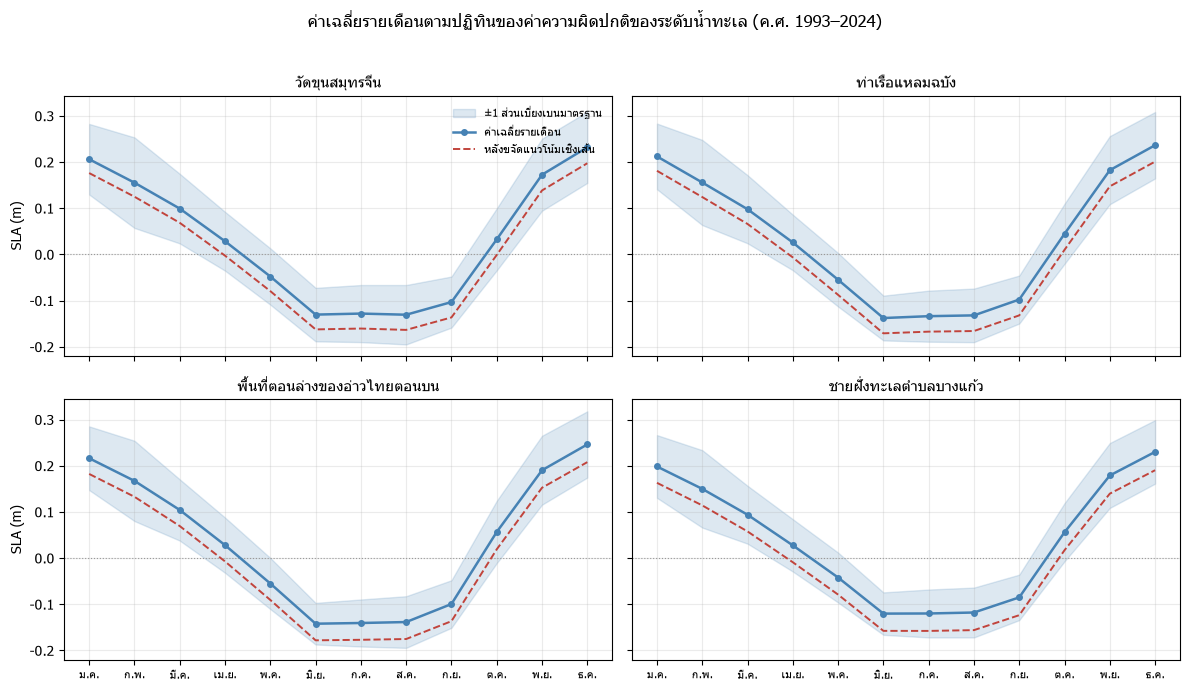


บันทึกแล้ว:
  D:\defence_sla_WSL_backup\outputs_fair_comparison\monthly_climatology_4stations.png
  D:\defence_sla_WSL_backup\outputs_fair_comparison\monthly_climatology_long.csv
  D:\defence_sla_WSL_backup\outputs_fair_comparison\monthly_climatology_wide.csv
  D:\defence_sla_WSL_backup\outputs_fair_comparison\monthly_climatology_summary.csv
ตรวจสอบผ่าน: 12 เดือน x 4 สถานี, ทุกเดือนมีข้อมูลครบ 32 ปี


In [10]:
#  ค่าเฉลี่ยรายเดือนตามปฏิทิน (Monthly Climatology) — สำหรับหัวข้อ 4.1.2.1
#
#  วางเซลล์นี้ "ต่อจากเซลล์ Plot Raw SLA Time Series — 4 Stations"
#  (เซลล์ที่ 20 ในโน้ตบุ๊ก) และก่อนเซลล์ตารางตัวอย่างข้อมูล (เซลล์ที่ 22)
#
#  ต้องรันมาก่อน: เซลล์ตั้งค่าโฟลเดอร์ (BASE_DIR), CONFIG, DATA LOADING
#
#  ใช้ build_sarima_series() ไม่ใช่ build_dataset() เพราะ
#    - build_sarima_series() : index = "เดือนจริงของ SLA" ครบ 384 เดือน (ม.ค. 1993 – ธ.ค. 2024)
#    - build_dataset()       : index = target_time (เดือนของค่าที่พยากรณ์ = t+1)
#                              และถูก dropna(SLA_lag12) ตัด 12 เดือนแรกทิ้ง เหลือ 371 แถว
#      ถ้าใช้ build_dataset() ค่าเฉลี่ยของเดือนจะเลื่อนไป 1 เดือน และปี 1993 หายไปทั้งปี


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MONTH_TH = ["ม.ค.", "ก.พ.", "มี.ค.", "เม.ย.", "พ.ค.", "มิ.ย.",
            "ก.ค.", "ส.ค.", "ก.ย.", "ต.ค.", "พ.ย.", "ธ.ค."]

STATION_TH = {
    "Wat Khun Samut Chin":  "วัดขุนสมุทรจีน",
    "Laem Chabang Port":    "ท่าเรือแหลมฉบัง",
    "Upper Gulf Offshore":  "พื้นที่ตอนล่างของอ่าวไทยตอนบน",
    "Phetchaburi Bangkawe": "ชายฝั่งทะเลตำบลบางแก้ว",
}


def detrend_linear(series: pd.Series) -> pd.Series:
    """ขจัดแนวโน้มเชิงเส้นออกจากอนุกรม (ใช้เปรียบเทียบว่าฤดูกาลล้วน ๆ มีขนาดเท่าไร)"""
    t = np.arange(len(series), dtype=float)
    coef = np.polyfit(t, series.to_numpy(dtype=float), deg=1)
    return pd.Series(series.to_numpy(dtype=float) - np.polyval(coef, t),
                     index=series.index, name=series.name)


rows, clim_raw, clim_det = [], {}, {}

for station in CONFIG["stations"]:
    sla = build_sarima_series(station)          # 384 เดือน, index = เดือนจริง

    # ---- หัวใจของการคำนวณ: จัดกลุ่มตามเลขเดือนปฏิทิน 1–12 แล้วเฉลี่ยข้ามปี ----
    stats = sla.groupby(sla.index.month).agg(["mean", "std", "min", "max", "count"])
    stats.index.name = "month"

    sla_det = detrend_linear(sla)
    stats_det = sla_det.groupby(sla_det.index.month).mean()

    clim_raw[station] = stats["mean"]
    clim_det[station] = stats_det

    for m, r in stats.iterrows():
        rows.append({
            "Station":       station,
            "Station_TH":    STATION_TH.get(station, station),
            "Month":         int(m),
            "Month_TH":      MONTH_TH[int(m) - 1],
            "Mean_m":        r["mean"],
            "SD_m":          r["std"],
            "Min_m":         r["min"],
            "Max_m":         r["max"],
            "N_years":       int(r["count"]),
            "Mean_detrended_m": stats_det.loc[m],
        })

climatology_long = pd.DataFrame(rows)

# ---- ตารางสำหรับวางในเล่ม: แถว = เดือน, คอลัมน์ = สถานี ----
climatology_wide = (climatology_long
                    .pivot(index="Month_TH", columns="Station_TH", values="Mean_m")
                    .reindex(MONTH_TH)
                    .round(4))

print("ตารางที่ 4.x  ค่าเฉลี่ยรายเดือนตามปฏิทินของค่าความผิดปกติของระดับน้ำทะเล (เมตร)")
print("              คำนวณจากข้อมูล 32 ปี (ค.ศ. 1993–2024)\n")
try:
    display(climatology_wide)
except NameError:
    print(climatology_wide.to_string())

# ---- สรุปเดือนสูงสุด/ต่ำสุด และช่วงการแกว่งตามฤดูกาล (ใช้เขียนบรรยายในเล่ม) ----
print("\nสรุปรายสถานี")
summary_rows = []
for station, s in clim_raw.items():
    m_max, m_min = int(s.idxmax()), int(s.idxmin())
    d = clim_det[station]
    summary_rows.append({
        "สถานี":            STATION_TH.get(station, station),
        "เดือนสูงสุด":       MONTH_TH[m_max - 1],
        "ค่าสูงสุด (m)":     round(float(s.max()), 4),
        "เดือนต่ำสุด":       MONTH_TH[m_min - 1],
        "ค่าต่ำสุด (m)":     round(float(s.min()), 4),
        "ช่วงแกว่ง (m)":     round(float(s.max() - s.min()), 4),
        "ช่วงแกว่งหลังขจัดแนวโน้ม (m)": round(float(d.max() - d.min()), 4),
    })
climatology_summary = pd.DataFrame(summary_rows)
try:
    display(climatology_summary)
except NameError:
    print(climatology_summary.to_string(index=False))

# ---- กราฟ: เส้นค่าเฉลี่ยรายเดือน + แถบ ±1 SD ----
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)
axes = axes.ravel()
x = np.arange(1, 13)

for ax, station in zip(axes, CONFIG["stations"]):
    sub = climatology_long[climatology_long["Station"] == station].sort_values("Month")
    mean, sd = sub["Mean_m"].to_numpy(), sub["SD_m"].to_numpy()

    ax.axhline(0.0, color="#999999", lw=0.8, ls=":")
    ax.fill_between(x, mean - sd, mean + sd, color="steelblue", alpha=0.18,
                    label="±1 ส่วนเบี่ยงเบนมาตรฐาน")
    ax.plot(x, mean, color="steelblue", lw=1.8, marker="o", ms=4,
            label="ค่าเฉลี่ยรายเดือน")
    ax.plot(x, sub["Mean_detrended_m"].to_numpy(), color="#c1443c", lw=1.4,
            ls="--", label="หลังขจัดแนวโน้มเชิงเส้น")

    ax.set_title(STATION_TH.get(station, station), fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(MONTH_TH, fontsize=8)
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("SLA (m)")
axes[2].set_ylabel("SLA (m)")
axes[0].legend(fontsize=8, frameon=False, loc="upper right")
fig.suptitle("ค่าเฉลี่ยรายเดือนตามปฏิทินของค่าความผิดปกติของระดับน้ำทะเล (ค.ศ. 1993–2024)",
             fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])

fig_path = os.path.join(CONFIG["output_dir"], "monthly_climatology_4stations.png")
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

# ---- บันทึกไฟล์สำหรับนำไปทำตารางในเล่ม ----
long_path    = os.path.join(CONFIG["output_dir"], "monthly_climatology_long.csv")
wide_path    = os.path.join(CONFIG["output_dir"], "monthly_climatology_wide.csv")
summary_path = os.path.join(CONFIG["output_dir"], "monthly_climatology_summary.csv")

climatology_long.round(6).to_csv(long_path, index=False, encoding="utf-8-sig")
climatology_wide.to_csv(wide_path, encoding="utf-8-sig")
climatology_summary.to_csv(summary_path, index=False, encoding="utf-8-sig")

print(f"\nบันทึกแล้ว:\n  {fig_path}\n  {long_path}\n  {wide_path}\n  {summary_path}")

# ---- ตรวจความถูกต้อง: ต้องมี 12 เดือน x 4 สถานี และแต่ละเดือนมี 32 ปีครบ ----
assert len(climatology_long) == 12 * len(CONFIG["stations"]), "จำนวนแถวไม่ครบ 12 เดือน x จำนวนสถานี"
assert (climatology_long["N_years"] == 32).all(), "บางเดือนมีจำนวนปีไม่ครบ 32 ปี"
print("ตรวจสอบผ่าน: 12 เดือน x 4 สถานี, ทุกเดือนมีข้อมูลครบ 32 ปี")

openpyxl เป็นไลบรารีของ Python ที่ออกแบบมาสำหรับ อ่านและเขียนไฟล์ Excel (นามสกุล .xlsx)

In [12]:
import pandas as pd

RAW_COLS = ["SLA", "SST", "SLP", "u10", "v10"]   # ตัวแปรดิบที่แปลงหน่วยแล้ว
SRC_COLS = ["SLA_hist", "SST", "SLP", "u10", "v10"]  # คอลัมน์จริงใน build_dataset
N_PER_STATION = 2                                 # เอากี่แถวต่อสถานี (ปรับได้)

frames = []
for station in CONFIG["stations"]:
    df = build_dataset(station)[SRC_COLS].head(N_PER_STATION).copy()
    df = df.rename(columns={"SLA_hist": "SLA"})   # SLA เดือน t เก็บไว้ในชื่อ SLA_hist
    df.insert(0, "สถานี", station)                # ใส่ชื่อสถานีเป็นคอลัมน์แรก
    df.insert(1, "เดือน", df.index.strftime("%Y-%m"))  # เดือนอ่านง่าย
    frames.append(df)

sample_table = pd.concat(frames).reset_index(drop=True)

# ปัดทศนิยมให้อ่านง่ายในเล่ม (ปรับจำนวนตำแหน่งได้)
sample_table[RAW_COLS] = sample_table[RAW_COLS].round(
    {"SLA": 3, "SST": 2, "SLP": 2, "u10": 2, "v10": 2}
)

display(sample_table)

# ส่งออกไฟล์ (utf-8-sig ให้ Excel อ่านภาษาไทยไม่เพี้ยน)
sample_table.to_csv(os.path.join(CONFIG["output_dir"], "sample_data_table.csv"), index=False, encoding="utf-8-sig")
sample_table.to_excel(os.path.join(CONFIG["output_dir"], "sample_data_table.xlsx"), index=False)
print("บันทึกแล้ว: sample_data_table.csv, sample_data_table.xlsx")

,สถานี,เดือน,SLA,SST,SLP,u10,v10
0,Wat Khun Samut Chin,1994-02,0.167,26.570000,1011.630005,-0.47,0.80
1,Wat Khun Samut Chin,1994-03,0.082,28.120001,1009.719971,0.09,3.35
2,Laem Chabang Port,1994-02,0.163,26.680000,1011.700012,0.01,0.69
3,Laem Chabang Port,1994-03,0.076,28.090000,1010.010010,0.28,3.48
4,Upper Gulf Offshore,1994-02,0.148,26.709999,1011.719971,0.18,1.10
5,Upper Gulf Offshore,1994-03,0.061,27.990000,1009.989990,-0.06,4.62
6,Phetchaburi Bangkawe,1994-02,0.140,26.480000,1011.690002,-0.44,1.13
7,Phetchaburi Bangkawe,1994-03,0.053,28.030001,1009.780029,-0.85,4.02


บันทึกแล้ว: sample_data_table.csv, sample_data_table.xlsx


- การทำงานของโค้ดแบ่งเป็น 4 ขั้นตอนหลัก:
- กำหนดตัวแปรที่ต้องการวิเคราะห์: กำหนดรายการ analysis_cols เพื่อเลือกเฉพาะคอลัมน์ข้อมูลที่สนใจ

- ดึงข้อมูลและคำนวณสถิติ (ในลูป for): วนลูปไปตามแต่ละสถานีที่มีในตัวแปร CONFIG

- ดึงข้อมูลด้วยฟังก์ชัน build_dataset() และเปลี่ยนชื่อคอลัมน์ SLA_hist เป็น SLA

- ใช้คำสั่ง .describe().T เพื่อคำนวณสถิติ (Count, Mean, Std, Min, Max, และ Percentile) ของตัวแปรทั้งหมด แล้วสลับแกนตาราง (Transpose) ให้ตัวแปรมาอยู่เป็นแถว

- เพิ่มคอลัมน์ชื่อสถานี (station) และชื่อตัวแปร (variable) เข้าไปในผลลัพธ์

รวมข้อมูลและจัดรูปแบบ: นำตารางสถิติของทุกสถานีมาต่อกันเป็นตารางเดียว (df_summary)

- จัดเรียงลำดับคอลัมน์ใหม่ให้อ่านง่ายขึ้น และแสดงผลลัพธ์ทางหน้าจอโดยปัดเศษทศนิยม 4 ตำแหน่ง (display(df_summary.round(4)))

- บันทึกผลลัพธ์:นำตารางสรุปสุดท้ายไปบันทึกเป็นไฟล์ Excel/CSV (full_variables_statistics.csv) ลงในโฟลเดอร์ที่กำหนดไว้ใน CONFIG

In [14]:
import pandas as pd

# Define variables for analysis
analysis_cols = ["SLA", "SST", "SLP", "u10", "v10"]  # SLA เดือน t (build_dataset เก็บชื่อ SLA_hist จึง rename ด้านล่าง)

# Initialize container for all results
all_stats = []

for station_name in CONFIG["stations"].keys():
    # Load full dataset for the station using the helper function
    df_full = build_dataset(station_name).rename(columns={"SLA_hist": "SLA"})

    # Calculate statistics for the requested columns
    stats = df_full[analysis_cols].describe().T
    stats["station"] = station_name
    stats = stats.reset_index().rename(columns={"index": "variable"})

    all_stats.append(stats)

# Combine into a single master table
df_summary = pd.concat(all_stats, ignore_index=True)

# Reorder columns for better readability
final_cols = ["station", "variable", "count", "mean", "std", "min", "25%", "50%", "75%", "max"]
df_summary = df_summary[final_cols]

print("Statistical Analysis Summary per Station and Variable")
display(df_summary.round(4))

# Save to CSV in the output directory
output_csv = os.path.join(CONFIG["output_dir"], "full_variables_statistics.csv")
df_summary.to_csv(output_csv, index=False)
print(f"\nFull analysis saved to: {output_csv}")

Statistical Analysis Summary per Station and Variable


,station,variable,count,mean,std,min,25%,50%,75%,max
0,Wat Khun Samut Chin,SLA,371.0,0.0344,0.1500,-0.2405,-0.0933,0.0241,0.1580,0.3802
1,Wat Khun Samut Chin,SST,371.0,29.2445,1.2657,25.5539,28.6319,29.4906,30.1830,31.4972
2,Wat Khun Samut Chin,SLP,371.0,1009.3566,2.1772,1005.6881,1007.3806,1009.1990,1011.1945,1014.2656
3,Wat Khun Samut Chin,u10,371.0,0.3602,1.1306,-1.8357,-0.4919,0.0880,1.3311,2.8807
4,Wat Khun Samut Chin,v10,371.0,1.0936,1.6296,-2.9466,-0.1917,1.6159,2.2636,4.1038
5,Laem Chabang Port,SLA,371.0,0.0352,0.1511,-0.2311,-0.0920,0.0290,0.1632,0.3822
6,Laem Chabang Port,SST,371.0,29.2109,1.1669,25.8732,28.6241,29.4345,30.0546,31.4435
7,Laem Chabang Port,SLP,371.0,1009.5214,2.0370,1005.9728,1007.7299,1009.3318,1011.2250,1014.1418
8,Laem Chabang Port,u10,371.0,0.5026,1.4104,-2.4585,-0.5008,0.2382,1.7511,3.5138
9,Laem Chabang Port,v10,371.0,1.1906,1.9153,-3.8152,-0.2677,1.9576,2.6289,4.4611



Full analysis saved to: D:\defence_sla_WSL_backup\outputs_fair_comparison\full_variables_statistics.csv


**ดึงข้อมูลชุดเตรียมฝึกสอน (Feature datasets) ของแต่ละสถานี แล้วบันทึกแยกเป็นไฟล์ CSV ทีละสถานี ลงในโฟลเดอร์ที่กำหนดไว้**

In [15]:
import os

# (รันบนเครื่อง — ไม่ต้อง mount Google Drive)
export_path = str(EXPORT_DIR)          # จาก BASE_DIR (เซลล์ตั้งค่าโฟลเดอร์โปรเจกต์)
if not os.path.exists(export_path):
    os.makedirs(export_path)
    print(f"Created folder: {export_path}")

stations_to_export = CONFIG["stations"].keys()

for station_name in stations_to_export:
    try:
        df_result = build_dataset(station_name)
        file_name = f"{station_name}_features.csv"
        full_save_path = os.path.join(export_path, file_name)
        df_result.to_csv(full_save_path, index=True)
        print(f"Export success: {full_save_path}")
    except Exception as e:
        print(f"Error at station {station_name}: {e}")

print("\nAll feature datasets exported")

Export success: D:\defence_sla_WSL_backup\train_model_final\Wat Khun Samut Chin_features.csv
Export success: D:\defence_sla_WSL_backup\train_model_final\Laem Chabang Port_features.csv
Export success: D:\defence_sla_WSL_backup\train_model_final\Upper Gulf Offshore_features.csv
Export success: D:\defence_sla_WSL_backup\train_model_final\Phetchaburi Bangkawe_features.csv

All feature datasets exported


**Sliding Lookback Window (หน้าต่างย้อนหลังแบบเลื่อน) ขนาด 12 เดือน คือเทคนิคการเตรียมข้อมูลอนุกรมเวลา (Time Series) เพื่อใช้สอนโมเดล Deep Learning อย่าง LSTM (Long Short-Term Memory)**


In [ ]:
#  5. SEQUENCES sliding window ย้อนหลัง lookback เดือน
def create_sequences(X, y, lookback):
    Xs, ys = [], []

    for target_pos in range(lookback - 1, len(X)):
        start_pos = target_pos - lookback + 1

        # รวม feature ของแถว target_pos ด้วย (จบ window ที่เดือน t ของ target)
        Xs.append(X[start_pos:target_pos + 1, :])
        ys.append(y[target_pos, 0])

    return np.asarray(Xs), np.asarray(ys)


**13.0 SHARED SETUP  helper กลาง (metrics / ADF / differencing / SARIMA grid search)**

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, acf as sm_acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera as sm_jarque_bera

from sklearn.preprocessing import MinMaxScaler          # ใช้โดย LSTM (scale X และ y)
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# ที่เก็บผล + โฟลเดอร์ปลายทางสำหรับบันทึกเป็น CSV
# ผลชุดนี้มาจาก run ใหม่หลังแยก preprocessing ของ SARIMA / RF / LSTM ออกจากกัน
# จึงเขียนลงโฟลเดอร์ใหม่ ไม่ทับผลชุดเดิมใน _backup_before_lstm_lag/

import os

SARIMA_OUTPUT_DIR = os.path.join(CONFIG["output_dir"], "separated_preprocessing")
os.makedirs(SARIMA_OUTPUT_DIR, exist_ok=True)

data_split_records = []              # 01 — Train/Val/Test split ของทั้ง 3 โมเดล
sarima_stationarity_records = []     # 02 — Fs / D / ADF / d จาก choose_d_and_D
sarima_gridsearch_records = []       # 03 — candidate ทั้งหมด (ก่อน .head(top_k))
sarima_top5_validation_records = []  # 04 — Val RMSE ของ Top-K
sarima_selected_records = []         # 05 — order ที่ workflow เลือก
sarima_coefficient_records = []      # 06 — อ่านจาก fitted result object ของโมเดลสุดท้าย
sarima_residual_records = []         # 07 — residual diagnostics ของ final model
lstm_training_records = []           # lstm_training_summary.csv
rf_grid_records = []                 # RF — ทุก combination ของ grid search (ทุกสถานี)

_LAST_ADF = {}           # ค่า ADF ครั้งล่าสุดที่ adf_report เพิ่งคำนวณ (ไม่เรียก adfuller ซ้ำ)
_LAST_SEASONAL = {}      # ค่า Fs/D ครั้งล่าสุดที่ choose_seasonal_D เพิ่งคำนวณ (ไม่เรียก STL ซ้ำ)
_LAST_STATIONARITY = {}  # รวม Fs/D/ADF/d ของการเลือกครั้งล่าสุด
_LAST_SARIMA_FIT = {}    # coefficient + residual ที่อ่านจาก SARIMAX result object


def rmse(y_true, y_pred) -> float:
    """RMSE — ตัววัดหลักของทุกโมเดล (ต้องคำนวณบนสเกลจริงเท่านั้น!)"""
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def evaluate_forecast(y_true, y_pred) -> dict:
    """ตัวชี้วัดของงานวิจัยนี้ (คำนวณบนสเกลจริงเท่านั้น!)
    - MSE  : Mean Squared Error  — ค่าเฉลี่ยของ error กำลังสอง ลงโทษ error ใหญ่แรง (หน่วย m²)
    - MAE  : Mean Absolute Error — ค่าเฉลี่ย |error| ตีความง่าย ทนต่อ outlier (หน่วย m)
    - RMSE : รากที่สองของ MSE — หน่วยเดียวกับข้อมูล (m) ใช้เป็นตัวชี้วัดหลักในการเปรียบเทียบ
    - R²   : สัดส่วนความแปรปรวนที่โมเดลอธิบายได้ (1 = สมบูรณ์แบบ, 0 = เท่าการทายด้วยค่าเฉลี่ย, ติดลบ = แย่กว่าค่าเฉลี่ย)"""
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    return {
        "MSE":  float(mean_squared_error(y_true, y_pred)),
        "MAE":  float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2":   float(r2_score(y_true, y_pred)),
    }


def print_metrics(metrics: dict, label: str = "") -> None:
    """พิมพ์ตัวชี้วัดครบชุดในบรรทัดเดียว"""
    print(f"   {label:6s} MSE = {metrics['MSE']:.6f} m² | MAE = {metrics['MAE']:.4f} m | "
          f"RMSE = {metrics['RMSE']:.4f} m | R² = {metrics['R2']:.4f}")



def difference(series: pd.Series, d: int) -> pd.Series:
    """Differencing d ครั้ง: Y_t - Y_(t-1) ทำซ้ำ d รอบ
    (ระวัง: series.diff(d) ของ pandas คือ lag-d diff ไม่ใช่ diff ซ้ำ d ครั้ง)"""
    out = series.copy()
    for _ in range(d):
        out = out.diff().dropna()
    return out


def adf_report(series: pd.Series, label: str = "") -> float:
    """Augmented Dickey-Fuller test — คืนค่า p-value
    H0: มี unit root (non-stationary) → ถ้า p < 0.05 แปลว่า stationary"""
    stat, pvalue = adfuller(series.dropna(), autolag="AIC")[:2]
    verdict = "STATIONARY" if pvalue < 0.05 else "non-stationary"
    print(f"   ADF [{label:>4s}]  statistic = {stat:8.4f}   p-value = {pvalue:.4f}  ->  {verdict}")
    # เก็บค่าที่ "เพิ่งคำนวณข้างบน" ไว้ให้ export — ไม่ได้เรียก adfuller ซ้ำ
    _LAST_ADF.clear()
    _LAST_ADF.update({
        "ADF_Statistic": float(stat),
        "ADF_PValue": float(pvalue),
        "ADF_Alpha": 0.05,
        "Stationary": verdict == "STATIONARY",
    })
    return pvalue


#ตัวเลือก D (seasonal differencing) จากความแรงฤดูกาล
def seasonal_strength(series: pd.Series, period: int = 12) -> float:
    """ความแรงฤดูกาล Fs = max(0, 1 - Var(remainder) / Var(remainder + seasonal))
    ประเมิน seasonal + remainder ด้วย STL decomposition
    อ้างอิง: Wang, Smith & Hyndman (2006); Hyndman & Athanasopoulos, FPP3 (§3.3)
    Fs -> 1 = ฤดูกาลแรงมาก | Fs -> 0 = แทบไม่มีฤดูกาล"""
    y = pd.Series(np.asarray(series, dtype=float)).reset_index(drop=True)
    if len(y) < 2 * period:
        return 0.0
    res = STL(y, period=period, robust=True).fit()
    var_r  = float(np.var(res.resid))
    var_rs = float(np.var(res.resid + res.seasonal))
    if var_rs <= 0:
        return 0.0
    return float(max(0.0, 1.0 - var_r / var_rs))


def choose_seasonal_D(series: pd.Series, period: int = 12,
                      threshold: float = 0.64, max_D: int = 1):
    """เลือก D (seasonal differencing) แบบ data-driven จากความแรงฤดูกาล
    เกณฑ์ 0.64 = ค่าเริ่มต้นของ nsdiffs('seas') ใน R::forecast (Hyndman)
    Fs >= 0.64 -> ฤดูกาลแรงพอที่จะ seasonal-difference (D = 1) มิฉะนั้น D = 0
    คืนค่า: (D, Fs)"""
    fs = seasonal_strength(series, period)
    D = min(1 if fs >= threshold else 0, max_D)
    print(f"   Seasonal strength Fs = {fs:.3f} (period={period})  ->  D = {D}")
    # เก็บค่าที่ "เพิ่งคำนวณข้างบน" — ไม่ได้เรียก STL ซ้ำ
    _LAST_SEASONAL.clear()
    _LAST_SEASONAL.update({
        "Seasonal_Period": int(period),
        "Seasonal_Strength_Fs": float(fs),
        "Seasonal_Strength_Threshold": float(threshold),
        "D": int(D),
    })
    return D, fs


def choose_d_and_D(train_series: pd.Series, period: int = 12, max_d: int = 2):
    """เลือกลำดับ differencing ให้ถูกลำดับ: เลือก D (ฤดูกาล) ก่อน แล้วค่อยทดสอบ ADF
    หลัง seasonal differencing เพื่อหา d — กัน over-differencing (ความไม่นิ่งอาจมาจาก
    ฤดูกาล 12 เดือนล้วน ๆ เมื่อ seasonal-diff แล้วอาจ stationary โดยไม่ต้องใช้ d=1)
    คืนค่า: (d, D, Fs)"""
    y = train_series.dropna().astype(float).copy()

    print("   Log transform: ข้าม (SLA เป็น anomaly และอาจมีค่าติดลบ)")

    # ขั้นที่ 1 — เลือก Seasonal differencing จากความแรงฤดูกาล
    D, fs = choose_seasonal_D(y, period=period)

    if D == 1:
        adf_base = y.diff(period).dropna()   # seasonal differencing lag-period
    else:
        adf_base = y.copy()

    # ขั้นที่ 2 — หา d หลังจัดการฤดูกาลแล้ว (ADF บนอนุกรมที่ seasonal-diff แล้ว)
    d = 0
    pvalue = adf_report(adf_base, f"D={D}, d=0")

    while pvalue >= 0.05 and d < max_d:
        d += 1
        tested = difference(adf_base, d)
        pvalue = adf_report(tested, f"D={D}, d={d}")

    print(f"   => เลือก d = {d}, D = {D}")

    # รวมค่าที่เพิ่งคำนวณข้างบน (Fs/D จาก choose_seasonal_D + ADF ครั้งสุดท้าย ณ d ที่เลือก)
    _LAST_STATIONARITY.clear()
    _LAST_STATIONARITY.update({**_LAST_SEASONAL, **_LAST_ADF, "d": int(d),
                               "Train_N": int(len(y)),
                               "Train_Start": str(train_series.index.min())[:7],
                               "Train_End": str(train_series.index.max())[:7]})

    return d, D, fs


#  SARIMA Grid Search: เลือก (p,q)(P,Q) จากค่า AIC/BIC (d,D คงที่จาก ADF + Fs)
def sarima_grid_search(train_series: pd.Series, d: int, D: int, s: int = 12,
                       p_range=range(0, 3), q_range=range(0, 3),
                       P_range=range(0, 2), Q_range=range(0, 2),
                       criterion: str = "AIC") -> pd.DataFrame:
    """ลองทุกชุด (p,q,P,Q) ที่ d,D คงที่ แล้วเรียงตาม AIC (รายงาน BIC ด้วย)
    ข้ามชุด (0,0,0,0) ที่ไม่มีพจน์ AR/MA เลย (= white noise ล้วน)
    enforce_stationarity/invertibility = False → ยอมให้ optimizer ลู่เข้าได้กว้างขึ้น
    (เราคัดชุดสุดท้ายด้วย out-of-sample RMSE บน Val อยู่แล้ว)"""
    y = np.asarray(train_series, dtype=float)
    rows = []
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for p in p_range:
            for q in q_range:
                for P in P_range:
                    for Q in Q_range:
                        if p == 0 and q == 0 and P == 0 and Q == 0:
                            continue
                        try:
                            fit = SARIMAX(y, order=(p, d, q),
                                          seasonal_order=(P, D, Q, s),
                                          enforce_stationarity=False,
                                          enforce_invertibility=False).fit(disp=False)

                            converged = fit.mle_retvals.get("converged", False)

                            if not converged:
                                continue     # ข้ามชุดที่ optimizer ไม่ converge

                            rows.append({"p": p, "d": d, "q": q,
                                         "P": P, "D": D, "Q": Q, "s": s,
                                         "AIC": fit.aic, "BIC": fit.bic})
                        except Exception:
                            continue        # บางชุด fit ไม่สำเร็จ — ข้ามไป

    if not rows:
        raise RuntimeError(
            "ไม่พบ SARIMA candidate ที่ fit สำเร็จและ converge"
        )

    return pd.DataFrame(rows).sort_values(criterion).reset_index(drop=True)



#  SARIMA residual diagnostics — วินิจฉัย final fitted model เท่านั้น
#  (ไม่ใช้เลือกโมเดล และไม่แตะข้อมูล Test)

def sarima_residual_diagnostics(resid, station: str, order, seasonal_order,
                                fitted_on: str, lb_lags=(12, 24),
                                max_acf_lag: int = 12) -> dict:
    """สรุป residual ของโมเดลสุดท้าย: mean / SD / Ljung-Box / Jarque-Bera / skew / kurtosis / ACF

    ตัด residual ช่วง burn-in (d + D*s ตัวแรก) ออกก่อน เพราะ state space filter
    ยังไม่เข้าที่ (ค่าช่วงนั้นใหญ่ผิดปกติจาก diffuse initialization)
    Ljung-Box ใช้ model_df = p+q+P+Q เพื่อหักองศาอิสระของพารามิเตอร์ที่ estimate ไปแล้ว
    H0 ของ Ljung-Box: residual ไม่มี autocorrelation → p >= 0.05 = ผ่าน (residual คล้าย white noise)
    """
    d, s = int(order[1]), int(seasonal_order[3])
    D = int(seasonal_order[1])
    burn_in = d + D * s

    resid = np.asarray(resid, dtype=float).ravel()[burn_in:]
    resid = resid[np.isfinite(resid)]
    n = int(len(resid))
    model_df = int(order[0] + order[2] + seasonal_order[0] + seasonal_order[2])

    record = {
        "Station": station,
        "Order": str(tuple(order)),
        "Seasonal_Order": str(tuple(seasonal_order)),
        "Fitted_On": fitted_on,
        "N_Residuals": n,
        "Burn_In_Dropped": int(burn_in),
        "Model_DF": model_df,
        "Residual_Mean": float(np.mean(resid)),
        "Residual_SD": float(np.std(resid, ddof=1)),
    }

    jb_stat, jb_p, skew_v, kurt_v = sm_jarque_bera(resid)
    record.update({
        "Skewness": float(skew_v),
        "Kurtosis": float(kurt_v),              # raw kurtosis (3.0 = normal)
        "Excess_Kurtosis": float(kurt_v) - 3.0,
        "JarqueBera_Stat": float(jb_stat),
        "JarqueBera_PValue": float(jb_p),
    })

    for lag in lb_lags:
        key = f"LjungBox_lag{lag}"
        # lag ต้องมากกว่าจำนวนพารามิเตอร์ และไม่เกินความยาวอนุกรม จึงจะมี df เหลือให้ทดสอบ
        if lag >= n or lag <= model_df:
            record[f"{key}_Stat"] = np.nan
            record[f"{key}_PValue"] = np.nan
            record[f"{key}_DF"] = np.nan
        else:
            lb = acorr_ljungbox(resid, lags=[lag], model_df=model_df, return_df=True)
            record[f"{key}_Stat"] = float(lb["lb_stat"].iloc[0])
            record[f"{key}_PValue"] = float(lb["lb_pvalue"].iloc[0])
            record[f"{key}_DF"] = int(lag - model_df)

    acf_vals = sm_acf(resid, nlags=max_acf_lag, fft=False)
    for lag in range(1, max_acf_lag + 1):
        record[f"ACF_lag{lag}"] = float(acf_vals[lag])

    return record


print("13.0 SHARED SETUP เรียบร้อย | output:", SARIMA_OUTPUT_DIR)

13.0 SHARED SETUP เรียบร้อย | output: D:\defence_sla_WSL_backup\outputs_fair_comparison\separated_preprocessing


***วนตั้งค่าและเตรียมฟังก์ชันสำหรับรันการทดลองรอบสุดท้าย (Final Experiment Setup) ในโปรเจกต์ทำนายข้อมูลอนุกรมเวลา (Time Series) โดยมีเป้าหมายหลักเพื่อเปรียบเทียบประสิทธิภาพของ 3 โมเดล ได้แก่ SARIMA, Random Forest (RF) และ LSTM***

In [20]:
#  13.1 FINAL EXPERIMENT — SETUP (split 3 ชุด + ตัวเลือก SARIMA)

# ต้องรันมาก่อน: เซลล์ CONFIGURATION, DATA LOADING (build_dataset / build_sarima_series /
#build_lstm_dataset), 13.0 SHARED SETUP

TRAIN_END_YEAR = pd.Timestamp(CONFIG["train_end"]).year   # อ้างอิง CONFIG โดยตรง กัน drift
VAL_END_YEAR   = pd.Timestamp(CONFIG["val_end"]).year

# โมเดลที่เปรียบเทียบในงานวิจัยนี้ — ลำดับนี้ใช้เรียงตาราง/กราฟทุกที่ในเล่ม
MODELS = ["SARIMA", "RF", "LSTM"]


def split_3way(obj):
    """แบ่งตามเดือนของค่าที่ต้องการพยากรณ์ (อ้างอิง CONFIG โดยตรง กันช่วงวันสองเวอร์ชัน)
    index ของ obj คือเดือนของ Target แล้ว → .loc ตามช่วงใน CONFIG ได้ตรงความหมาย
    (SARIMA: index = เดือนจริงของ SLA ซึ่งก็คือเดือนที่ต้องพยากรณ์เช่นกัน)"""
    train = obj.loc[CONFIG["train_start"]:CONFIG["train_end"]]
    val   = obj.loc[CONFIG["val_start"]:CONFIG["val_end"]]
    test  = obj.loc[CONFIG["test_start"]:CONFIG["test_end"]]
    return train, val, test



#  ตรวจจำนวน/ช่วงของ split ต่อโมเดล
#  จำนวน Train ต่างกันได้ เพราะแต่ละโมเดลต้องการประวัติย้อนหลังไม่เท่ากัน
#  แต่ช่วง Validation/Test ต้องเป็นเดือนเดียวกันทุกโมเดล จึงเทียบผลกันได้

EXPECTED_VAL_SPAN  = ("2017-01", "2019-12")
EXPECTED_TEST_SPAN = ("2020-01", "2024-12")

EXPECTED_SPLIT = {
    # model : (n_train, n_val, n_test), ช่วงเดือนของ Train
    "SARIMA": ((288, 36, 60), ("1993-01", "2016-12")),   # SLA เต็มอนุกรม 384 เดือน
    "RF":     ((275, 36, 60), ("1994-02", "2016-12")),   # หลัง dropna(SLA_lag12) — ของเดิม
    "LSTM":   ((287, 36, 60), ("1993-02", "2016-12")),   # แถวก่อนทำ sequence (target Feb 1993 เป็นต้นไป)
}

# จำนวน sequence ของ LSTM หลังตัด window 12 เดือนแรก (target แรก = Jan 1994)
EXPECTED_LSTM_SEQ = (276, 36, 60)


def month_span(obj):
    """คืน (เดือนแรก, เดือนสุดท้าย) ในรูป 'YYYY-MM'"""
    idx = pd.DatetimeIndex(obj.index)
    return idx.min().strftime("%Y-%m"), idx.max().strftime("%Y-%m")


def assert_split(model: str, station: str, train, val, test) -> None:
    """ตรวจจำนวนและช่วงเดือนของ split — ถ้าไม่ตรง ให้ error พร้อมรายละเอียด
    (ห้ามตัดข้อมูลเงียบ ๆ ให้ตรงตัวเลข — ต้อง trace กลับไปหาสาเหตุ)"""
    expected_n, expected_train_span = EXPECTED_SPLIT[model]
    got_n = (len(train), len(val), len(test))

    if got_n != expected_n:
        raise ValueError(
            f"{station} [{model}]: จำนวน (Train, Val, Test) = {got_n} "
            f"แต่คาดหวัง {expected_n}\n"
            f"   Train {month_span(train)} | Val {month_span(val)} | Test {month_span(test)}\n"
            f"   ให้ตรวจว่า preprocessing ของ {model} ถูกตัดด้วยเงื่อนไขของโมเดลอื่นหรือไม่"
        )

    for label, obj, expected_span in (
        ("Train", train, expected_train_span),
        ("Validation", val, EXPECTED_VAL_SPAN),
        ("Test", test, EXPECTED_TEST_SPAN),
    ):
        got_span = month_span(obj)
        if got_span != expected_span:
            raise ValueError(
                f"{station} [{model}]: ช่วง {label} = {got_span} "
                f"แต่คาดหวัง {expected_span}"
            )

    if not (train.index.max() < val.index.min() and val.index.max() < test.index.min()):
        raise ValueError(f"{station} [{model}]: ช่วง Train/Val/Test ซ้อนกัน")



#  RANDOM FOREST — ช่วงค้นหา hyperparameter (Grid Search ตัดสินด้วย Validation set)
#
#  เดิม: ล็อก n_estimators = 500 ไว้ตายตัว แล้วค้นหาเฉพาะ max_features / min_samples_leaf
#        จึงสรุปไม่ได้ว่า 500 ต้นเหมาะที่สุดจริง เพราะไม่เคยเทียบกับจำนวนต้นไม้ค่าอื่น
#  ใหม่: n_estimators เป็น hyperparameter ที่ถูกคัดเลือกด้วย Val RMSE เช่นเดียวกับอีก 2 ตัว
#
#  max_features — ตัด "log2" ออกจาก grid เพราะให้โมเดลซ้ำกับ "sqrt":
#     sklearn เลือกจำนวนฟีเจอร์ที่พิจารณาต่อการแตกกิ่ง 1 ครั้งเป็น
#        "sqrt" -> max(1, int(sqrt(n_features)))  |  "log2" -> max(1, int(log2(n_features)))
#     RF ของงานนี้ใช้ 11 ฟีเจอร์ ทั้งสองสูตรจึงได้ 3 ฟีเจอร์เท่ากันพอดี = โมเดลเดียวกันทุกประการ
#     ใส่ทั้งคู่จึงเป็นการทดลองซ้ำที่เปลืองเวลา และทำให้ป้ายกำกับของผลสลับกันเองได้ข้ามรอบรัน
#     (โค้ดข้างล่างคัดออกจากจำนวนฟีเจอร์ที่คำนวณจริง ไม่ได้ hard-code เลข 11 หรือชื่อ "log2")

RF_N_ESTIMATORS_GRID     = [100, 200, 300, 500, 700, 1000]
RF_MIN_SAMPLES_LEAF_GRID = [1, 2, 4]
_RF_MAX_FEATURES_CANDIDATES = [1.0, 0.5, "sqrt", "log2"]


def rf_n_features_per_split(max_features, n_features: int) -> int:
    """จำนวนฟีเจอร์ที่ RandomForestRegressor สุ่มมาพิจารณาต่อการแตกกิ่ง 1 ครั้ง
    (สูตรเดียวกับ sklearn — ใช้ตรวจว่า candidate ตัวไหนให้โมเดลซ้ำกัน)"""
    if max_features == "sqrt":
        return max(1, int(np.sqrt(n_features)))
    if max_features == "log2":
        return max(1, int(np.log2(n_features)))
    if max_features is None:
        return n_features
    return max(1, int(float(max_features) * n_features))


_n_feat_rf = len(RF_FEATURE_COLS)
RF_MAX_FEATURES_GRID, _rf_mf_dropped, _rf_mf_seen = [], [], {}
for _mf in _RF_MAX_FEATURES_CANDIDATES:
    _k = rf_n_features_per_split(_mf, _n_feat_rf)
    if _k in _rf_mf_seen:                      # ให้จำนวนฟีเจอร์เท่ากับ candidate ก่อนหน้า
        _rf_mf_dropped.append((_mf, _k, _rf_mf_seen[_k]))
    else:
        _rf_mf_seen[_k] = _mf
        RF_MAX_FEATURES_GRID.append(_mf)

RF_N_COMBOS = (len(RF_N_ESTIMATORS_GRID) * len(RF_MAX_FEATURES_GRID)
               * len(RF_MIN_SAMPLES_LEAF_GRID))

print(f"RF grid ({_n_feat_rf} features): n_estimators {RF_N_ESTIMATORS_GRID} x "
      f"max_features {RF_MAX_FEATURES_GRID} x min_samples_leaf {RF_MIN_SAMPLES_LEAF_GRID}"
      f" = {RF_N_COMBOS} combinations ต่อสถานี")
for _mf, _k, _same_as in _rf_mf_dropped:
    print(f"   ตัด max_features={_mf!r} ออกจาก grid — ให้ {_k} ฟีเจอร์ต่อการแตกกิ่ง "
          f"เท่ากับ {_same_as!r} (โมเดลเดียวกัน ไม่ต้องทดลองซ้ำ)")


def build_rf_grid_tables(records, check_against: dict = None):
    """สร้างตารางผล Grid Search ของ RF จาก records ที่เก็บระหว่างรัน
    (ใช้ร่วมกันระหว่าง 13.3 ที่รันครบ 3 โมเดล และ 13.5 ที่รีเฟรชเฉพาะ RF
     จึงมีนิยามเดียว ไม่มีทางที่สองที่จะคำนวณไม่ตรงกัน)

    check_against = {station: extra} — ถ้าส่งมา จะตรวจว่า hyperparameters ที่ refit จริง
                    ตรงกับแถวที่ Validation RMSE ต่ำสุดในตาราง
    คืนค่า: (rf_grid_results, rf_best_summary)"""
    results = pd.DataFrame(records)
    results["Station"] = pd.Categorical(results["Station"],
                                        categories=list(CONFIG["stations"]), ordered=True)
    # เรียงภายในแต่ละสถานีจาก Validation RMSE ต่ำ -> สูง (ตัดเสมอด้วยลำดับที่ทดลอง เพื่อให้
    # แถวบนสุดเป็นชุดเดียวกับที่ลูปใน 13.2 เลือกไว้เสมอ แม้ RMSE จะเท่ากันพอดี)
    results = (results
               .sort_values(["Station", "Validation_RMSE", "Combo_Order"], kind="stable")
               .reset_index(drop=True))
    results.insert(1, "Rank_In_Station",
                   results.groupby("Station", observed=True).cumcount() + 1)

    # ทุกสถานีต้องทดลองครบทุก combination และครบทุกค่าของ n_estimators
    n_per_station = results.groupby("Station", observed=True).size()
    assert (n_per_station == RF_N_COMBOS).all(), (
        f"แต่ละสถานีต้องมี {RF_N_COMBOS} combinations แต่ได้ {n_per_station.to_dict()}")
    assert (results.groupby("Station", observed=True)["n_estimators"].nunique()
            == len(RF_N_ESTIMATORS_GRID)).all(), "บางสถานีทดลอง n_estimators ไม่ครบทุกค่า"

    # ตารางสรุปค่าที่ดีที่สุดต่อสถานี — ดึงจากแถว Validation RMSE ต่ำสุดจริง (ไม่ hard-code)
    best = (results[results["Rank_In_Station"] == 1]
            .rename(columns={"n_estimators": "Best_n_estimators",
                             "max_features": "Best_max_features",
                             "min_samples_leaf": "Best_min_samples_leaf",
                             "Validation_RMSE": "Best_Validation_RMSE"})
            [["Station", "Best_n_estimators", "Best_max_features",
              "Best_min_samples_leaf", "Best_Validation_RMSE"]]
            .sort_values("Station")
            .reset_index(drop=True))

    # ค่าที่ใช้ refit จริงต้องตรงกับแถวที่ดีที่สุดในตาราง (กันเลือกคนละชุดกับที่รายงาน)
    if check_against is not None:
        for row in best.itertuples(index=False):
            e = check_against[row.Station]
            assert (e["rf_n_estimators"] == row.Best_n_estimators
                    and e["rf_max_features"] == row.Best_max_features
                    and e["rf_min_samples_leaf"] == row.Best_min_samples_leaf
                    and np.isclose(e["rf_val_rmse"], row.Best_Validation_RMSE)), (
                f"{row.Station}: hyperparameters ที่ refit ไม่ตรงกับแถว Validation RMSE ต่ำสุด")
    return results, best


#  SARIMA: rolling 1-step-ahead
def rolling_sarima_1step(history: pd.Series, future: pd.Series,
                         order, seasonal_order,
                         capture_params: bool = False) -> pd.Series:
    """เดินหน้าทีละเดือน: ทำนาย 1 เดือน → เฉลยค่าจริง → อัปเดตสถานะโมเดล
    (append แบบ refit=False → พารามิเตอร์ estimate ครั้งเดียวจาก history แล้วคงที่
     = กติกาเดียวกับ RF/LSTM ที่เทรนครั้งเดียวแต่เห็นค่าจริงล่าสุดผ่าน lag/sequence)
    ใช้ numpy array ภายใน เลี่ยงปัญหา frequency ของ DatetimeIndex"""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        # maxiter=500 (default 50): Train+Val ยาว 324 เดือน optimizer ต้องใช้รอบมากขึ้น
        # จึงจะ converge — ค่า default ทำให้ 2 สถานีหยุดก่อนถึงจุดที่ likelihood ลู่เข้า
        res = SARIMAX(history.to_numpy(), order=order, seasonal_order=seasonal_order,
                      enforce_stationarity=False,
                      enforce_invertibility=False).fit(disp=False, maxiter=500)
        if capture_params:
            # อ่าน attribute จาก result object ที่ fit ไปแล้วบรรทัดบน — ไม่ได้ fit ใหม่
            _LAST_SARIMA_FIT.clear()
            _LAST_SARIMA_FIT.update({
                "order": order,
                "seasonal_order": seasonal_order,
                "param_names": list(res.param_names),
                "params": np.asarray(res.params, dtype=float),
                "bse": np.asarray(res.bse, dtype=float),
                "tvalues": np.asarray(res.tvalues, dtype=float),
                "pvalues": np.asarray(res.pvalues, dtype=float),
                "resid": np.asarray(res.resid, dtype=float),   # in-sample 1-step residual
                "converged": bool(res.mle_retvals.get("converged", False)),
                "aic": float(res.aic),
                "bic": float(res.bic),
                "nobs": int(res.nobs),
            })
        preds = []
        for y_actual in future.to_numpy():
            preds.append(float(np.asarray(res.forecast(1)).ravel()[0]))
            res = res.append(np.array([y_actual]), refit=False)
    return pd.Series(preds, index=future.index)


def select_sarima_on_val(train: pd.Series, val: pd.Series,
                         s: int = 12, top_k: int = 5, station: str = None):
    """เลือก order 2 ชั้น (นิยามเดียวกับดีไซน์ 1-step-ahead):
       (1) ADF -> d, ความแรงฤดูกาล Fs -> D, grid search AIC บน Train -> top-K
       (2) ตัดสินด้วย rolling 1-step RMSE บน Val (out-of-sample จริง)
    คืนค่า: (order, seasonal_order)"""
    d, D, _fs = choose_d_and_D(train, period=s)   # เลือก D ก่อน แล้ว ADF หลัง seasonal diff -> d
    gs_all = sarima_grid_search(train, d, D, s)   # แยกตัวแปรไว้เก็บก่อน .head(top_k)
    gs = gs_all.head(top_k)

    # 02 — ค่า stationarity ที่ choose_d_and_D เพิ่งคำนวณไปข้างบน
    sarima_stationarity_records.append({"Station": station, **_LAST_STATIONARITY})

    # 03 — candidate ทั้งหมดจาก grid search รอบเดียวกันนี้ (ไม่ได้รัน grid search ซ้ำ)
    gs_export = gs_all.copy()
    gs_export.insert(0, "Station", station)
    gs_export["Order"] = gs_export.apply(
        lambda r: f"({int(r['p'])}, {int(r['d'])}, {int(r['q'])})", axis=1)
    gs_export["Seasonal_Order"] = gs_export.apply(
        lambda r: f"({int(r['P'])}, {int(r['D'])}, {int(r['Q'])}, {int(r['s'])})", axis=1)
    gs_export["AIC_Rank"] = range(1, len(gs_export) + 1)
    sarima_gridsearch_records.append(gs_export)

    best_order, best_seasonal, best_rmse = None, None, np.inf
    best_aic, best_bic, best_rank, best_row_pos = np.nan, np.nan, np.nan, None
    for rank_idx, row in gs.iterrows():
        order = (int(row["p"]), int(row["d"]), int(row["q"]))
        seasonal_order = (int(row["P"]), int(row["D"]), int(row["Q"]), s)
        try:
            r = rmse(val, rolling_sarima_1step(train, val, order, seasonal_order))
        except Exception:
            continue                                # ชุดที่ไม่ converge — ข้าม
        print(f"   SARIMA{order}x{seasonal_order}  AIC = {row['AIC']:8.1f}   Val RMSE = {r:.4f}")
        # 04 — บันทึก Val RMSE ที่บรรทัดด้านบนเพิ่งคำนวณ (ไม่ได้คำนวณซ้ำ)
        sarima_top5_validation_records.append({
            "Station": station,
            "AIC_Rank": int(rank_idx) + 1,
            "p": order[0], "d": order[1], "q": order[2],
            "P": seasonal_order[0], "D": seasonal_order[1],
            "Q": seasonal_order[2], "s": s,
            "Order": str(order),
            "Seasonal_Order": str(seasonal_order),
            "AIC": float(row["AIC"]),
            "BIC": float(row["BIC"]),
            "Validation_RMSE": r,
            "Selected": False,
        })
        if r < best_rmse:
            best_order, best_seasonal, best_rmse = order, seasonal_order, r
            # จำตำแหน่ง record ของ candidate ที่กำลังเป็นตัวที่ดีที่สุด
            best_aic, best_bic = float(row["AIC"]), float(row["BIC"])
            best_rank = int(rank_idx) + 1
            best_row_pos = len(sarima_top5_validation_records) - 1
    print(f"   => เลือก SARIMA{best_order}x{best_seasonal}  (Val RMSE = {best_rmse:.4f})")

    # 04/05 — ทำเครื่องหมายตัวที่ถูกเลือก + เก็บสรุปโมเดลที่ workflow เลือกไว้
    if best_row_pos is not None:
        sarima_top5_validation_records[best_row_pos]["Selected"] = True
    sarima_selected_records.append({
        "Station": station,
        "p": best_order[0] if best_order else np.nan,
        "d": best_order[1] if best_order else np.nan,
        "q": best_order[2] if best_order else np.nan,
        "P": best_seasonal[0] if best_seasonal else np.nan,
        "D": best_seasonal[1] if best_seasonal else np.nan,
        "Q": best_seasonal[2] if best_seasonal else np.nan,
        "s": best_seasonal[3] if best_seasonal else s,
        "Order": str(best_order),
        "Seasonal_Order": str(best_seasonal),
        "AIC_Rank": best_rank,
        "AIC": best_aic,
        "BIC": best_bic,
        "Validation_RMSE": best_rmse,
        "Seasonal_Strength_Fs": _LAST_STATIONARITY.get("Seasonal_Strength_Fs", np.nan),
        "ADF_Statistic": _LAST_STATIONARITY.get("ADF_Statistic", np.nan),
        "ADF_PValue": _LAST_STATIONARITY.get("ADF_PValue", np.nan),
        "Train_Start": month_span(train)[0],
        "Train_End": month_span(train)[1],
        "Train_N": len(train),
        "Validation_N": len(val),
        "Test_N": np.nan,       # เติมใน run_station_final ตอนที่ทราบขนาด Test
    })
    return best_order, best_seasonal


print(f"13.1 SETUP เรียบร้อย — Train ≤{TRAIN_END_YEAR} | Val 2017–{VAL_END_YEAR} | "
      f"Test ≥2020 | seed = {SEED} | models = {MODELS}")
print(f"   expected split: SARIMA {EXPECTED_SPLIT['SARIMA'][0]} | "
      f"RF {EXPECTED_SPLIT['RF'][0]} | LSTM sequences {EXPECTED_LSTM_SEQ}")

RF grid (11 features): n_estimators [100, 200, 300, 500, 700, 1000] x max_features [1.0, 0.5, 'sqrt'] x min_samples_leaf [1, 2, 4] = 54 combinations ต่อสถานี
   ตัด max_features='log2' ออกจาก grid — ให้ 3 ฟีเจอร์ต่อการแตกกิ่ง เท่ากับ 'sqrt' (โมเดลเดียวกัน ไม่ต้องทดลองซ้ำ)
13.1 SETUP เรียบร้อย — Train ≤2016 | Val 2017–2019 | Test ≥2020 | seed = 42 | models = ['SARIMA', 'RF', 'LSTM']
   expected split: SARIMA (288, 36, 60) | RF (275, 36, 60) | LSTM sequences (276, 36, 60)


**13.1b — ACF/PACF ทุกสถานี (ชุด Train SARIMA ปี 1993–2016, หลัง differencing ด้วย d ที่เลือก)**
** หลักฐานประกอบการเลือก (p, q): พล็อต ACF/PACF ของ SLA ชุด Train ต่อสถานี**
**หลังทำ non-seasonal differencing (d จาก ADF) + seasonal differencing (D จาก Fs) เหมือน SARIMA**
**ลากฤดูกาล (lag 12, 24, 36) ช่วยอ่านค่า seasonal (P, Q); ลากต้นๆ อ่านค่า (p, q)**
**วิธีอ่าน: PACF ตัดขาด (cut off) ที่ lag p → คือค่า p ที่เหมาะสม**
**ACF  ตัดขาดที่ lag q → คือค่า q ที่เหมาะสม**
**แท่งที่โผล่พ้นแถบฟ้า (95% CI) = correlation มีนัยสำคัญ**

**ใช้ build_sarima_series() (อนุกรม SLA ล้วน เริ่ม Jan 1993) ไม่ใช่ตารางฟีเจอร์ของ RF**
**จึงเป็นข้อมูลชุดเดียวกับที่ SARIMA ใช้จริงใน 13.2**

สถานี: Wat Khun Samut Chin  (Train 288 เดือน 1993-01..2016-12)
   Log transform: ข้าม (SLA เป็น anomaly และอาจมีค่าติดลบ)
   Seasonal strength Fs = 0.905 (period=12)  ->  D = 1
   ADF [D=1, d=0]  statistic =  -5.1718   p-value = 0.0000  ->  STATIONARY
   => เลือก d = 0, D = 1

สถานี: Laem Chabang Port  (Train 288 เดือน 1993-01..2016-12)
   Log transform: ข้าม (SLA เป็น anomaly และอาจมีค่าติดลบ)
   Seasonal strength Fs = 0.920 (period=12)  ->  D = 1
   ADF [D=1, d=0]  statistic =  -6.7007   p-value = 0.0000  ->  STATIONARY
   => เลือก d = 0, D = 1

สถานี: Upper Gulf Offshore  (Train 288 เดือน 1993-01..2016-12)
   Log transform: ข้าม (SLA เป็น anomaly และอาจมีค่าติดลบ)
   Seasonal strength Fs = 0.932 (period=12)  ->  D = 1
   ADF [D=1, d=0]  statistic =  -6.6805   p-value = 0.0000  ->  STATIONARY
   => เลือก d = 0, D = 1

สถานี: Phetchaburi Bangkawe  (Train 288 เดือน 1993-01..2016-12)
   Log transform: ข้าม (SLA เป็น anomaly และอาจมีค่าติดลบ)
   Seasonal strength Fs = 0.926 (period=12)  

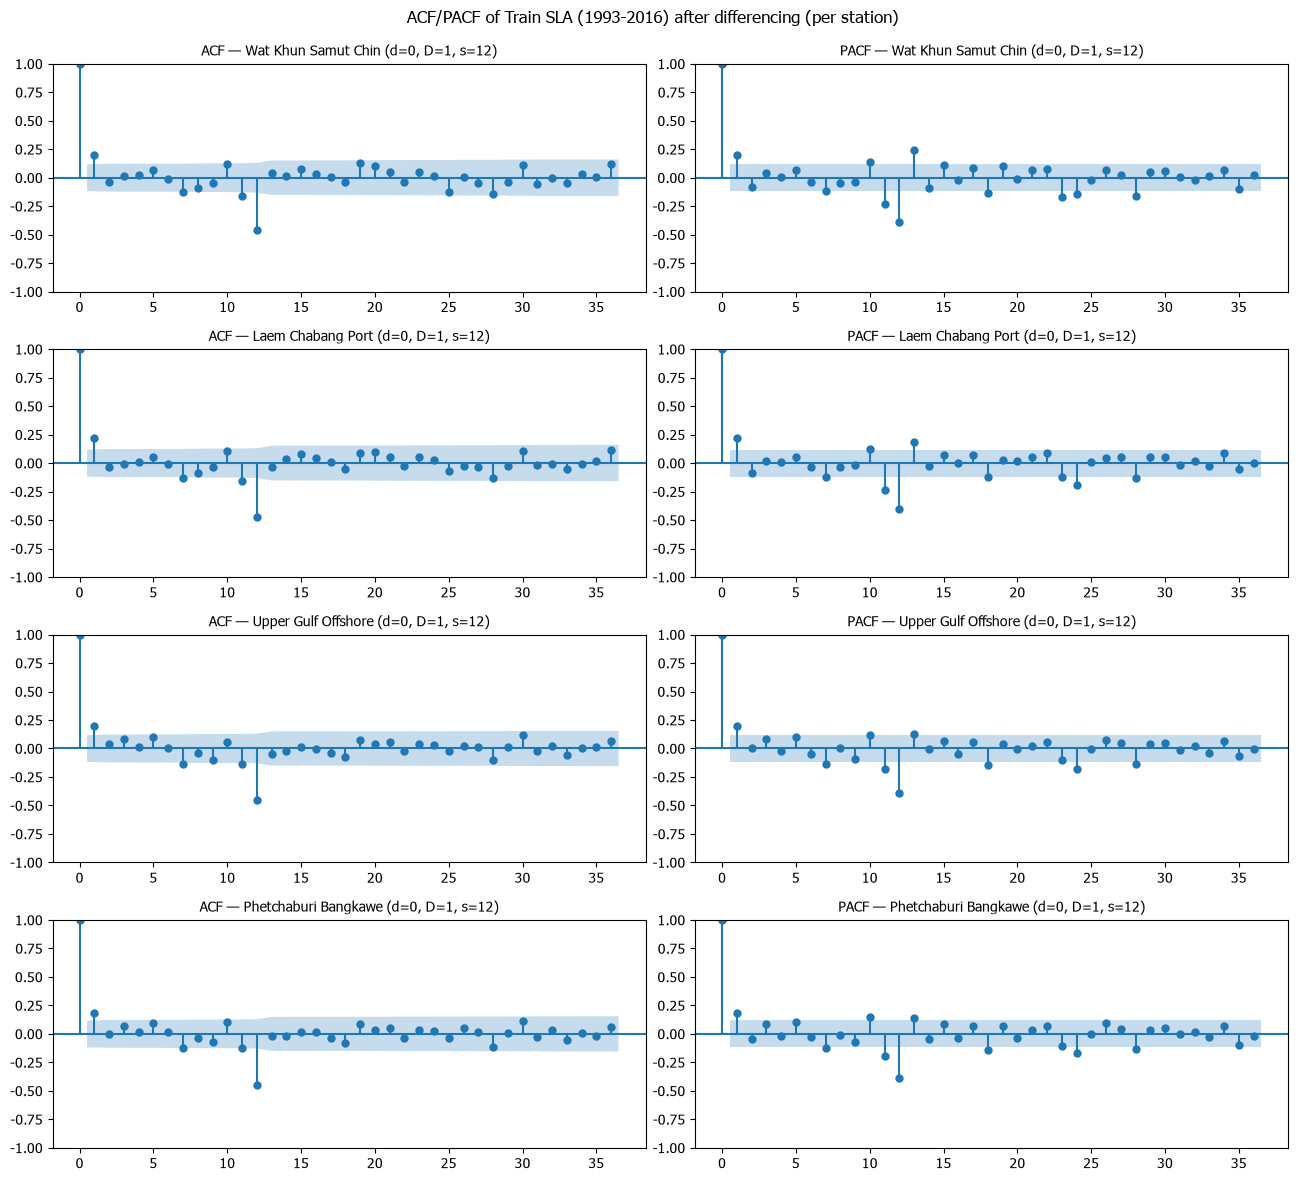

In [22]:
N_LAGS_S2 = 36   # 3 ปี — พอเห็นทั้งวัฏจักรฤดูกาล 12 เดือนและหางของ correlation

stations_s2 = list(CONFIG["stations"])
fig, axes = plt.subplots(len(stations_s2), 2,
                         figsize=(13, 3.0 * len(stations_s2)), squeeze=False)

for row, station in enumerate(stations_s2):
    sarima_series_s2 = build_sarima_series(station)
    train_sla, val_sla, test_sla = split_3way(sarima_series_s2)
    assert_split("SARIMA", station, train_sla, val_sla, test_sla)

    print(f"สถานี: {station}  (Train {len(train_sla)} เดือน "
          f"{train_sla.index.min():%Y-%m}..{train_sla.index.max():%Y-%m})")
    d, D, _fs = choose_d_and_D(train_sla, period=12)   # ลำดับเดียวกับ SARIMA: เลือก D ก่อน แล้ว ADF -> d

    stationary = train_sla.copy()
    if D == 1:
        stationary = stationary.diff(12).dropna()      # seasonal differencing lag-12 ก่อน
    if d > 0:
        stationary = difference(stationary, d)         # แล้วค่อย non-seasonal differencing d ครั้ง
    print()

    plot_acf(stationary, lags=N_LAGS_S2, ax=axes[row][0])
    plot_pacf(stationary, lags=N_LAGS_S2, ax=axes[row][1], method="ywm")
    axes[row][0].set_title(f"ACF — {station} (d={d}, D={D}, s=12)", fontsize=10)
    axes[row][1].set_title(f"PACF — {station} (d={d}, D={D}, s=12)", fontsize=10)

fig.suptitle("ACF/PACF of Train SLA (1993-2016) after differencing (per station)",
             fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig(os.path.join(CONFIG["output_dir"], "final_acf_pacf_all_stations.png"),
            dpi=300, bbox_inches="tight")
plt.show()

**13.2 FINAL EXPERIMENT — pipeline ต่อสถานี (1-step-ahead ทุกโมเดล)**

**preprocessing แยก 3 branch (ไม่ใช้ dataset ที่ถูกตัดด้วยกฎของ RF ร่วมกันทั้งหมด):**
**SARIMA โดย build_sarima_series()   univariate SLA เต็มอนุกรม Jan 1993 – Dec 2024**
**RF     โดย build_dataset()         ตารางฟีเจอร์เดิม (มี SLA_lag1/3/6/12 + dropna)**
**LSTM   โดย build_lstm_dataset()    ไม่มี lag column เห็นอดีตผ่าน sequence 12 เดือน**

In [ ]:
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Input
    from tensorflow.keras.callbacks import EarlyStopping
    HAS_TF_F = True
except ImportError:
    HAS_TF_F = False
    print("!! ไม่พบ tensorflow — จะข้ามโมเดล LSTM")


def build_lstm_final(input_shape, seed=SEED):
    """Single-layer LSTM ขนาดเล็ก เหมาะกับข้อมูล ~300 แถว (LSTM ชั้นเดียว + Dense(1))
    input_shape มาจาก (lookback, จำนวนฟีเจอร์) ที่คำนวณตอนเรียก — ไม่ hard-code"""
    tf.random.set_seed(seed)
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, dropout=0.3, recurrent_dropout=0.2),
        Dense(1),
    ])
    model.compile(optimizer="adam", loss="mse")
    return model


_LSTM_SUMMARY_SHOWN = False      # แสดง summary ครั้งเดียวพอ (สถาปัตยกรรมเหมือนกันทุกสถานี)


def print_lstm_model_summary(model, tag=""):
    """แสดง model.summary() + จำนวนพารามิเตอร์รวม และจำนวนพารามิเตอร์ของแต่ละเลเยอร์
    เป็นการอ่านค่าอย่างเดียว (read-only) ไม่แตะ weight หรือสถานะการเทรน จึงไม่กระทบผลลัพธ์"""
    print()
    print("=" * 78)
    print(f"LSTM MODEL SUMMARY {tag}")
    print("=" * 78)
    model.summary()

    total = int(model.count_params())
    trainable = int(sum(int(np.prod(w.shape)) for w in model.trainable_weights))
    non_trainable = total - trainable

    print()
    print("-- จำนวนพารามิเตอร์ของแต่ละเลเยอร์ --")
    print(f"{'Layer':<18}{'Type':<14}{'Output shape':<22}{'Params':>12}")
    print("-" * 66)
    for lyr in model.layers:
        try:
            out_shape = str(tuple(lyr.output.shape))
        except Exception:
            out_shape = "?"
        print(f"{lyr.name:<18}{lyr.__class__.__name__:<14}"
              f"{out_shape:<22}{lyr.count_params():>12,}")
    print("-" * 66)
    print(f"{'TOTAL params':<54}{total:>12,}")
    print(f"{'  trainable':<54}{trainable:>12,}")
    print(f"{'  non-trainable':<54}{non_trainable:>12,}")
    print("=" * 78)
    print()


def fit_predict_lstm_final(df_st: pd.DataFrame, n_train: int, n_trainval: int, seed: int = SEED):
    """LSTM 2 ขั้น (กัน asymmetry เรื่องปริมาณข้อมูลเทียบกับโมเดลอื่น):
      ขั้น 1: เทรนบน Train + early stopping ด้วย Val → ได้จำนวน epoch ที่ดีที่สุด
              scaler ของ X และ y fit จาก Train เท่านั้น
      ขั้น 2: fit scaler ใหม่จาก Train+Val → สร้างโมเดลใหม่ → เทรนด้วย best_epoch (ไม่มี early stop)
              → ทำนาย Test แล้ว inverse transform กลับเป็นหน่วย SLA จริง
    df_st = ตารางจาก build_lstm_dataset() (index = เดือนของ target)
    n_train / n_trainval = จำนวน "แถว" (ไม่ใช่จำนวน sequence) ของ Train และ Train+Val
    คืนค่า: (คำพยากรณ์ Test บนสเกลจริง, dict สรุปการเทรน)"""
    lookback = CONFIG["lookback"]
    tf.keras.utils.set_random_seed(seed)
    tgt = np.arange(lookback - 1, len(df_st))     # target_pos เริ่มที่ lookback-1 (window รวมเดือน t)
    m_tr = tgt < n_train
    m_va = (tgt >= n_train) & (tgt < n_trainval)
    m_tv = tgt < n_trainval
    m_te = tgt >= n_trainval

    # ขั้น 1 — scaler fit จาก Train เท่านั้น (กัน leakage เข้าการเลือก epoch)
    sc_x1 = MinMaxScaler().fit(df_st[LSTM_FEATURE_COLS].iloc[:n_train])
    sc_y1 = MinMaxScaler().fit(df_st[[TARGET_COL]].iloc[:n_train])
    Xs, ys = create_sequences(sc_x1.transform(df_st[LSTM_FEATURE_COLS]),
                              sc_y1.transform(df_st[[TARGET_COL]]), lookback)
    model = build_lstm_final((lookback, len(LSTM_FEATURE_COLS)), seed)

    # --- แสดงโครงสร้างและจำนวนพารามิเตอร์ของโมเดล ก่อนเริ่มเทรน (ไม่กระทบการเทรน) ---
    global _LSTM_SUMMARY_SHOWN
    if not _LSTM_SUMMARY_SHOWN:
        print_lstm_model_summary(
            model, f"(lookback={lookback}, n_features={len(LSTM_FEATURE_COLS)})")
        _LSTM_SUMMARY_SHOWN = True

    es = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
    hist = model.fit(Xs[m_tr], ys[m_tr], validation_data=(Xs[m_va], ys[m_va]),
                     shuffle=False, epochs=200, batch_size=16, callbacks=[es], verbose=0)
    best_epoch = int(np.argmin(hist.history["val_loss"])) + 1

    # ขั้น 2 — refit บน Train+Val (scaler ใหม่จาก Train+Val) ด้วย best_epoch
    sc_x2 = MinMaxScaler().fit(df_st[LSTM_FEATURE_COLS].iloc[:n_trainval])
    sc_y2 = MinMaxScaler().fit(df_st[[TARGET_COL]].iloc[:n_trainval])
    Xs2, ys2 = create_sequences(sc_x2.transform(df_st[LSTM_FEATURE_COLS]),
                                sc_y2.transform(df_st[[TARGET_COL]]), lookback)
    model2 = build_lstm_final((lookback, len(LSTM_FEATURE_COLS)), seed)
    model2.fit(Xs2[m_tv], ys2[m_tv], shuffle=False, epochs=best_epoch,
               batch_size=16, verbose=0)
    pred_scaled = model2.predict(Xs2[m_te], verbose=0)

    seq_index = df_st.index[tgt]                  # เดือนของ target ในแต่ละ sequence
    info = {
        "best_epoch": best_epoch,
        "epochs_ran": int(len(hist.history["loss"])),
        "early_stopped": bool(len(hist.history["loss"]) < 200),
        "n_features": len(LSTM_FEATURE_COLS),
        "lookback": lookback,
        "input_shape": (lookback, len(LSTM_FEATURE_COLS)),
        "n_seq_train": int(m_tr.sum()),
        "n_seq_val": int(m_va.sum()),
        "n_seq_test": int(m_te.sum()),
        "first_train_target": seq_index[m_tr][0],
        "last_train_target": seq_index[m_tr][-1],
        "first_val_target": seq_index[m_va][0],
        "first_test_target": seq_index[m_te][0],
        "last_test_target": seq_index[m_te][-1],
        "best_val_loss_scaled": float(np.min(hist.history["val_loss"])),
        "final_train_loss_scaled": float(hist.history["loss"][-1]),
    }
    return sc_y2.inverse_transform(pred_scaled).ravel(), info


def fit_predict_rf_final(rf_df: pd.DataFrame, tr: pd.Series, va: pd.Series,
                         trval: pd.Series, station_name: str, seed: int = SEED):
    """Random Forest — Grid Search บน Val แล้ว refit Train+Val ก่อนทำนาย Test

    เลือกพร้อมกัน 3 พารามิเตอร์: n_estimators / max_features / min_samples_leaf
    (เดิมล็อก n_estimators = 500 ไว้ตายตัว จึงสรุปไม่ได้ว่า 500 ต้นเหมาะที่สุดจริง)
    ช่วงค้นหาอยู่ที่เซลล์ 13.1 (RF_*_GRID) ซึ่งตัด max_features="log2" ออกเพราะซ้ำกับ "sqrt"

    ไม่แตะ Test ตอนจูน: fit ด้วย Train เท่านั้น วัดด้วย Val เท่านั้น
    ไม่ต้อง MinMaxScaler: tree ตัดสินด้วย threshold บนลำดับค่า ซึ่ง min-max เป็น monotone
    จึงไม่เปลี่ยนจุดแบ่ง (ไม่ใช่การได้เปรียบ/เสียเปรียบเทียบกับโมเดลอื่น)

    ผลทุก combination ถูก append เข้า rf_grid_records — ใช้สร้างตารางใน 13.3 และ 13.5
    คืนค่า: (คำพยากรณ์ Test, dict hyperparameters ที่เลือก, Val RMSE, จำนวน combination)"""
    n_train, n_trainval = len(tr), len(tr) + len(va)
    df_rf  = rf_df[RF_FEATURE_COLS]
    Xrf_tr = df_rf.iloc[:n_train]
    Xrf_va = df_rf.iloc[n_train:n_trainval]
    Xrf_tv, Xrf_te = df_rf.iloc[:n_trainval], df_rf.iloc[n_trainval:]

    best_par, best_r, n_combos = None, np.inf, 0
    for n_estimators in RF_N_ESTIMATORS_GRID:
        for max_features in RF_MAX_FEATURES_GRID:
            for min_samples_leaf in RF_MIN_SAMPLES_LEAF_GRID:
                rf = RandomForestRegressor(n_estimators=n_estimators,
                                           max_features=max_features,
                                           min_samples_leaf=min_samples_leaf,
                                           random_state=seed, n_jobs=-1)
                rf.fit(Xrf_tr, tr.to_numpy())           # เทรนบน Train เท่านั้น
                r = rmse(va, rf.predict(Xrf_va))        # เลือกด้วย Val (ไม่แตะ Test)
                n_combos += 1
                # เก็บผลทุก combination ไว้ตรวจย้อนหลังว่าค่าไหนถูกทดลองจริงบ้าง
                rf_grid_records.append({
                    "Station": station_name,
                    "Combo_Order": n_combos,
                    "n_estimators": n_estimators,
                    "max_features": max_features,
                    "min_samples_leaf": min_samples_leaf,
                    "Validation_RMSE": r,
                })
                if r < best_r:
                    best_par = {"n_estimators": n_estimators,
                                "max_features": max_features,
                                "min_samples_leaf": min_samples_leaf}
                    best_r = r
    if n_combos != RF_N_COMBOS:
        raise ValueError(f"{station_name} [RF]: ทดลองไป {n_combos} combinations "
                         f"แต่ grid กำหนดไว้ {RF_N_COMBOS}")
    print(f"      Station                : {station_name}")
    print(f"      Best n_estimators      : {best_par['n_estimators']}")
    print(f"      Best max_features      : {best_par['max_features']}")
    print(f"      Best min_samples_leaf  : {best_par['min_samples_leaf']}")
    print(f"      Best Validation RMSE   : {best_r:.4f} m")
    print(f"      Number of combinations : {n_combos}")

    rf = RandomForestRegressor(n_estimators=best_par["n_estimators"],
                               max_features=best_par["max_features"],
                               min_samples_leaf=best_par["min_samples_leaf"],
                               random_state=seed, n_jobs=-1)
    rf.fit(Xrf_tv, trval.to_numpy())                    # refit บน Train+Val
    return rf.predict(Xrf_te), best_par, best_r, n_combos


def run_station_final(station_name: str) -> dict:
    """รันครบ SARIMA / RF / LSTM ของ 1 สถานี ตามดีไซน์ Section 13 (seed เดียว = SEED)"""
    print(f"\n{'='*62}\nสถานี: {station_name}\n{'='*62}")
    h = CONFIG["forecast_horizon"]


    # DATASET FOR SARIMA — univariate SLA (ไม่ผ่าน lag/dropna ของ RF)

    sarima_series = build_sarima_series(station_name)
    sa_tr, sa_va, sa_te = split_3way(sarima_series)
    assert_split("SARIMA", station_name, sa_tr, sa_va, sa_te)
    sa_trval = pd.concat([sa_tr, sa_va])            # Jan 1993 – Dec 2019


    # DATASET FOR RANDOM FOREST — logic เดิมทุกประการ

    rf_df = build_dataset(station_name)
    sla = rf_df[TARGET_COL]
    tr, va, te = split_3way(sla)
    assert_split("RF", station_name, tr, va, te)
    n_train, n_trainval = len(tr), len(tr) + len(va)
    trval = sla.iloc[:n_trainval]                    # Train+Val สำหรับ refit สุดท้าย
    y_test = te.to_numpy()


    # DATASET FOR LSTM — ไม่มี lag column, ใช้ sequence 12 เดือน

    lstm_df = build_lstm_dataset(station_name)
    ls_tr, ls_va, ls_te = split_3way(lstm_df[TARGET_COL])
    assert_split("LSTM", station_name, ls_tr, ls_va, ls_te)
    n_train_lstm, n_trainval_lstm = len(ls_tr), len(ls_tr) + len(ls_va)

    lookback = CONFIG["lookback"]
    _tgt_pos = np.arange(lookback - 1, len(lstm_df))
    _seq_index = lstm_df.index[_tgt_pos]
    n_seq = (int((_tgt_pos < n_train_lstm).sum()),
             int(((_tgt_pos >= n_train_lstm) & (_tgt_pos < n_trainval_lstm)).sum()),
             int((_tgt_pos >= n_trainval_lstm).sum()))
    if n_seq != EXPECTED_LSTM_SEQ:
        raise ValueError(
            f"{station_name} [LSTM]: จำนวน sequence (Train, Val, Test) = {n_seq} "
            f"แต่คาดหวัง {EXPECTED_LSTM_SEQ} — ให้ตรวจ lookback/alignment ก่อนเทรน")

    print(f"SARIMA  Train {len(sa_tr):3d} [{sa_tr.index.min():%Y-%m}..{sa_tr.index.max():%Y-%m}] | "
          f"Val {len(sa_va)} | Test {len(sa_te)}")
    print(f"RF      Train {len(tr):3d} [{tr.index.min():%Y-%m}..{tr.index.max():%Y-%m}] | "
          f"Val {len(va)} | Test {len(te)}")
    print(f"LSTM    Train {n_seq[0]:3d} seq [{_seq_index[0]:%Y-%m}..{ls_tr.index.max():%Y-%m}] | "
          f"Val {n_seq[1]} seq | Test {n_seq[2]} seq  (rows {len(lstm_df)})")

    # ---- ค่าจริงของ Test ต้องเป็นชุดเดียวกันทั้ง 3 โมเดล จึงเทียบผลกันได้ตรง ๆ ----
    assert (te.index == sa_te.index).all() and (te.index == ls_te.index).all(), (
        f"{station_name}: เดือนของ Test ไม่ตรงกันข้ามโมเดล")
    assert np.allclose(y_test, sa_te.to_numpy()) and np.allclose(y_test, ls_te.to_numpy()), (
        f"{station_name}: ค่าจริงของ Test ไม่ตรงกันข้ามโมเดล")


    # ตรวจ alignment แบบ explicit (กัน off-by-one ของ forecast t+1)

    probe = te.index[0]                                        # target 2020-01
    p_src = (probe.to_period("M") - h).to_timestamp(how="start")        # เดือน t
    p_l12 = (probe.to_period("M") - h - 12).to_timestamp(how="start")   # เดือน t-12
    assert np.isclose(rf_df.loc[probe, "SLA_hist"], sarima_series.loc[p_src])
    assert np.isclose(rf_df.loc[probe, "SLA_lag12"], sarima_series.loc[p_l12])
    assert np.isclose(rf_df.loc[probe, TARGET_COL], sarima_series.loc[probe])
    print(f"   [RF align]     feature month t = {p_src:%Y-%m} | "
          f"SLA_lag12 = SLA({p_l12:%Y-%m}) | target = SLA({probe:%Y-%m})")

    first_target = _seq_index[0]                               # target แรกของ sequence
    win_rows = lstm_df.index[0:lookback]                       # แถว target_time ของ window แรก
    win_start = (win_rows[0].to_period("M") - h).to_timestamp(how="start")   # Jan 1993
    win_end   = (win_rows[-1].to_period("M") - h).to_timestamp(how="start")  # Dec 1993
    assert np.isclose(lstm_df.loc[first_target, TARGET_COL], sarima_series.loc[first_target]), (
        f"{station_name} [LSTM]: target ของ sequence แรกไม่ตรงกับ SLA จริง")
    assert np.isclose(lstm_df[LSTM_FEATURE_COLS].iloc[0]["SLA_hist"], sarima_series.loc[win_start])
    print(f"   [LSTM align]   window start = {win_start:%Y-%m} | window end = {win_end:%Y-%m} | "
          f"target = {first_target:%Y-%m} (SLA = {lstm_df.loc[first_target, TARGET_COL]:.4f} m)")

    print(f"   [SARIMA align] Train last actual = {sa_tr.index.max():%Y-%m} -> "
          f"first Validation forecast = {sa_va.index.min():%Y-%m}")
    print(f"                  Train+Val last actual = {sa_trval.index.max():%Y-%m} -> "
          f"first Test forecast = {sa_te.index.min():%Y-%m}")

    # ---- 01 — บันทึกช่วง/จำนวนของ split ที่เพิ่งเกิดขึ้นข้างบน (ไม่ได้ split ใหม่) ----
    raw_start, raw_end = month_span(sarima_series)
    _split_meta = [
        ("SARIMA", "months", sa_tr, sa_va, sa_te, len(sarima_series),
         "univariate SLA — ไม่ผ่าน lag/dropna ของ RF"),
        ("RF", "months", tr, va, te, len(rf_df),
         "หลัง dropna(SLA_lag12) — target เริ่ม Feb 1994 (คงเดิม)"),
        ("LSTM", "sequences", ls_tr, ls_va, ls_te, len(lstm_df),
         f"rows {len(lstm_df)} (target {month_span(lstm_df)[0]}–{month_span(lstm_df)[1]}), "
         f"sequences {n_seq[0]}/{n_seq[1]}/{n_seq[2]} (lookback {lookback})"),
    ]
    for _m, _unit, _tr, _va, _te, _n_rows, _note in _split_meta:
        if _m == "LSTM":
            n_tr_eff, tr_start = n_seq[0], f"{_seq_index[0]:%Y-%m}"
        else:
            n_tr_eff, tr_start = len(_tr), month_span(_tr)[0]
        data_split_records.append({
            "Model": _m,
            "Station": station_name,
            "Unit": _unit,
            "Raw_Start": raw_start,
            "Raw_End": raw_end,
            "N_Raw_Months": len(sarima_series),
            "N_Dataset_Rows": _n_rows,
            "Train_Start": tr_start,
            "Train_End": month_span(_tr)[1],
            "N_Train": n_tr_eff,
            "Val_Start": month_span(_va)[0],
            "Val_End": month_span(_va)[1],
            "N_Val": len(_va),
            "Test_Start": month_span(_te)[0],
            "Test_End": month_span(_te)[1],
            "N_Test": len(_te),
            "Note": _note,
        })

    preds, extra = {}, {}

    # [1/3] SARIMA — เลือก (p,d,q)(P,D,Q)s ด้วย Val → refit Train+Val → rolling 1-step บน Test
    print("\n[1/3] SARIMA (rolling 1-step-ahead)")
    order, seasonal_order = select_sarima_on_val(sa_tr, sa_va, station=station_name)
    # 05 — เติมขนาด Test ให้ record ของสถานีนี้ที่เพิ่งถูกเก็บไว้
    if sarima_selected_records and sarima_selected_records[-1]["Station"] == station_name:
        sarima_selected_records[-1]["Test_N"] = len(sa_te)

    preds["SARIMA"] = rolling_sarima_1step(sa_trval, sa_te, order, seasonal_order,
                                           capture_params=True).to_numpy()
    # 06 — อ่าน coefficient จาก result object ของ fit เดิมบรรทัดบน (ไม่ได้ fit ซ้ำ)
    for _pname, _coef, _se, _z, _pv in zip(_LAST_SARIMA_FIT["param_names"],
                                           _LAST_SARIMA_FIT["params"],
                                           _LAST_SARIMA_FIT["bse"],
                                           _LAST_SARIMA_FIT["tvalues"],
                                           _LAST_SARIMA_FIT["pvalues"]):
        sarima_coefficient_records.append({
            "Station": station_name,
            "Order": str(order),
            "Seasonal_Order": str(seasonal_order),
            "Fitted_On": "Train+Val (final model, before rolling append on Test)",
            "Parameter": _pname,
            "Coefficient": float(_coef),
            "Std_Error": float(_se),
            "z_value": float(_z),
            "P_Value": float(_pv),
        })

    # 07 — residual diagnostics ของ final model (fit บน Train+Val, ไม่แตะ Test)
    _resid_rec = sarima_residual_diagnostics(
        _LAST_SARIMA_FIT["resid"], station_name, order, seasonal_order,
        fitted_on=f"Train+Val {sa_trval.index.min():%Y-%m}..{sa_trval.index.max():%Y-%m} "
                  f"(n={len(sa_trval)})")
    _resid_rec["Converged"] = _LAST_SARIMA_FIT["converged"]
    _resid_rec["AIC"] = _LAST_SARIMA_FIT["aic"]
    _resid_rec["BIC"] = _LAST_SARIMA_FIT["bic"]
    sarima_residual_records.append(_resid_rec)
    print(f"   residual: mean = {_resid_rec['Residual_Mean']:+.5f} | "
          f"SD = {_resid_rec['Residual_SD']:.5f} | "
          f"Ljung-Box(12) p = {_resid_rec['LjungBox_lag12_PValue']:.4f} | "
          f"Ljung-Box(24) p = {_resid_rec['LjungBox_lag24_PValue']:.4f} | "
          f"Jarque-Bera p = {_resid_rec['JarqueBera_PValue']:.4f}")

    extra["sarima_order"] = order
    extra["sarima_seasonal_order"] = seasonal_order

    # [2/3] Random Forest — Grid Search (n_estimators, max_features, min_samples_leaf) บน Val
    #   → refit Train+Val ด้วย SEED เดียว → ทำนาย Test  (ไม่แตะ Test ตอนจูน)
    #   ตรรกะอยู่ใน fit_predict_rf_final() เพื่อให้ 13.5 (รีเฟรชเฉพาะ RF) ใช้ตัวเดียวกันได้
    print(f"[2/3] Random Forest (Grid Search {RF_N_COMBOS} ชุดบน Val -> refit Train+Val)")
    preds["RF"], best_rf_par, best_rf_r, n_rf_combos = fit_predict_rf_final(
        rf_df, tr, va, trval, station_name, SEED)
    extra["rf_n_estimators"]     = best_rf_par["n_estimators"]
    extra["rf_max_features"]     = best_rf_par["max_features"]
    extra["rf_min_samples_leaf"] = best_rf_par["min_samples_leaf"]
    extra["rf_val_rmse"]         = best_rf_r
    extra["rf_n_combinations"]   = n_rf_combos

    # [3/3] LSTM — 2 ขั้น (early stop บน Val → refit Train+Val) ด้วย SEED เดียว
    if HAS_TF_F:
        print("[3/3] LSTM (early stop บน Val -> refit Train+Val)")
        preds["LSTM"], lstm_info = fit_predict_lstm_final(
            lstm_df, n_train_lstm, n_trainval_lstm, SEED)
        print(f"      best_epoch = {lstm_info['best_epoch']} "
              f"(รันไป {lstm_info['epochs_ran']} epoch) | "
              f"input_shape = {lstm_info['input_shape']} | "
              f"sequences {lstm_info['n_seq_train']}/{lstm_info['n_seq_val']}/{lstm_info['n_seq_test']}")
        extra["lstm_best_epoch"] = lstm_info["best_epoch"]
        extra["lstm_input_shape"] = lstm_info["input_shape"]
        lstm_training_records.append({
            "Station": station_name,
            "Features": ", ".join(LSTM_FEATURE_COLS),
            "N_Features": lstm_info["n_features"],
            "Lookback": lstm_info["lookback"],
            "Input_Shape": str(lstm_info["input_shape"]),
            "N_Seq_Train": lstm_info["n_seq_train"],
            "N_Seq_Val": lstm_info["n_seq_val"],
            "N_Seq_Test": lstm_info["n_seq_test"],
            "First_Train_Target": f"{lstm_info['first_train_target']:%Y-%m}",
            "Last_Train_Target": f"{lstm_info['last_train_target']:%Y-%m}",
            "First_Val_Target": f"{lstm_info['first_val_target']:%Y-%m}",
            "First_Test_Target": f"{lstm_info['first_test_target']:%Y-%m}",
            "Last_Test_Target": f"{lstm_info['last_test_target']:%Y-%m}",
            "Best_Epoch": lstm_info["best_epoch"],
            "Epochs_Ran_Stage1": lstm_info["epochs_ran"],
            "Early_Stopped": lstm_info["early_stopped"],
            "Best_Val_Loss_Scaled": lstm_info["best_val_loss_scaled"],
            "Final_Train_Loss_Scaled": lstm_info["final_train_loss_scaled"],
            "Units": 64, "Dropout": 0.3, "Recurrent_Dropout": 0.2,
            "Batch_Size": 16, "Max_Epochs": 200, "EarlyStopping_Patience": 15,
            "Optimizer": "adam", "Loss": "mse", "Shuffle": False, "Seed": SEED,
        })

    # ตัวชี้วัด MSE / MAE / RMSE / R² บนสเกลจริง (Test แตะครั้งเดียว)
    metrics = {m: evaluate_forecast(y_test, p) for m, p in preds.items()}
    print()
    for m, met in metrics.items():
        print_metrics(met, m)
    return {"preds": preds, "metrics": metrics, "y_test": y_test,
            "test_index": te.index, "extra": extra}


print("13.2 pipeline เรียบร้อย")

13.2 pipeline เรียบร้อย


#  13.2b VALIDATION GATE  ตรวจ dataset ของทั้ง 3 branch ก่อนฝึกโมเดล

In [25]:
print("=" * 60)
print("DATASET VALIDATION AFTER PREPROCESSING SEPARATION")
print("=" * 60)

_gate = {}
for _station in CONFIG["stations"]:
    _sa = build_sarima_series(_station)
    _rf = build_dataset(_station)
    _ls = build_lstm_dataset(_station)

    _sa_tr, _sa_va, _sa_te = split_3way(_sa)
    _rf_tr, _rf_va, _rf_te = split_3way(_rf[TARGET_COL])
    _ls_tr, _ls_va, _ls_te = split_3way(_ls[TARGET_COL])

    assert_split("SARIMA", _station, _sa_tr, _sa_va, _sa_te)
    assert_split("RF", _station, _rf_tr, _rf_va, _rf_te)
    assert_split("LSTM", _station, _ls_tr, _ls_va, _ls_te)

    _lb = CONFIG["lookback"]
    _pos = np.arange(_lb - 1, len(_ls))
    _n_tr_rows, _n_tv_rows = len(_ls_tr), len(_ls_tr) + len(_ls_va)
    _seq = (int((_pos < _n_tr_rows).sum()),
            int(((_pos >= _n_tr_rows) & (_pos < _n_tv_rows)).sum()),
            int((_pos >= _n_tv_rows).sum()))
    if _seq != EXPECTED_LSTM_SEQ:
        raise ValueError(
            f"{_station} [LSTM]: sequence (Train, Val, Test) = {_seq} "
            f"แต่คาดหวัง {EXPECTED_LSTM_SEQ}")

    # LSTM ต้องไม่มีคอลัมน์ lag ของ RF หลุดเข้ามา / RF ต้องยังมีครบ
    assert not any(str(c).startswith("SLA_lag") for c in _ls.columns), (
        f"{_station}: พบ SLA_lag* ใน LSTM dataset")
    assert all(c in _rf.columns for c in
               ["SLA_lag1", "SLA_lag3", "SLA_lag6", "SLA_lag12"]), (
        f"{_station}: RF dataset ขาดคอลัมน์ lag")

    _gate[_station] = {
        "sarima": (_sa, _sa_tr, _sa_va, _sa_te),
        "rf": (_rf, _rf_tr, _rf_va, _rf_te),
        "lstm": (_ls, _ls_tr, _ls_va, _ls_te, _seq, _ls.index[_pos][0]),
    }

_W = 28

print("\nSARIMA")
print(f"{'Station':<{_W}}{'Start':<10}{'End':<10}{'Train':>6}{'Val':>5}{'Test':>6}")
for _st, _g in _gate.items():
    _sa, _tr, _va, _te = _g["sarima"]
    print(f"{_st:<{_W}}{month_span(_sa)[0]:<10}{month_span(_sa)[1]:<10}"
          f"{len(_tr):>6}{len(_va):>5}{len(_te):>6}")

print("\nRF")
print(f"{'Station':<{_W}}{'First target':<15}{'Train':>6}{'Val':>5}{'Test':>6}")
for _st, _g in _gate.items():
    _rf, _tr, _va, _te = _g["rf"]
    print(f"{_st:<{_W}}{month_span(_rf)[0]:<15}{len(_tr):>6}{len(_va):>5}{len(_te):>6}")

print("\nLSTM")
print(f"{'Station':<{_W}}{'First target':<15}{'Train Seq':>10}{'Val Seq':>9}{'Test Seq':>10}")
for _st, _g in _gate.items():
    _ls, _tr, _va, _te, _seq, _first_seq_target = _g["lstm"]
    print(f"{_st:<{_W}}{_first_seq_target:%Y-%m}{'':<9}"
          f"{_seq[0]:>10}{_seq[1]:>9}{_seq[2]:>10}")

print("\nช่วง Validation/Test ต้องเหมือนกันทุกโมเดล:",
      f"Val {EXPECTED_VAL_SPAN[0]}..{EXPECTED_VAL_SPAN[1]} |",
      f"Test {EXPECTED_TEST_SPAN[0]}..{EXPECTED_TEST_SPAN[1]}")
print("VALIDATION GATE ผ่านทุกสถานี — พร้อมฝึกโมเดลใน 13.3")

del _gate

DATASET VALIDATION AFTER PREPROCESSING SEPARATION

SARIMA
Station                     Start     End        Train  Val  Test
Wat Khun Samut Chin         1993-01   2024-12      288   36    60
Laem Chabang Port           1993-01   2024-12      288   36    60
Upper Gulf Offshore         1993-01   2024-12      288   36    60
Phetchaburi Bangkawe        1993-01   2024-12      288   36    60

RF
Station                     First target    Train  Val  Test
Wat Khun Samut Chin         1994-02           275   36    60
Laem Chabang Port           1994-02           275   36    60
Upper Gulf Offshore         1994-02           275   36    60
Phetchaburi Bangkawe        1994-02           275   36    60

LSTM
Station                     First target    Train Seq  Val Seq  Test Seq
Wat Khun Samut Chin         1994-01                276       36        60
Laem Chabang Port           1994-01                276       36        60
Upper Gulf Offshore         1994-01                276       36        60
Ph

**13.3 FINAL EXPERIMENT  รันทุกสถานี + ตารางสรุป (Test แตะครั้งเดียว)**

In [ ]:
# ล้างที่เก็บผลก่อนรันรอบใหม่ กัน record ซ้ำเมื่อรันเซลล์นี้หลายครั้ง
for _rec_list in (data_split_records, sarima_stationarity_records,
                  sarima_gridsearch_records, sarima_top5_validation_records,
                  sarima_selected_records, sarima_coefficient_records,
                  sarima_residual_records, lstm_training_records,
                  rf_grid_records):
    _rec_list.clear()

final_out = {}
for station in CONFIG["stations"]:
    final_out[station] = run_station_final(station)

#  Random Forest — ผล Grid Search ทุก combination ทุกสถานี
# หลักฐานว่า n_estimators ถูกคัดเลือกด้วย Validation RMSE จริง ไม่ได้ล็อกไว้ล่วงหน้า
rf_grid_results, rf_best_summary = build_rf_grid_tables(
    rf_grid_records, {st: out["extra"] for st, out in final_out.items()})

print(f"\nRANDOM FOREST — Grid Search {RF_N_COMBOS} combinations ต่อสถานี "
      f"(เลือกด้วย Validation RMSE เท่านั้น ไม่แตะ Test)")
print("ค่าที่ดีที่สุดของแต่ละสถานี")
display(rf_best_summary)
print("5 อันดับแรกของแต่ละสถานี (Validation RMSE ต่ำสุด):")
display(rf_grid_results.groupby("Station", observed=True).head(5).reset_index(drop=True))

#  ตารางตัวชี้วัด (Test แตะครั้งเดียว — นี่คือผลสุดท้าย)
rows = []
for st, out in final_out.items():
    for m, met in out["metrics"].items():
        rows.append({"Station": st, "Model": m,
                     "MSE": met["MSE"], "MAE": met["MAE"],
                     "RMSE": met["RMSE"], "R2": met["R2"]})

final_summary = pd.DataFrame(rows)

# เรียงสถานีตามลำดับใน CONFIG และเรียงโมเดลตาม MODELS (SARIMA -> RF -> LSTM)
# ไม่ใช่ตามตัวอักษร เพื่อให้ตารางในเล่มอ่านตามลำดับที่ออกแบบไว้
final_summary["Station"] = pd.Categorical(final_summary["Station"],
                                          categories=list(CONFIG["stations"]), ordered=True)
final_summary["Model"]   = pd.Categorical(final_summary["Model"],
                                          categories=MODELS, ordered=True)
final_summary = (final_summary.sort_values(["Station", "Model"])
                              .set_index(["Station", "Model"]))

# ต้องได้ 3 โมเดล x 4 สถานี = 12 ผลลัพธ์พอดี
n_expected = len(MODELS) * len(CONFIG["stations"])
assert len(final_summary) == n_expected, (
    f"ต้องได้ {len(MODELS)} โมเดล x {len(CONFIG['stations'])} สถานี = {n_expected} แถว "
    f"แต่ได้ {len(final_summary)} แถว (ถ้าขาด LSTM ให้ตรวจว่าติดตั้ง tensorflow แล้ว)")

print("\nFINAL — ตัวชี้วัดทุกโมเดล (Test 2020–2024, สเกลจริง, 1-step-ahead)")
print("ตัวชี้วัดหลักในการเปรียบเทียบ = RMSE (หน่วยเมตร)")
display(final_summary.round(4))
final_csv = os.path.join(CONFIG["output_dir"], "final_metrics_3models.csv")
final_summary.to_csv(final_csv)

print(f"บันทึกผล: {final_csv}")

# ป้ายบอกว่า final_out รอบนี้มาจาก 13.3 (เทรนสดครบ 3 โมเดล)
# เซลล์ 13.3b อ่านค่านี้เพื่อข้ามตัวเอง จะได้ไม่เอาค่าเก่าจาก CSV มาทับผลสด
_FINAL_OUT_SOURCE = "13.3"


สถานี: Wat Khun Samut Chin
SARIMA  Train 288 [1993-01..2016-12] | Val 36 | Test 60
RF      Train 275 [1994-02..2016-12] | Val 36 | Test 60
LSTM    Train 276 seq [1994-01..2016-12] | Val 36 seq | Test 60 seq  (rows 383)
   [RF align]     feature month t = 2019-12 | SLA_lag12 = SLA(2018-12) | target = SLA(2020-01)
   [LSTM align]   window start = 1993-01 | window end = 1993-12 | target = 1994-01 (SLA = 0.1670 m)
   [SARIMA align] Train last actual = 2016-12 -> first Validation forecast = 2017-01
                  Train+Val last actual = 2019-12 -> first Test forecast = 2020-01

[1/3] SARIMA (rolling 1-step-ahead)
   Log transform: ข้าม (SLA เป็น anomaly และอาจมีค่าติดลบ)
   Seasonal strength Fs = 0.905 (period=12)  ->  D = 1
   ADF [D=1, d=0]  statistic =  -5.1718   p-value = 0.0000  ->  STATIONARY
   => เลือก d = 0, D = 1
   SARIMA(1, 0, 2)x(0, 1, 1, 12)  AIC =   -765.2   Val RMSE = 0.0492
   SARIMA(1, 0, 0)x(0, 1, 1, 12)  AIC =   -761.8   Val RMSE = 0.0565
   SARIMA(2, 0, 0)x(0, 1, 1,

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,497 (72.25 KB)

 Trainable params: 18,497 (72.25 KB)

...

5 อันดับแรกของแต่ละสถานี (Validation RMSE ต่ำสุด):


,Station,Rank_In_Station,Combo_Order,n_estimators,max_features,min_samples_leaf,Validation_RMSE
0,Wat Khun Samut Chin,1,14,200,0.5,2,0.062220
1,Wat Khun Samut Chin,2,32,500,0.5,2,0.062747
2,Wat Khun Samut Chin,3,23,300,0.5,2,0.062756
3,Wat Khun Samut Chin,4,26,300,sqrt,2,0.063202
4,Wat Khun Samut Chin,5,24,300,0.5,4,0.063280
5,Laem Chabang Port,1,25,300,sqrt,1,0.053843
6,Laem Chabang Port,2,16,200,sqrt,1,0.053913
7,Laem Chabang Port,3,7,100,sqrt,1,0.054296
8,Laem Chabang Port,4,13,200,0.5,1,0.054430
9,Laem Chabang Port,5,52,1000,sqrt,1,0.054457



FINAL — ตัวชี้วัดทุกโมเดล (Test 2020–2024, สเกลจริง, 1-step-ahead)
ตัวชี้วัดหลักในการเปรียบเทียบ = RMSE (หน่วยเมตร)


MSE     MAE    RMSE      R2
Station              Model                                 
Wat Khun Samut Chin  SARIMA  0.0023  0.0418  0.0485  0.8905
                     RF      0.0044  0.0551  0.0667  0.7929
                     LSTM    0.0056  0.0629  0.0748  0.7389
Laem Chabang Port    SARIMA  0.0021  0.0380  0.0458  0.9061
                     RF      0.0043  0.0557  0.0655  0.8075
                     LSTM    0.0054  0.0616  0.0736  0.7572
Upper Gulf Offshore  SARIMA  0.0022  0.0395  0.0471  0.9053
                     RF      0.0035  0.0502  0.0590  0.8515
                     LSTM    0.0053  0.0615  0.0728  0.7737
Phetchaburi Bangkawe SARIMA  0.0016  0.0345  0.0403  0.9141
                     RF      0.0033  0.0485  0.0576  0.8245
                     LSTM    0.0047  0.0559  0.0683  0.7530

บันทึกผล: D:\defence_sla_WSL_backup\outputs_fair_comparison\final_metrics_3models.csv


#  13.3b RF-ONLY REFRESH รันใหม่เฉพาะ Random Forest (ไม่แตะ SARIMA / LSTM)
#
#  ใช้เมื่อ: แก้ grid ของ RF แล้วต้องการอัปเดตตัวเลข RF อย่างเดียว
#           โดยที่ตัวเลข SARIMA/LSTM ต้องเท่าเดิมทุกหลัก
#
#  13.3 เรียก run_station_final() ซึ่งเทรนครบทั้ง 3 โมเดล
#     SARIMA ได้ผลเดิม (deterministic) แต่ LSTM อาจขยับทศนิยมท้าย ๆ จาก float
#     round-off ของ TensorFlow ทำให้ตัวเลขที่ตรวจไว้ในเล่มแล้วเปลี่ยนโดยไม่ตั้งใจ
#
#  เซลล์นี้ไม่ fit SARIMA/LSTM เลยแม้แต่ครั้งเดียว — อ่านค่าของสองโมเดลนั้นจาก CSV ของ
#  run เดิม แล้วเขียนกลับเหมือนเดิมทุกตัวอักษร เปลี่ยนเฉพาะแถวที่ Model == "RF"
#  (มี guard ตรวจว่าแถวที่ไม่ใช่ RF เหมือนเดิมจริง ถ้าไม่เหมือนจะ error ก่อนเขียนไฟล์)
#
#  ต้องรันมาก่อน: เซลล์ตั้งค่า (seed / BASE_DIR / CONFIG / DATA LOADING) 
#  รันแทน 13.3 ได้เลย  |  ถ้าเพิ่งรัน 13.3 ครบทั้งเล่มแล้ว เซลล์นี้ข้ามได้

In [ ]:
def refresh_rf_only():
    """รันใหม่เฉพาะ RF แล้วอัปเดตเฉพาะแถว RF ในไฟล์ผลลัพธ์"""
    global rf_refresh, rf_grid_results, rf_best_summary
    global final_out, final_summary, _FINAL_OUT_SOURCE

    import re
    import shutil
    from pathlib import Path

        # 1. ตรวจของที่ต้องมีก่อน

    for _name in ["CONFIG", "MODELS", "TARGET_COL", "SEED", "SARIMA_OUTPUT_DIR",
                  "build_dataset", "split_3way", "assert_split", "rmse",
                  "fit_predict_rf_final", "build_rf_grid_tables", "rf_grid_records",
                  "evaluate_forecast", "print_metrics", "RF_N_COMBOS"]:
        if _name not in globals():
            raise RuntimeError(f"ยังไม่มี {_name} — ให้รันเซลล์ตั้งค่า + 13.0 + 13.1 + 13.2 ก่อน")

    _OUT = Path(CONFIG["output_dir"])
    _SEP = Path(SARIMA_OUTPUT_DIR)

    # ไฟล์ที่จะถูกแก้ (แก้เฉพาะแถว RF) : path -> ชนิดของการอัปเดต
    _TARGETS = {
        _OUT / "final_metrics_3models.csv":    "metrics",
        _SEP / "09_final_model_metrics.csv":   "metrics",
        _OUT / "test_predictions_3models.csv": "predictions",
        _OUT / "model_settings_3models.csv":   "settings",
    }
    _missing = [str(p) for p in _TARGETS if not p.exists()]
    if _missing:
        raise FileNotFoundError("ไม่พบไฟล์ผลลัพธ์ของ run เดิม:\n  " + "\n  ".join(_missing)
                                + "\nถ้ายังไม่เคยรันครบทั้ง 3 โมเดล ให้ใช้ 13.3 แทนเซลล์นี้")


    # 1b. ตรวจสิทธิ์เขียนไฟล์ก่อนเริ่มคำนวณ
    #     ถ้าเปิด CSV ค้างไว้ใน Excel ไฟล์จะถูกล็อก แล้ว to_csv จะพังตอนท้าย
    #     หลังเสียเวลา grid search ไปหลายนาทีแล้ว — จึงเช็คให้รู้ตั้งแต่วินาทีแรก

    _will_write = list(_TARGETS) + [_SEP / "rf_gridsearch_all_combinations.csv",
                                    _SEP / "rf_best_hyperparameters.csv"]
    _locked = []
    for _p in _will_write:
        if not _p.exists():
            continue                      # ไฟล์ใหม่ ยังไม่มีให้ล็อก
        try:
            with open(_p, "r+b"):
                pass
        except PermissionError:
            _locked.append(_p.name)
    if _locked:
        _msg = ["ไฟล์ต่อไปนี้ถูกโปรแกรมอื่นล็อกอยู่ (ส่วนใหญ่คือเปิดค้างใน Excel):"]
        _msg += [f"  {_name}" for _name in _locked]
        _msg += ["", "ให้ปิดไฟล์เหล่านี้ใน Excel ก่อน แล้วรันเซลล์นี้ใหม่"]
        raise PermissionError(chr(10).join(_msg))


    # 2. สำรองไฟล์เดิมก่อนแก้

    _BAK = _OUT / "_backup_before_rf_grid"
    _BAK.mkdir(parents=True, exist_ok=True)
    for _p in _TARGETS:
        _dst = _BAK / _p.name
        if not _dst.exists():
            shutil.copy2(_p, _dst)
            print(f"สำรอง {_p.name}")
    print(f"ไฟล์ก่อนรีเฟรชอยู่ที่ {_BAK}\n")


    # 3. รัน RF ใหม่ทุกสถานี (Grid Search บน Val -> refit Train+Val -> ทำนาย Test)
    #    ใช้ fit_predict_rf_final() ตัวเดียวกับ 13.2 จึงเป็นตรรกะเดียวกันแน่นอน

    rf_grid_records.clear()          # กัน record ซ้ำเมื่อรันเซลล์นี้หลายครั้ง
    rf_refresh = {}

    for _station in CONFIG["stations"]:
        print("=" * 62)
        _rf_df = build_dataset(_station)
        _sla = _rf_df[TARGET_COL]
        _tr, _va, _te = split_3way(_sla)
        assert_split("RF", _station, _tr, _va, _te)
        _trval = _sla.iloc[:len(_tr) + len(_va)]

        _pred, _par, _val_rmse, _n_combos = fit_predict_rf_final(
            _rf_df, _tr, _va, _trval, _station, SEED)

        _met = evaluate_forecast(_te.to_numpy(), _pred)
        print_metrics(_met, "RF")
        rf_refresh[_station] = {
            "pred": _pred, "metrics": _met,
            "test_index": _te.index, "y_test": _te.to_numpy(),
            "extra": {"rf_n_estimators": _par["n_estimators"],
                      "rf_max_features": _par["max_features"],
                      "rf_min_samples_leaf": _par["min_samples_leaf"],
                      "rf_val_rmse": _val_rmse,
                      "rf_n_combinations": _n_combos},
        }


    # 4. ตาราง Grid Search

    rf_grid_results, rf_best_summary = build_rf_grid_tables(
        rf_grid_records, {st: r["extra"] for st, r in rf_refresh.items()})

    print(f"\nRANDOM FOREST — Grid Search {RF_N_COMBOS} combinations ต่อสถานี "
          f"(เลือกด้วย Validation RMSE เท่านั้น ไม่แตะ Test)")
    display(rf_best_summary)


    # 5. อัปเดตไฟล์ผลลัพธ์เฉพาะแถว RF

    def _read_csv_keep_encoding(path: Path):
        """อ่าน CSV พร้อมจำว่าไฟล์เดิมมี BOM หรือไม่ เพื่อเขียนกลับด้วย encoding เดิม
        (ไฟล์ในโปรเจกต์นี้มีทั้งแบบมีและไม่มี BOM — เขียนผิดแบบจะทำให้ทั้งไฟล์ต่างจากเดิม)"""
        has_bom = path.open("rb").read(3) == b"\xef\xbb\xbf"
        enc = "utf-8-sig" if has_bom else "utf-8"
        return pd.read_csv(path, encoding=enc), enc


    for _path, _kind in _TARGETS.items():
        _df, _enc = _read_csv_keep_encoding(_path)
        _before = _df.copy()
        _mask = _df["Model"] == "RF"
        if not _mask.any():
            raise ValueError(f"{_path.name}: ไม่พบแถว Model == 'RF'")

        if _kind == "metrics":
            for _st, _r in rf_refresh.items():
                _m = _mask & (_df["Station"] == _st)
                if _m.sum() != 1:
                    raise ValueError(f"{_path.name}: แถว RF ของ {_st} มี {_m.sum()} แถว (ต้องมี 1)")
                for _col in ["MSE", "MAE", "RMSE", "R2"]:
                    _df.loc[_m, _col] = _r["metrics"][_col]

        elif _kind == "predictions":
            _dates_parsed = pd.to_datetime(_df["Date"])   # ไม่แก้คอลัมน์ Date เดิม
            for _st, _r in rf_refresh.items():
                _m = _mask & (_df["Station"] == _st)
                # เดือนของ Test ในไฟล์ต้องตรงกับ dataset ปัจจุบัน ไม่งั้นแปลว่าคนละ run
                if not pd.DatetimeIndex(_dates_parsed[_m]).equals(
                        pd.DatetimeIndex(_r["test_index"])):
                    raise ValueError(f"{_path.name}: เดือนของ Test ไม่ตรงกับ dataset ปัจจุบัน ({_st})")
                # ค่าจริงต้องเท่าเดิม — ยืนยันว่าเป็นข้อมูลชุดเดียวกัน
                if not np.allclose(_df.loc[_m, "Actual_SLA_m"].to_numpy(), _r["y_test"]):
                    raise ValueError(f"{_path.name}: Actual_SLA_m ไม่ตรงกับข้อมูลปัจจุบัน ({_st})")
                _df.loc[_m, "Predicted_SLA_m"] = _r["pred"]
                _df.loc[_m, "Residual_m"] = _r["y_test"] - _r["pred"]

        elif _kind == "settings":
            for _st, _r in rf_refresh.items():
                _m = _mask & (_df["Station"] == _st)
                _e = _r["extra"]
                # รูปแบบข้อความเดียวกับเซลล์ EXPORT (ต่างกันแค่ค่าที่มาจาก grid search)
                _df.loc[_m, "Main_parameters"] = (
                    f"n_estimators={_e['rf_n_estimators']}; "
                    f"max_features={_e['rf_max_features']}; "
                    f"min_samples_leaf={_e['rf_min_samples_leaf']}; "
                    f"random_state={SEED}")

        # guard: แถวที่ไม่ใช่ RF ต้องไม่ถูกแตะเลย มิฉะนั้นไม่เขียนไฟล์
        if not _before[~_mask].reset_index(drop=True).equals(_df[~_mask].reset_index(drop=True)):
            raise ValueError(f"{_path.name}: แถวที่ไม่ใช่ RF เปลี่ยนไป — ยกเลิกการเขียนไฟล์")

        _df.to_csv(_path, index=False, encoding=_enc)
        print(f"อัปเดต {_path.name:32s} RF {int(_mask.sum()):4d} แถว | "
              f"SARIMA+LSTM {int((~_mask).sum()):4d} แถวเหมือนเดิม")


    # 6. เขียนผล Grid Search

    for _df_out, _fname in ((rf_grid_results, "rf_gridsearch_all_combinations.csv"),
                            (rf_best_summary, "rf_best_hyperparameters.csv")):
        _p = _SEP / _fname
        _df_out.to_csv(_p, index=False, encoding="utf-8-sig")
        print(f"เขียน  {_fname:32s} {len(_df_out):4d} แถว")


    # 7. สรุปว่าอะไรเปลี่ยนไปบ้าง

    _old_met, _ = _read_csv_keep_encoding(_BAK / "final_metrics_3models.csv")
    _new_met, _ = _read_csv_keep_encoding(_OUT / "final_metrics_3models.csv")
    _cmp = (_old_met[_old_met["Model"] == "RF"]
            .merge(_new_met[_new_met["Model"] == "RF"], on=["Station", "Model"],
                   suffixes=("_old", "_new")))
    print("\nRF — Test metrics ก่อน vs หลังรีเฟรช")
    display(_cmp[["Station", "RMSE_old", "RMSE_new", "R2_old", "R2_new"]].round(4))

    _sl_old = _old_met[_old_met["Model"] != "RF"].reset_index(drop=True)
    _sl_new = _new_met[_new_met["Model"] != "RF"].reset_index(drop=True)
    print(f"SARIMA/LSTM {len(_sl_new)} แถว เหมือนเดิมทุกค่า: {_sl_old.equals(_sl_new)} "
          f"(ไม่ได้ fit ใหม่แม้แต่ครั้งเดียว)")


    # 8. สร้าง final_out / final_summary จากไฟล์ที่เพิ่งอัปเดต
    #    เพื่อให้ 13.4 (กราฟ) และเซลล์ EXPORT รันต่อได้ทันที โดยไม่ต้องเทรน SARIMA/LSTM ใหม่
    #      RF          = ค่าที่เพิ่งคำนวณในเซลล์นี้
    #      SARIMA/LSTM = ค่าเดิม อ่านกลับจาก CSV (ไม่ได้ fit ใหม่)
    #    ถ้าไม่ทำขั้นตอนนี้ กราฟ final_actual_vs_pred_*.png จะยังเป็นเส้น RF ชุดเก่า

    _pred_all, _ = _read_csv_keep_encoding(_OUT / "test_predictions_3models.csv")
    _pred_all["Date"] = pd.to_datetime(_pred_all["Date"])
    _met_all, _ = _read_csv_keep_encoding(_OUT / "final_metrics_3models.csv")
    _set_all, _ = _read_csv_keep_encoding(_OUT / "model_settings_3models.csv")

    final_out = {}
    for _st in CONFIG["stations"]:
        _sub = _pred_all[_pred_all["Station"] == _st]
        _preds_st, _metrics_st = {}, {}
        for _m in MODELS:
            _rows = _sub[_sub["Model"] == _m].sort_values("Date")
            if _rows.empty:
                continue
            _preds_st[_m] = _rows["Predicted_SLA_m"].to_numpy()
            _mr = _met_all[(_met_all["Station"] == _st) & (_met_all["Model"] == _m)]
            _metrics_st[_m] = {_k: float(_mr.iloc[0][_k]) for _k in ["MSE", "MAE", "RMSE", "R2"]}
            # ค่าจริงในไฟล์ต้องตรงกับ dataset ปัจจุบันทุกโมเดล (กันหยิบไฟล์ผิด run)
            if not np.allclose(_rows["Actual_SLA_m"].to_numpy(), rf_refresh[_st]["y_test"]):
                raise ValueError(f"{_st}/{_m}: Actual_SLA_m ใน CSV ไม่ตรงกับข้อมูลปัจจุบัน")

        # extra: RF มาจากการรันรอบนี้ ส่วน SARIMA/LSTM อ่านกลับจากตาราง settings เดิม
        # (เซลล์ EXPORT พิมพ์ค่าเหล่านี้ลง model_settings_3models.csv — ถ้าไม่เติมจะได้ None)
        _extra_st = dict(rf_refresh[_st]["extra"])
        _sar_txt = _set_all[(_set_all["Station"] == _st)
                            & (_set_all["Model"] == "SARIMA")]["Main_parameters"].iloc[0]
        _lstm_txt = _set_all[(_set_all["Station"] == _st)
                             & (_set_all["Model"] == "LSTM")]["Main_parameters"].iloc[0]
        _m_ord = re.search(r"\border=(\([^)]*\))", _sar_txt)
        _m_sea = re.search(r"seasonal_order=(\([^)]*\))", _sar_txt)
        _m_ep  = re.search(r"best_epoch=(\d+)", _lstm_txt)
        if _m_ord:
            _extra_st["sarima_order"] = _m_ord.group(1)
        if _m_sea:
            _extra_st["sarima_seasonal_order"] = _m_sea.group(1)
        if _m_ep:
            _extra_st["lstm_best_epoch"] = int(_m_ep.group(1))

        final_out[_st] = {
            "preds": _preds_st,
            "metrics": _metrics_st,
            "y_test": rf_refresh[_st]["y_test"],
            "test_index": rf_refresh[_st]["test_index"],
            "extra": _extra_st,
        }

    # ตารางเดียวกับที่ 13.3 สร้าง (เรียงสถานีตาม CONFIG และโมเดลตาม MODELS)
    final_summary = _met_all.copy()
    final_summary["Station"] = pd.Categorical(final_summary["Station"],
                                              categories=list(CONFIG["stations"]), ordered=True)
    final_summary["Model"] = pd.Categorical(final_summary["Model"],
                                            categories=MODELS, ordered=True)
    final_summary = (final_summary.sort_values(["Station", "Model"])
                                  .set_index(["Station", "Model"]))
    _n_expected = len(MODELS) * len(CONFIG["stations"])
    assert len(final_summary) == _n_expected, (
        f"ต้องได้ {_n_expected} แถว แต่ได้ {len(final_summary)} แถว")

    print(f"\nสร้าง final_out ({len(final_out)} สถานี) และ final_summary ({len(final_summary)} แถว) แล้ว")
    print("   -> รัน 13.4 ต่อได้เลย เพื่อวาดกราฟใหม่ (เส้น RF อัปเดต, SARIMA/LSTM เท่าเดิม)")
    display(final_summary.round(4))

    _FINAL_OUT_SOURCE = "13.3b"



#  ตัวกันชนตอน "Run All": ถ้า 13.3 เพิ่งเทรนครบ 3 โมเดลไปในรอบนี้แล้ว
#  ไม่ต้องรีเฟรช RF ซ้ำ (ค่าจะเหมือนเดิม) และที่สำคัญคือห้ามให้เซลล์นี้
#  เอา SARIMA/LSTM เก่าจาก CSV มาทับ final_out ที่ 13.3 เพิ่งสร้างสด ๆ

if globals().get("_FINAL_OUT_SOURCE") == "13.3":
    print("ข้าม 13.3b — 13.3 เพิ่งเทรนครบทั้ง 3 โมเดลในรอบนี้แล้ว")
    print("   ตัวเลข RF ใน final_out เป็นค่าจาก grid search อยู่แล้ว ไม่ต้องรีเฟรชซ้ำ")
    print("   (เซลล์นี้มีไว้ใช้ตอนที่ 'ข้าม 13.3' เพื่อไม่ให้ LSTM ถูกเทรนใหม่)")
else:
    refresh_rf_only()


ข้าม 13.3b — 13.3 เพิ่งเทรนครบทั้ง 3 โมเดลในรอบนี้แล้ว
   ตัวเลข RF ใน final_out เป็นค่าจาก grid search อยู่แล้ว ไม่ต้องรีเฟรชซ้ำ
   (เซลล์นี้มีไว้ใช้ตอนที่ 'ข้าม 13.3' เพื่อไม่ให้ LSTM ถูกเทรนใหม่)


**13.4 FINAL EXPERIMENT  กราฟเปรียบเทียบค่าจริง vs ค่าทำนาย (ต่อสถานี)**
**ซ้าย  : อนุกรมเวลา Test — Actual (หมึกดำ) vs Predicted (สีประจำโมเดล, เส้นประ)**
**ขวา   : scatter Predicted vs Actual พร้อมเส้น 1:1 (จุดบนเส้น = ทายแม่นเป๊ะ)**
**สี: colorblind-safe ตรวจด้วย palette validator แล้ว (CVD ΔE >= 9.1)**
**สีอ่อน (LSTM) ชดเชยด้วยชื่อโมเดลกำกับหัวพาเนลทุกแถวตาม relief rule**

บันทึกรูป: final_actual_vs_pred_Wat_Khun_Samut_Chin.png


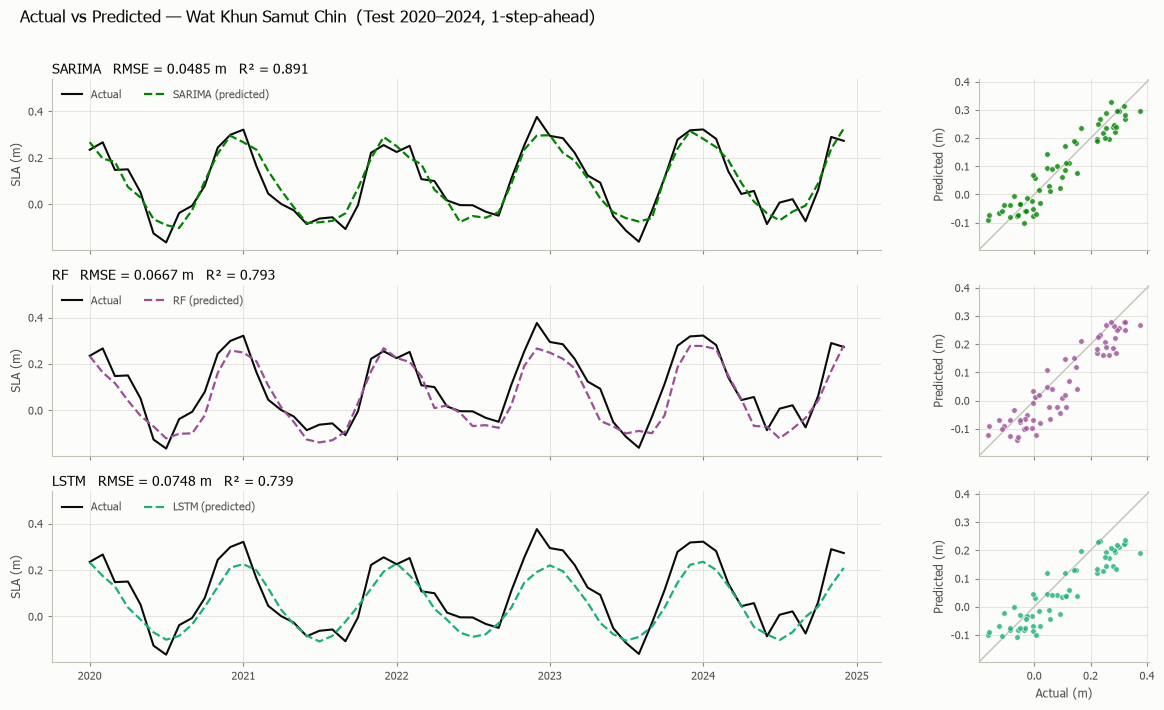

บันทึกรูป: final_actual_vs_pred_Laem_Chabang_Port.png


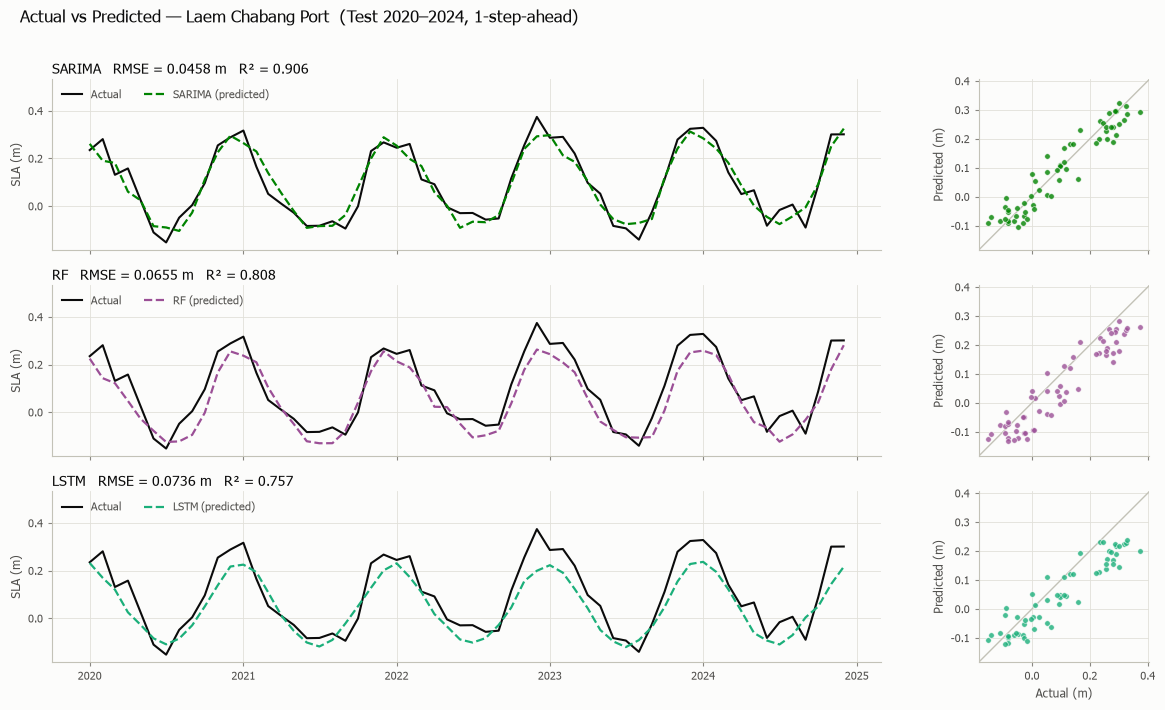

บันทึกรูป: final_actual_vs_pred_Upper_Gulf_Offshore.png


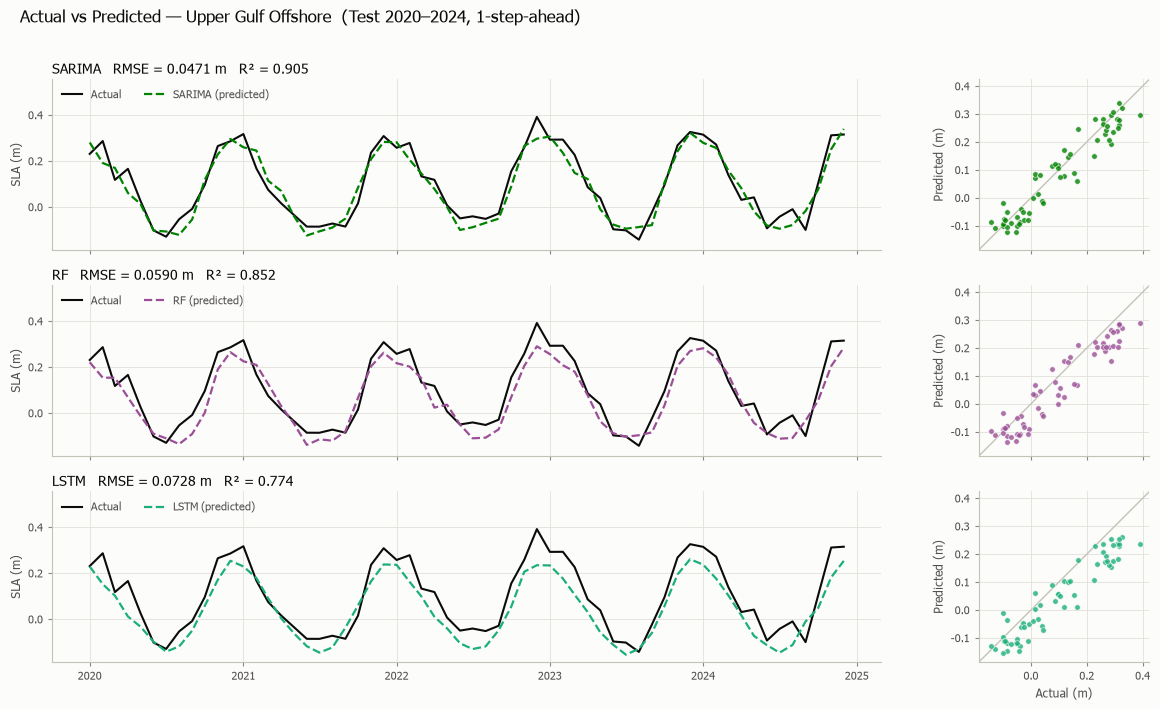

บันทึกรูป: final_actual_vs_pred_Phetchaburi_Bangkawe.png


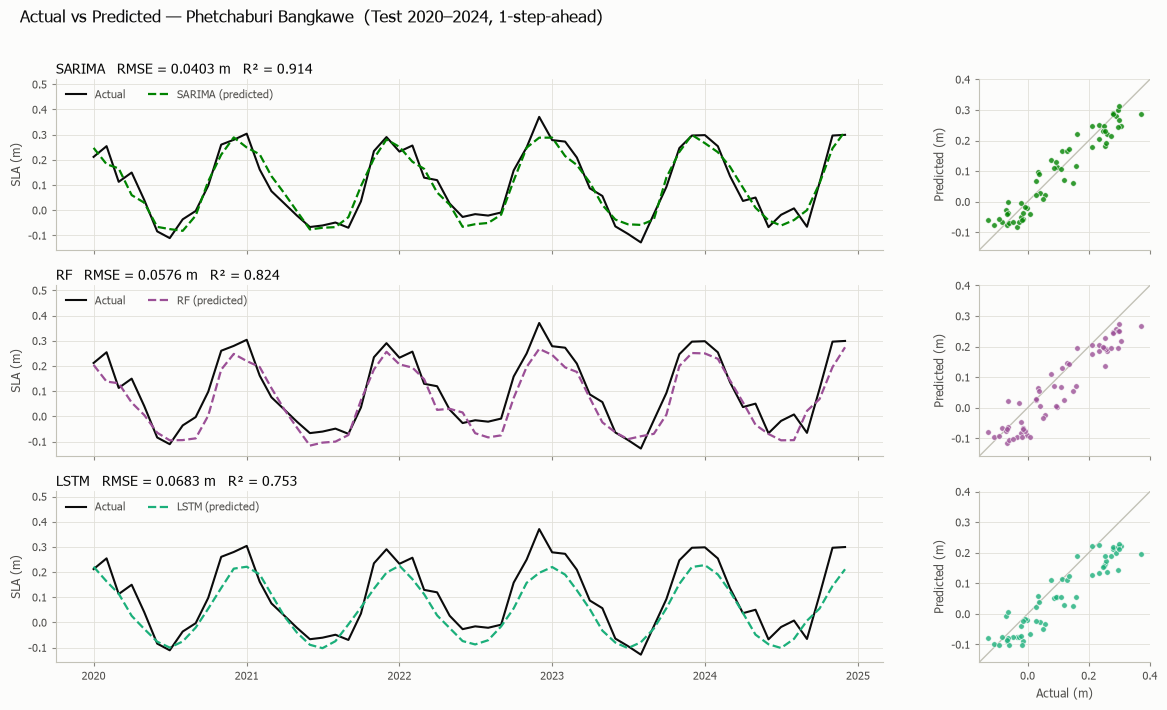

In [28]:
INK, SEC, MUTED = "#0b0b0b", "#52514e", "#898781"     # หมึกข้อความ 3 ระดับ
GRID, AXISC, SURF = "#e1e0d9", "#c3c2b7", "#fcfcfb"   # เส้นกริด/แกน/พื้น
MODEL_COLORS = {                                       # สีประจำโมเดล — คงที่ทุกรูปในเล่ม
    "SARIMA": "#008300",  # เขียว
    "RF":     "#9b4f96",  # ม่วงแดง (Okabe-Ito reddish purple ปรับเข้มให้เส้นชัดบนพื้นขาว)
    "LSTM":   "#1baf7a",  # เขียวน้ำทะเล
}


def _style_axis(ax):
    """โครงกราฟแบบ recessive: กริดจาง แกนบาง ตัวเลขสีรอง — ให้ข้อมูลเด่นกว่าโครง"""
    ax.set_facecolor(SURF)
    ax.grid(True, color=GRID, lw=0.6, zorder=0)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXISC)
        ax.spines[side].set_linewidth(0.8)
    ax.tick_params(colors=MUTED, labelsize=8, length=3)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_color(SEC)


def plot_actual_vs_pred(station: str, out: dict, save: bool = True):
    y, idx = out["y_test"], out["test_index"]
    models = [m for m in MODEL_COLORS if m in out["preds"]]
    n = len(models)

    fig, axes = plt.subplots(n, 2, figsize=(12.5, 2.4 * n), sharex="col",
                             gridspec_kw={"width_ratios": [2.5, 1]})
    fig.patch.set_facecolor(SURF)

    # ขอบเขตแกนร่วม (ให้ scatter ทุกแถวเทียบกันได้ตรงๆ)
    lo = min(y.min(), *(out["preds"][m].min() for m in models))
    hi = max(y.max(), *(out["preds"][m].max() for m in models))
    pad = 0.06 * (hi - lo)

    for r, m in enumerate(models):
        p, met, c = out["preds"][m], out["metrics"][m], MODEL_COLORS[m]

        # ซ้าย: อนุกรมเวลา
        ax = axes[r][0]
        _style_axis(ax)
        ax.plot(idx, y, color=INK, lw=1.5, label="Actual", zorder=3)
        ax.plot(idx, p, color=c, lw=1.6, ls="--", label=f"{m} (predicted)", zorder=4)
        ax.set_title(f"{m}   RMSE = {met['RMSE']:.4f} m   R² = {met['R2']:.3f}",
                     loc="left", fontsize=10, color=INK, pad=4)
        ax.set_ylabel("SLA (m)", fontsize=8.5, color=SEC)
        ax.legend(loc="upper left", fontsize=8, frameon=False, ncols=2,
                  handlelength=1.8, labelcolor=SEC)
        ax.set_ylim(lo - pad, hi + 0.30 * (hi - lo))   # เผื่อที่ให้ legend ด้านบน

        # ขวา: scatter Predicted vs Actual
        ax2 = axes[r][1]
        _style_axis(ax2)
        ax2.plot([lo - pad, hi + pad], [lo - pad, hi + pad],
                 color=AXISC, lw=1.0, zorder=2)                    # เส้น 1:1
        ax2.scatter(y, p, s=16, color=c, alpha=0.8,
                    edgecolors=SURF, linewidths=0.5, zorder=3)     # ขอบสีพื้น = spacer
        ax2.set_xlim(lo - pad, hi + pad)
        ax2.set_ylim(lo - pad, hi + pad)
        ax2.set_aspect("equal", adjustable="box")
        ax2.set_ylabel("Predicted (m)", fontsize=8.5, color=SEC)
        if r == n - 1:
            ax2.set_xlabel("Actual (m)", fontsize=8.5, color=SEC)

    axes[-1][0].set_xlabel("")   # แกนเวลาอ่านจาก tick ปีได้เลย
    fig.suptitle(f"Actual vs Predicted — {station}  (Test 2020–2024, 1-step-ahead)",
                 fontsize=12, color=INK, x=0.02, ha="left")
    fig.tight_layout(rect=[0, 0, 1, 0.97])

    if save:
        fname = f"final_actual_vs_pred_{station.replace(' ', '_')}.png"
        fig.savefig(os.path.join(CONFIG["output_dir"], fname),
                    dpi=300, bbox_inches="tight", facecolor=SURF)
        print(f"บันทึกรูป: {fname}")
    plt.show()


for _station, _out in final_out.items():
    plot_actual_vs_pred(_station, _out)

#  13.5 MODEL STRUCTURE  โครงสร้างแบบจำลองรายสถานี (SARIMA / RF / LSTM)

***รายงาน "โครงสร้างที่ถูกเลือกจริง" ของแต่ละสถานี ไม่ใช่ค่าที่ตั้งไว้ล่วงหน้า:***
***SARIMA : อันดับ (p,d,q)(P,D,Q)s + จำนวนพจน์ที่ต้องประมาณค่า***
***RF     : hyperparameters จาก grid search + ขนาดป่าที่โตขึ้นจริง (ความลึก/ใบ/โหนด)***
***LSTM   : ชั้นและรูปร่างข้อมูลนำเข้า + จำนวนพารามิเตอร์ที่เทรนได้***

***ต้องรันมาก่อน: 13.3 หรือ 13.3b (ใช้ final_out) และเซลล์ตั้งค่า/13.0/13.1/13.2***
***หมายเหตุ: RF ถูก refit ซ้ำในเซลล์นี้เพื่ออ่านโครงสร้างต้นไม้ ใช้ SEED และพารามิเตอร์***
            ***ชุดเดียวกับที่ 13.2 เลือกไว้ ผลจึงเป็นป่าต้นเดียวกันเป๊ะ ไม่ใช่การจูนใหม่***

In [29]:
import numpy as np
import pandas as pd

for _n in ["final_out", "CONFIG", "build_dataset", "split_3way", "TARGET_COL",
           "RF_FEATURE_COLS", "LSTM_FEATURE_COLS", "SEED"]:
    if _n not in globals():
        raise RuntimeError(f"ยังไม่มี {_n} — ให้รัน 13.3 หรือ 13.3b ก่อน")


def _as_tuple(v):
    """รับได้ทั้ง tuple (จาก 13.3) และ string '(1, 0, 2)' (จาก 13.3b)"""
    if isinstance(v, (tuple, list)):
        return tuple(int(x) for x in v)
    return tuple(int(x) for x in str(v).strip("()").split(","))


structure_records = []

for _st in CONFIG["stations"]:
    _ex = final_out[_st]["extra"]
    print("=" * 68)
    print(f"สถานี: {_st}")
    print("=" * 68)

    # ---------- SARIMA ----------
    _ord = _as_tuple(_ex["sarima_order"])
    _sord = _as_tuple(_ex["sarima_seasonal_order"])
    p, dd, q = _ord
    P, D, Q, s = _sord
    # พจน์ที่ optimizer ต้องประมาณค่า: AR + MA + SAR + SMA + sigma²
    _terms = ([f"ar.L{i}" for i in range(1, p + 1)]
              + [f"ma.L{i}" for i in range(1, q + 1)]
              + [f"ar.S.L{s*i}" for i in range(1, P + 1)]
              + [f"ma.S.L{s*i}" for i in range(1, Q + 1)]
              + ["sigma2"])
    _n_sarima_train = len(split_3way(build_sarima_series(_st))[0]) + \
                      len(split_3way(build_sarima_series(_st))[1])
    print(f"[SARIMA]  SARIMA{_ord}{_sord[:3]}[{s}]")
    print(f"   พจน์ที่ประมาณค่า  : {', '.join(_terms)}  ({len(_terms)} พารามิเตอร์)")
    print(f"   ข้อมูลนำเข้า      : อนุกรมตัวแปรเดียว (SLA) {_n_sarima_train} เดือน (Train+Val)")
    print(f"   differencing     : d = {dd} (ปกติ) | D = {D} (ฤดูกาล คาบ {s} เดือน)")

    # ---------- RANDOM FOREST ----------
    _rf_df = build_dataset(_st)
    _tr, _va, _te = split_3way(_rf_df[TARGET_COL])
    _n_tv = len(_tr) + len(_va)
    _X = _rf_df[RF_FEATURE_COLS].iloc[:_n_tv]
    _y = _rf_df[TARGET_COL].iloc[:_n_tv].to_numpy()
    _mf = _ex["rf_max_features"]
    _rf = RandomForestRegressor(n_estimators=_ex["rf_n_estimators"], max_features=_mf,
                                min_samples_leaf=_ex["rf_min_samples_leaf"],
                                random_state=SEED, n_jobs=-1).fit(_X, _y)
    _depths = np.array([t.get_depth() for t in _rf.estimators_])
    _leaves = np.array([t.get_n_leaves() for t in _rf.estimators_])
    _nodes = int(sum(t.tree_.node_count for t in _rf.estimators_))
    _k_split = rf_n_features_per_split(_mf, len(RF_FEATURE_COLS))
    print(f"\n[RF]      RandomForestRegressor(n_estimators={_ex['rf_n_estimators']}, "
          f"max_features={_mf!r}, min_samples_leaf={_ex['rf_min_samples_leaf']}, "
          f"random_state={SEED})")
    print(f"   ข้อมูลนำเข้า      : 2 มิติ ({_X.shape[0]} ตัวอย่าง x {_X.shape[1]} ตัวแปร)")
    print(f"   ตัวแปรต่อการแตกกิ่ง: {_k_split} จาก {len(RF_FEATURE_COLS)} ตัวแปร")
    print(f"   ขนาดป่าที่โตจริง  : {len(_rf.estimators_)} ต้น | "
          f"ความลึกเฉลี่ย {_depths.mean():.1f} (ต่ำสุด {_depths.min()} สูงสุด {_depths.max()}) | "
          f"ใบเฉลี่ย {_leaves.mean():.1f} ต้นละ | โหนดรวม {_nodes:,}")

    # ---------- LSTM ----------
    _lookback = CONFIG["lookback"]
    _n_feat = len(LSTM_FEATURE_COLS)
    _units, _drop, _rdrop = 64, 0.3, 0.2
    # จำนวนพารามิเตอร์ LSTM = 4 x [(features + units) x units + units]
    _p_lstm = 4 * ((_n_feat + _units) * _units + _units)
    _p_dense = _units + 1
    _n_seq_tv = EXPECTED_LSTM_SEQ[0] + EXPECTED_LSTM_SEQ[1]
    print(f"\n[LSTM]    Input({_lookback}, {_n_feat}) -> "
          f"LSTM({_units}, dropout={_drop}, recurrent_dropout={_rdrop}) -> Dense(1)")
    print(f"   ข้อมูลนำเข้า      : 3 มิติ ({_n_seq_tv} ลำดับ x {_lookback} timestep "
          f"x {_n_feat} ตัวแปร)")
    print(f"   พารามิเตอร์       : {_p_lstm + _p_dense:,} ตัว "
          f"(LSTM {_p_lstm:,} + Dense {_p_dense})")
    print(f"   epoch ที่ดีที่สุด   : {_ex.get('lstm_best_epoch', 'n/a')} "
          f"(optimizer Adam, loss MSE, batch 16, ไม่สลับลำดับข้อมูล)")
    print()

    structure_records.append({
        "Station": _st,
        "SARIMA_Order": f"SARIMA{_ord}{_sord[:3]}[{s}]",
        "SARIMA_N_Params": len(_terms),
        "SARIMA_Terms": ", ".join(_terms),
        "SARIMA_Input": f"1D univariate SLA, {_n_sarima_train} months",
        "RF_n_estimators": _ex["rf_n_estimators"],
        "RF_max_features": str(_mf),
        "RF_min_samples_leaf": _ex["rf_min_samples_leaf"],
        "RF_Features_Per_Split": _k_split,
        "RF_Input": f"2D {_X.shape[0]} x {_X.shape[1]}",
        "RF_Mean_Depth": round(float(_depths.mean()), 2),
        "RF_Max_Depth": int(_depths.max()),
        "RF_Mean_Leaves": round(float(_leaves.mean()), 1),
        "RF_Total_Nodes": _nodes,
        "LSTM_Architecture": f"Input({_lookback},{_n_feat}) -> LSTM({_units}) -> Dense(1)",
        "LSTM_Input": f"3D {_n_seq_tv} x {_lookback} x {_n_feat}",
        "LSTM_N_Params": _p_lstm + _p_dense,
        "LSTM_Best_Epoch": _ex.get("lstm_best_epoch", np.nan),
    })

model_structure_summary = pd.DataFrame(structure_records)

_struct_path = os.path.join(SARIMA_OUTPUT_DIR, "model_structure_by_station.csv")
model_structure_summary.to_csv(_struct_path, index=False, encoding="utf-8-sig")

print("=" * 68)
print("ตารางสรุปโครงสร้างแบบจำลองรายสถานี")
print("=" * 68)
display(model_structure_summary[["Station", "SARIMA_Order", "SARIMA_N_Params",
                                 "RF_n_estimators", "RF_max_features",
                                 "RF_min_samples_leaf", "RF_Mean_Depth",
                                 "LSTM_Architecture", "LSTM_N_Params"]])
print(f"\nบันทึก: {_struct_path}")


สถานี: Wat Khun Samut Chin
[SARIMA]  SARIMA(1, 0, 2)(0, 1, 1)[12]
   พจน์ที่ประมาณค่า  : ar.L1, ma.L1, ma.L2, ma.S.L12, sigma2  (5 พารามิเตอร์)
   ข้อมูลนำเข้า      : อนุกรมตัวแปรเดียว (SLA) 324 เดือน (Train+Val)
   differencing     : d = 0 (ปกติ) | D = 1 (ฤดูกาล คาบ 12 เดือน)

[RF]      RandomForestRegressor(n_estimators=200, max_features=0.5, min_samples_leaf=2, random_state=42)
   ข้อมูลนำเข้า      : 2 มิติ (311 ตัวอย่าง x 11 ตัวแปร)
   ตัวแปรต่อการแตกกิ่ง: 5 จาก 11 ตัวแปร
   ขนาดป่าที่โตจริง  : 200 ต้น | ความลึกเฉลี่ย 12.4 (ต่ำสุด 10 สูงสุด 17) | ใบเฉลี่ย 85.2 ต้นละ | โหนดรวม 33,864

[LSTM]    Input(12, 7) -> LSTM(64, dropout=0.3, recurrent_dropout=0.2) -> Dense(1)
   ข้อมูลนำเข้า      : 3 มิติ (312 ลำดับ x 12 timestep x 7 ตัวแปร)
   พารามิเตอร์       : 18,497 ตัว (LSTM 18,432 + Dense 65)
   epoch ที่ดีที่สุด   : 9 (optimizer Adam, loss MSE, batch 16, ไม่สลับลำดับข้อมูล)

สถานี: Laem Chabang Port
[SARIMA]  SARIMA(1, 0, 2)(0, 1, 1)[12]
   พจน์ที่ประมาณค่า  : ar.L1, ma.L1, ma.L2, ma.

,Station,SARIMA_Order,SARIMA_N_Params,RF_n_estimators,RF_max_features,RF_min_samples_leaf,RF_Mean_Depth,LSTM_Architecture,LSTM_N_Params
0,Wat Khun Samut Chin,"SARIMA(1, 0, 2)(0, 1, 1)[12]",5,200,0.5,2,12.39,"Input(12,7) -> LSTM(64) -> Dense(1)",18497
1,Laem Chabang Port,"SARIMA(1, 0, 2)(0, 1, 1)[12]",5,300,sqrt,1,15.48,"Input(12,7) -> LSTM(64) -> Dense(1)",18497
2,Upper Gulf Offshore,"SARIMA(1, 0, 0)(0, 1, 1)[12]",3,100,0.5,1,15.57,"Input(12,7) -> LSTM(64) -> Dense(1)",18497
3,Phetchaburi Bangkawe,"SARIMA(1, 0, 2)(0, 1, 1)[12]",5,200,0.5,1,15.25,"Input(12,7) -> LSTM(64) -> Dense(1)",18497



บันทึก: D:\defence_sla_WSL_backup\outputs_fair_comparison\separated_preprocessing\model_structure_by_station.csv


#  13.5b RF FEATURE IMPORTANCE — ความสำคัญของตัวแปรจาก Random Forest Regression

***ตอบคำถามว่า "RF ใช้ตัวแปรไหนตัดสินใจ" ด้วยหลักฐาน 2 ชุดที่มีจุดอ่อนคนละแบบ:***

***1. MDI (Mean Decrease in Impurity) — `rf.feature_importances_` วัดจากโครงสร้างต้นไม้ว่าตัวแปรนั้นช่วยลดความแปรปรวนตอนแตกกิ่งได้เท่าไร รวมทุกตัวแปรได้ 1.000 แต่เอนเอียงเข้าหาตัวแปรต่อเนื่องที่มีค่าหลากหลาย และเป็นค่าที่วัดบนข้อมูลที่ใช้เทรน***

***2. Permutation Importance — สุ่มสลับค่าของตัวแปรทีละตัว 30 รอบ แล้ววัดว่า RMSE แย่ลงกี่เมตร คิดบนชุด Test 2020–2024 ที่โมเดลไม่เคยเห็น ตีความง่ายเพราะมีหน่วยจริง แต่จะประเมินต่ำเมื่อตัวแปรสัมพันธ์กันเอง***

***เซลล์นี้เป็นแบบเพิ่มเติม (additive) ไม่แตะ `final_out` / `final_summary` และไม่เขียนทับไฟล์ผลลัพธ์เดิม — สร้าง RF ใหม่จาก hyperparameters ที่ grid search เลือกไว้ + `random_state=SEED` + Train+Val ชุดเดิม จึงได้ป่าต้นเดียวกับที่ใช้พยากรณ์ Test และมี guard ตรวจว่าค่าพยากรณ์ตรงกับที่บันทึกไว้ทุกหลัก***

***ข้อควรระวังในการตีความ: RF ใช้ SLA_hist กับ SLA_lag1/3/6/12 ซึ่งสัมพันธ์กันเองสูง ทั้งสองวิธีจะ "หารความดีความชอบ" กันเองในกลุ่มนี้ จึงต้องอ่านเป็นอันดับและอ่านตารางรวมตามกลุ่มตัวแปร (SLA history / ERA5 forcing / Seasonal) ประกอบด้วยเสมอ***

***ต้องรันมาก่อน: 13.1, 13.2, 13.3 (หรือ 13.3b) และ 13.4***

***ผลลัพธ์ที่เขียนลง `SARIMA_OUTPUT_DIR`: `rf_feature_importance_mdi.png`, `rf_feature_importance_permutation.png`, `rf_feature_importance_by_station.csv`, `rf_feature_importance_mean_4stations.csv`, `rf_feature_importance_mdi_wide.csv`, `rf_feature_importance_by_group.csv`***

In [ ]:
#  13.5b RF FEATURE IMPORTANCE — ความสำคัญของตัวแปรจาก Random Forest Regression
#
#  เซลล์นี้ "อ่านอย่างเดียว" ต่อผลการทดลอง: ไม่แตะ final_out / final_summary
#  และไม่เขียนทับไฟล์ผลลัพธ์เดิม — สร้าง RF ขึ้นใหม่ด้วย hyperparameters ชุดเดิม
#  (จาก grid search ใน 13.3 / 13.3b) + SEED เดิม + ข้อมูล Train+Val ชุดเดิม
#  ผลจึงเป็นป่าต้นเดียวกันทุกประการกับที่ใช้พยากรณ์ Test (RandomForest เป็น deterministic
#  เมื่อ random_state คงที่) วิธีเดียวกับเซลล์ 13.5 ที่รายงานโครงสร้างป่า
#  และมี guard ตรวจซ้ำว่าป่าที่ refit ทำนาย Test ได้ค่าเดิมกับที่บันทึกไว้
#
#  วัด 2 วิธี เพราะตอบคนละคำถามและมีจุดอ่อนคนละแบบ:
#
#    1) MDI (Mean Decrease in Impurity) — rf.feature_importances_
#       "ตัวแปรนี้ช่วยลดความแปรปรวนตอนแตกกิ่งได้เท่าไร" คิดจากโครงสร้างต้นไม้
#       ข้อดี: ได้จากโมเดลโดยตรง | ข้อเสีย: เอนเอียงเข้าหาตัวแปรต่อเนื่องที่มีค่าหลากหลาย
#       และเป็นค่าที่วัดบนข้อมูลที่ใช้เทรน (in-sample)
#
#    2) Permutation Importance — สุ่มสลับค่าของตัวแปรทีละตัวแล้วดูว่า RMSE แย่ลงเท่าไร
#       ข้อดี: วัดบนข้อมูลที่โมเดลไม่เคยเห็น (Test) และมีหน่วยจริง (เมตร) ตีความง่าย
#       ข้อเสีย: ถ้าตัวแปรสองตัวสัมพันธ์กันสูง สลับตัวเดียวโมเดลยังใช้อีกตัวแทนได้
#       ค่าที่ได้จึงต่ำกว่าความสำคัญที่แท้จริงของ "กลุ่ม" ตัวแปรนั้น
#
#  ข้อควรระวังในการตีความ (ควรเขียนกำกับไว้ในเล่ม): ฟีเจอร์ของ RF ชุดนี้มี SLA_hist กับ
#  SLA_lag1/3/6/12 ซึ่งสัมพันธ์กันเองสูงมาก ทั้ง MDI และ permutation จะ "หารความดีความชอบ"
#  กันเองภายในกลุ่ม จึงควรอ่านเป็นอันดับ (ranking) และอ่านรวมเป็นกลุ่มตัวแปร
#  มากกว่าจะอ่านค่าสัมบูรณ์ของตัวแปรเดี่ยว — ตารางรวมตามกลุ่มอยู่ในหัวข้อ 2 ของเซลล์นี้
#
#  หมายเหตุเรื่อง Test: permutation importance บน Test ใช้ "อธิบายผลหลังจบการทดลอง"
#  เท่านั้น ไม่ได้ย้อนกลับไปเลือกโมเดล/ฟีเจอร์/พารามิเตอร์ใด ๆ การเลือกทุกอย่าง
#  ยังตัดสินด้วย Validation RMSE เหมือนเดิม (จึงไม่ทำให้ Test รั่ว)
#
#  ต้องรันมาก่อน: 13.1, 13.2, 13.3 (หรือ 13.3b) และ 13.4 (สำหรับสี/สไตล์กราฟ)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

for _n in ["final_out", "CONFIG", "build_dataset", "split_3way", "TARGET_COL",
           "RF_FEATURE_COLS", "SEED", "SARIMA_OUTPUT_DIR",
           "MODEL_COLORS", "_style_axis"]:
    if _n not in globals():
        raise RuntimeError(f"ยังไม่มี {_n} — ให้รัน 13.1–13.3 (หรือ 13.3b) และ 13.4 ก่อน")

PERM_REPEATS = 30          # จำนวนครั้งที่สุ่มสลับค่าต่อ 1 ตัวแปร (ยิ่งมาก ยิ่งนิ่ง)

# ชื่อกำกับให้อ่านง่ายในกราฟ/ตาราง — ไม่เปลี่ยนชื่อคอลัมน์จริงใน dataset
FEATURE_LABELS = {
    "SLA_hist":  "SLA (t)",
    "SST":       "SST (t)",
    "SLP":       "SLP (t)",
    "u10":       "u10 (t)",
    "v10":       "v10 (t)",
    "SLA_lag1":  "SLA (t-1)",
    "SLA_lag3":  "SLA (t-3)",
    "SLA_lag6":  "SLA (t-6)",
    "SLA_lag12": "SLA (t-12)",
    "month_sin": "month_sin",
    "month_cos": "month_cos",
}

# กลุ่มตัวแปร — ใช้สรุปรวมความสำคัญของตัวแปรที่สัมพันธ์กันเอง
FEATURE_GROUPS = {
    "SLA_hist": "SLA history", "SLA_lag1": "SLA history",
    "SLA_lag3": "SLA history", "SLA_lag6": "SLA history",
    "SLA_lag12": "SLA history",
    "SST": "ERA5 forcing", "SLP": "ERA5 forcing",
    "u10": "ERA5 forcing", "v10": "ERA5 forcing",
    "month_sin": "Seasonal", "month_cos": "Seasonal",
}

_missing_label = [c for c in RF_FEATURE_COLS if c not in FEATURE_LABELS]
if _missing_label:
    raise RuntimeError(f"ยังไม่มีชื่อกำกับของฟีเจอร์: {_missing_label}")


# 1. คำนวณความสำคัญของตัวแปรทีละสถานี

importance_records = []
rf_models_for_importance = {}      # เก็บป่าไว้ให้เซลล์อื่นใช้ต่อได้ ไม่ต้อง fit ซ้ำ

for _st in CONFIG["stations"]:
    _ex = final_out[_st]["extra"]

    _rf_df = build_dataset(_st)
    _tr, _va, _te = split_3way(_rf_df[TARGET_COL])
    _n_tv = len(_tr) + len(_va)

    _X_tv = _rf_df[RF_FEATURE_COLS].iloc[:_n_tv]
    _y_tv = _rf_df[TARGET_COL].iloc[:_n_tv].to_numpy()
    _X_te = _rf_df[RF_FEATURE_COLS].iloc[_n_tv:]
    _y_te = _rf_df[TARGET_COL].iloc[_n_tv:].to_numpy()

    # refit ด้วยพารามิเตอร์เดิม + seed เดิม -> ป่าต้นเดียวกับที่ใช้พยากรณ์ Test
    _rf = RandomForestRegressor(n_estimators=_ex["rf_n_estimators"],
                                max_features=_ex["rf_max_features"],
                                min_samples_leaf=_ex["rf_min_samples_leaf"],
                                random_state=SEED, n_jobs=-1).fit(_X_tv, _y_tv)
    rf_models_for_importance[_st] = _rf

    # กันพลาด: ป่าที่ refit ต้องทำนาย Test ได้ค่าเดิมกับที่บันทึกไว้ใน final_out
    _pred_check = _rf.predict(_X_te)
    _pred_saved = np.asarray(final_out[_st]["preds"]["RF"], dtype=float)
    _dmax = float(np.max(np.abs(_pred_check - _pred_saved)))
    if _dmax > 1e-8:
        raise RuntimeError(
            f"{_st} [RF]: ป่าที่ refit ในเซลล์นี้ทำนายไม่ตรงกับผลใน final_out "
            f"(ต่างสูงสุด {_dmax:.3e}) — แปลว่าพารามิเตอร์หรือข้อมูลไม่ตรงกัน "
            "อย่าใช้ค่าความสำคัญจากรอบนี้")

    # ---------- (1) MDI ----------
    _mdi = _rf.feature_importances_
    # ส่วนเบี่ยงเบนระหว่างต้นไม้ — บอกว่าอันดับนิ่งแค่ไหนภายในป่าเดียวกัน
    _mdi_std = np.std([t.feature_importances_ for t in _rf.estimators_], axis=0)

    # ---------- (2) Permutation ----------
    # scoring = neg RMSE -> importance = RMSE(สลับแล้ว) - RMSE(เดิม)  หน่วยเป็นเมตร
    _perm_te = permutation_importance(
        _rf, _X_te, _y_te, scoring="neg_root_mean_squared_error",
        n_repeats=PERM_REPEATS, random_state=SEED, n_jobs=-1)
    _perm_tv = permutation_importance(
        _rf, _X_tv, _y_tv, scoring="neg_root_mean_squared_error",
        n_repeats=PERM_REPEATS, random_state=SEED, n_jobs=-1)

    for _j, _col in enumerate(RF_FEATURE_COLS):
        importance_records.append({
            "Station": _st,
            "Feature": _col,
            "Feature_Label": FEATURE_LABELS[_col],
            "Feature_Group": FEATURE_GROUPS.get(_col, "Other"),
            "MDI_Importance": float(_mdi[_j]),
            "MDI_Std_Across_Trees": float(_mdi_std[_j]),
            "Perm_Test_dRMSE_m": float(_perm_te.importances_mean[_j]),
            "Perm_Test_Std_m": float(_perm_te.importances_std[_j]),
            "Perm_TrainVal_dRMSE_m": float(_perm_tv.importances_mean[_j]),
            "Perm_TrainVal_Std_m": float(_perm_tv.importances_std[_j]),
            "RF_n_estimators": _ex["rf_n_estimators"],
            "RF_max_features": str(_ex["rf_max_features"]),
            "RF_min_samples_leaf": _ex["rf_min_samples_leaf"],
            "N_TrainVal": int(_X_tv.shape[0]),
            "N_Test": int(_X_te.shape[0]),
            "Perm_N_Repeats": PERM_REPEATS,
        })

rf_feature_importance = pd.DataFrame(importance_records)

# อันดับต่อสถานี (1 = สำคัญที่สุด) — ใส่ไว้ในไฟล์ให้อ้างอิงในเล่มได้ตรง ๆ
rf_feature_importance["MDI_Rank"] = (
    rf_feature_importance.groupby("Station")["MDI_Importance"]
    .rank(ascending=False, method="min").astype(int))
rf_feature_importance["Perm_Test_Rank"] = (
    rf_feature_importance.groupby("Station")["Perm_Test_dRMSE_m"]
    .rank(ascending=False, method="min").astype(int))

# กันพลาด: MDI ของแต่ละสถานีต้องรวมได้ 1
_mdi_sums = rf_feature_importance.groupby("Station")["MDI_Importance"].sum()
assert np.allclose(_mdi_sums.to_numpy(), 1.0, atol=1e-9), \
    f"MDI รวมแล้วไม่เท่ากับ 1: {_mdi_sums.to_dict()}"


# 2. ตารางสรุป — รายสถานี / ค่าเฉลี่ย 4 สถานี / รวมตามกลุ่มตัวแปร

rf_importance_wide = rf_feature_importance.pivot(
    index="Feature_Label", columns="Station", values="MDI_Importance")
rf_importance_wide = rf_importance_wide[list(CONFIG["stations"])]
rf_importance_wide["Mean_4_Stations"] = rf_importance_wide.mean(axis=1)
rf_importance_wide = rf_importance_wide.sort_values("Mean_4_Stations",
                                                    ascending=False)

rf_importance_mean = (
    rf_feature_importance
    .groupby(["Feature", "Feature_Label", "Feature_Group"], as_index=False)
    .agg(MDI_Mean=("MDI_Importance", "mean"),
         MDI_Std_Across_Stations=("MDI_Importance", "std"),
         Perm_Test_Mean_dRMSE_m=("Perm_Test_dRMSE_m", "mean"),
         Perm_Test_Std_Across_Stations=("Perm_Test_dRMSE_m", "std"))
    .sort_values("MDI_Mean", ascending=False)
    .reset_index(drop=True))

rf_importance_by_group = (
    rf_feature_importance
    .groupby(["Station", "Feature_Group"], as_index=False)
    .agg(MDI_Sum=("MDI_Importance", "sum"))
    .pivot(index="Feature_Group", columns="Station", values="MDI_Sum"))
rf_importance_by_group = rf_importance_by_group[list(CONFIG["stations"])]
rf_importance_by_group["Mean_4_Stations"] = rf_importance_by_group.mean(axis=1)
rf_importance_by_group = rf_importance_by_group.sort_values("Mean_4_Stations",
                                                            ascending=False)

print("=" * 78)
print("RF FEATURE IMPORTANCE — MDI รายสถานี (สัดส่วน รวมทุกตัวแปรได้ 1.000)")
print("=" * 78)
display(rf_importance_wide.round(4))

print("\n" + "=" * 78)
print("ค่าเฉลี่ย 4 สถานี — MDI เทียบกับ Permutation (Test, หน่วยเมตรของ RMSE ที่แย่ลง)")
print("=" * 78)
display(rf_importance_mean.round(4))

print("\n" + "=" * 78)
print("รวมตามกลุ่มตัวแปร (MDI) — อ่านคู่กันเพื่อเลี่ยงปัญหาตัวแปรสัมพันธ์กันเอง")
print("=" * 78)
display(rf_importance_by_group.round(4))

# จำนวนตัวแปรที่รวมกันได้ >= 80% ของ MDI ต่อสถานี
print("\nจำนวนตัวแปรที่อธิบาย 80% แรกของ MDI:")
for _st in CONFIG["stations"]:
    _s = (rf_feature_importance.loc[rf_feature_importance["Station"] == _st]
          .sort_values("MDI_Importance", ascending=False))
    _cum = _s["MDI_Importance"].cumsum().to_numpy()
    _k = int(np.searchsorted(_cum, 0.80) + 1)
    _top = ", ".join(_s["Feature_Label"].head(_k))
    print(f"   {_st:26s} : {_k} ตัวจาก {len(RF_FEATURE_COLS)}  ({_top})")


# 3. กราฟ — แท่งแนวนอนเรียงจากมากไปน้อย สถานีละพาเนล
#    ซีรีส์เดียวต่อพาเนล จึงใช้สีประจำ RF สีเดียวจาก MODEL_COLORS (ไม่ต้องมี legend)
#    แถบคลาดเคลื่อน = ส่วนเบี่ยงเบนมาตรฐาน (ระหว่างต้นไม้ / ระหว่างรอบสุ่มสลับ)

def plot_rf_importance(value_col: str, err_col: str, xlabel: str,
                       suptitle: str, fname: str, fmt: str = "{:.3f}"):
    fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.6))
    fig.patch.set_facecolor(SURF)

    # แกน x ร่วมทุกพาเนล — เทียบข้ามสถานีได้ตรง ๆ ไม่ถูกสเกลต่อพาเนลหลอกตา
    _xmax = float((rf_feature_importance[value_col]
                   + rf_feature_importance[err_col]).max())
    _xmin = float((rf_feature_importance[value_col]
                   - rf_feature_importance[err_col]).min())
    _lim_hi = _xmax * 1.20 if _xmax > 0 else 1.0
    _lim_lo = min(0.0, _xmin * 1.10)

    for _ax, _st in zip(axes.ravel(), CONFIG["stations"]):
        _style_axis(_ax)
        _ax.grid(False)
        _ax.grid(True, axis="x", color=GRID, lw=0.6, zorder=0)

        _s = (rf_feature_importance.loc[rf_feature_importance["Station"] == _st]
              .sort_values(value_col, ascending=True))   # barh วาดจากล่างขึ้นบน
        _pos = np.arange(len(_s))

        _ax.barh(_pos, _s[value_col], height=0.62,
                 color=MODEL_COLORS["RF"], zorder=3,
                 xerr=_s[err_col],
                 error_kw=dict(ecolor=MUTED, elinewidth=0.8, capsize=2, zorder=4))
        _ax.set_yticks(_pos)
        _ax.set_yticklabels(_s["Feature_Label"], fontsize=8.5, color=SEC)
        _ax.set_xlim(_lim_lo, _lim_hi)
        _ax.axvline(0, color=AXISC, lw=0.8, zorder=2)

        # ป้ายค่าท้ายแท่ง — เทียบอันดับได้จากกราฟ ตัวเลขละเอียดอ่านจากตาราง/CSV
        # ค่าติดลบ (permutation ที่สลับแล้วบังเอิญดีขึ้น = ตัวแปรไม่มีประโยชน์)
        # วางป้ายที่ฝั่งขวาของเส้นศูนย์เสมอ ไม่ให้ทับแกน
        for _y, (_v, _e) in enumerate(zip(_s[value_col], _s[err_col])):
            _ax.text(max(_v + _e, 0.0) + _lim_hi * 0.015, _y, fmt.format(_v),
                     va="center", ha="left", fontsize=7.2, color=SEC)

        _ax.set_title(_st, loc="left", fontsize=10, color=INK, pad=4)
        _ax.set_xlabel(xlabel, fontsize=8.5, color=SEC)

    fig.suptitle(suptitle, fontsize=12, color=INK, x=0.02, ha="left")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    _path = os.path.join(SARIMA_OUTPUT_DIR, fname)
    fig.savefig(_path, dpi=300, bbox_inches="tight", facecolor=SURF)
    plt.show()
    print(f"บันทึกรูป: {_path}")


os.makedirs(SARIMA_OUTPUT_DIR, exist_ok=True)

plot_rf_importance(
    value_col="MDI_Importance", err_col="MDI_Std_Across_Trees",
    xlabel="Mean decrease in impurity (สัดส่วน)",
    suptitle="Random Forest — ความสำคัญของตัวแปรแบบ MDI (fit บน Train+Val)",
    fname="rf_feature_importance_mdi.png", fmt="{:.3f}")

plot_rf_importance(
    value_col="Perm_Test_dRMSE_m", err_col="Perm_Test_Std_m",
    xlabel="RMSE ที่เพิ่มขึ้นเมื่อสุ่มสลับตัวแปร (m)",
    suptitle=f"Random Forest — Permutation importance บนชุด Test 2020–2024 "
             f"({PERM_REPEATS} รอบต่อตัวแปร)",
    fname="rf_feature_importance_permutation.png", fmt="{:.4f}")


# 4. บันทึกไฟล์ (เขียนเฉพาะไฟล์ของเซลล์นี้ ไม่ทับไฟล์ผลลัพธ์เดิม)

_imp_files = {
    "rf_feature_importance_by_station.csv": rf_feature_importance,
    "rf_feature_importance_mean_4stations.csv": rf_importance_mean,
    "rf_feature_importance_mdi_wide.csv": rf_importance_wide.reset_index(),
    "rf_feature_importance_by_group.csv": rf_importance_by_group.reset_index(),
}
print()
for _fn, _df in _imp_files.items():
    _p = os.path.join(SARIMA_OUTPUT_DIR, _fn)
    _df.to_csv(_p, index=False, encoding="utf-8-sig")
    print(f"บันทึก: {_fn:44s} {len(_df):4d} แถว  ->  {_p}")

#  13.6 LEARNING CURVES — กราฟการเรียนรู้
#
#  งานนี้เป็น regression จึงไม่มี accuracy curve" วัดด้วย loss/RMSE เท่านั้น
#  และแต่ละแบบจำลองเรียนรู้คนละแบบ กราฟจึงต้องคนละชนิด:
#
#    LSTM   : เทรนเป็นรอบ (epoch) -> learning curve แท้ ๆ (train loss vs val loss)
#    RF     : ไม่มี epoch แต่ error ลู่เข้าเมื่อเพิ่มจำนวนต้นไม้
#             -> เส้นลู่เข้า Validation RMSE vs n_estimators (จากผล grid search จริง)
#    SARIMA : ประมาณค่าพารามิเตอร์ด้วย MLE ครั้งเดียว ไม่มีเส้นการเรียนรู้รายรอบ
#
#  ส่วน LSTM ต้องเทรนขั้นที่ 1 ซ้ำเพื่ออ่านค่า loss รายรอบ (Keras ไม่ได้เก็บไว้)
#      ใช้ SEED และโครงสร้างเดียวกับ 13.2 ทุกประการ และ **ไม่เขียนทับไฟล์ผลลัพธ์ใด ๆ**
#      ไม่แตะ preds/metrics — โค้ดตรวจให้ด้วยว่า best_epoch ที่ได้ตรงกับที่บันทึกไว้เดิม

กำลังเก็บ loss รายรอบของ LSTM (ไม่กระทบผลลัพธ์ที่บันทึกไว้)...
   Wat Khun Samut Chin    best_epoch =   9 | รันไป  24 รอบ | ตรงกับที่บันทึกไว้
   Laem Chabang Port      best_epoch =   8 | รันไป  23 รอบ | ตรงกับที่บันทึกไว้
   Upper Gulf Offshore    best_epoch =  29 | รันไป  44 รอบ | ตรงกับที่บันทึกไว้
   Phetchaburi Bangkawe   best_epoch =   8 | รันไป  23 รอบ | ตรงกับที่บันทึกไว้


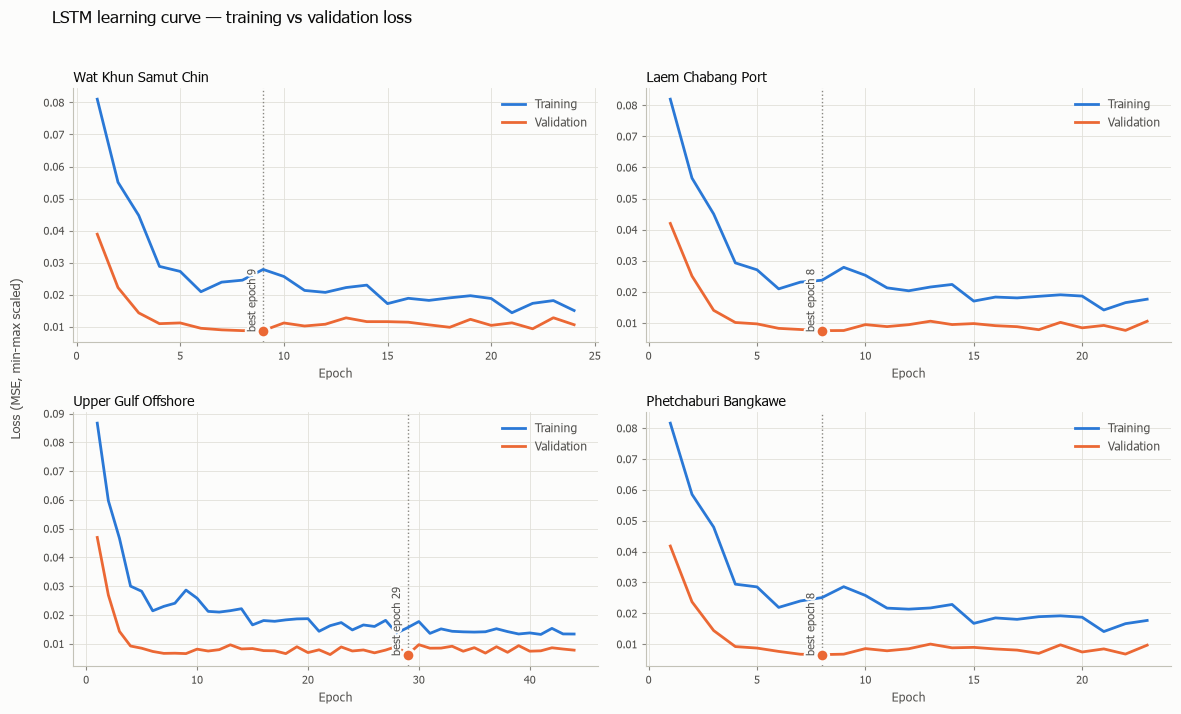

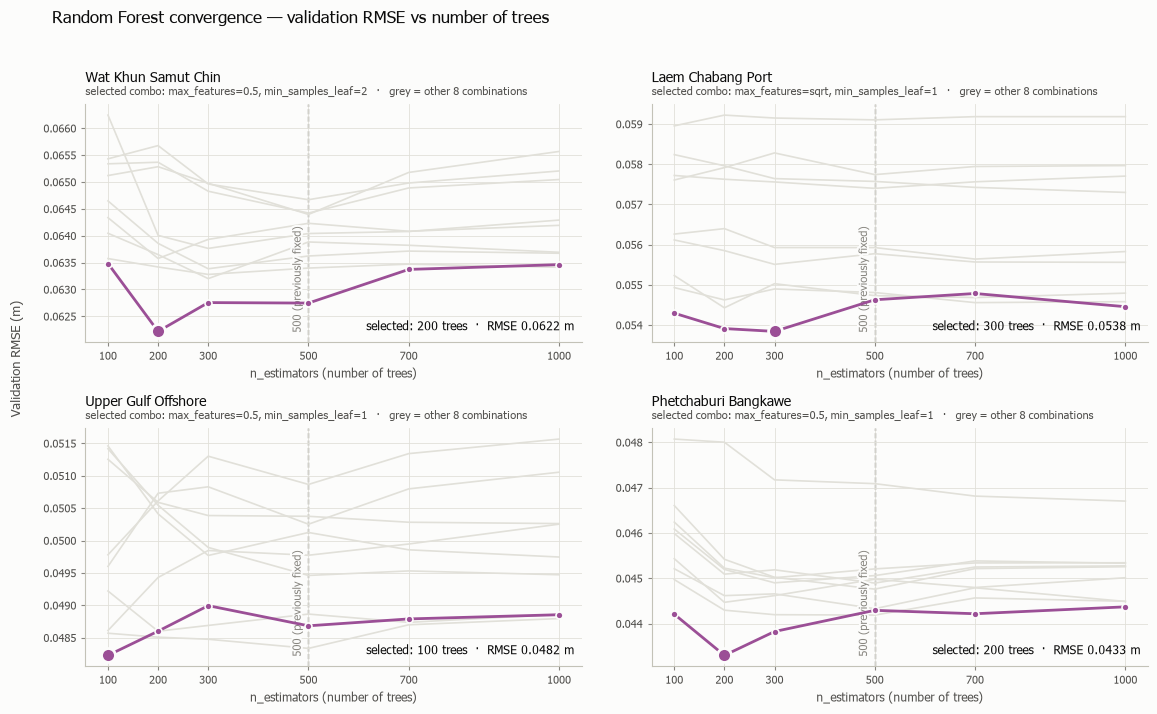


ตารางค่าตัวเลขประกอบกราฟ


,Station,LSTM_Epochs_Ran,LSTM_Best_Epoch,LSTM_Train_Loss_At_Best,LSTM_Val_Loss_At_Best,RF_Selected_Trees,RF_Val_RMSE_Selected,RF_Val_RMSE_At_500,RF_Gain_vs_500
0,Wat Khun Samut Chin,24,9,0.027864,0.008754,200,0.062220,0.062747,0.000527
1,Laem Chabang Port,23,8,0.023725,0.007521,300,0.053843,0.054630,0.000787
2,Upper Gulf Offshore,44,29,0.015605,0.006202,100,0.048228,0.048684,0.000456
3,Phetchaburi Bangkawe,23,8,0.025096,0.006602,200,0.043300,0.044294,0.000994



บันทึกกราฟ: D:\defence_sla_WSL_backup\outputs_fair_comparison\learning_curve_lstm.png
           D:\defence_sla_WSL_backup\outputs_fair_comparison\learning_curve_rf_convergence.png
บันทึกตาราง: D:\defence_sla_WSL_backup\outputs_fair_comparison\separated_preprocessing\learning_curve_summary.csv


In [30]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
import pandas as pd

if not HAS_TF_F:
    raise RuntimeError("ไม่พบ tensorflow — วาดกราฟการเรียนรู้ของ LSTM ไม่ได้")

# สีซีรีส์ — ผ่าน palette validator แล้ว (CVD ΔE 24.7, normal-vision ΔE 33.6, contrast >= 3:1)
C_TRAIN, C_VAL = "#2a78d6", "#eb6834"      # ฟ้า / ส้ม  (คนละคู่กับ MODEL_COLORS จึงไม่สับสน)
# ขอบสีพื้นรอบตัวอักษร — ให้ป้ายแนวตั้งอ่านออกแม้พาดทับเส้นกราฟ
_HALO = [pe.withStroke(linewidth=3, foreground=SURF)]
C_RF = MODEL_COLORS["RF"]                   # ม่วงแดง — สีประจำ RF เดิมของเล่ม
STATIONS = list(CONFIG["stations"])


# 1. LSTM  เก็บ loss รายรอบด้วยการเทรนขั้นที่ 1 ซ้ำ

def lstm_history(df_st, n_train, n_trainval, seed=SEED):
    """คืน (history, best_epoch) ของการเทรนขั้นที่ 1 — ไม่ทำนาย Test ไม่บันทึกไฟล์"""
    lookback = CONFIG["lookback"]
    tf.keras.utils.set_random_seed(seed)
    tgt = np.arange(lookback - 1, len(df_st))
    m_tr = tgt < n_train
    m_va = (tgt >= n_train) & (tgt < n_trainval)
    sc_x = MinMaxScaler().fit(df_st[LSTM_FEATURE_COLS].iloc[:n_train])
    sc_y = MinMaxScaler().fit(df_st[[TARGET_COL]].iloc[:n_train])
    Xs, ys = create_sequences(sc_x.transform(df_st[LSTM_FEATURE_COLS]),
                              sc_y.transform(df_st[[TARGET_COL]]), lookback)
    model = build_lstm_final((lookback, len(LSTM_FEATURE_COLS)), seed)
    es = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
    h = model.fit(Xs[m_tr], ys[m_tr], validation_data=(Xs[m_va], ys[m_va]),
                  shuffle=False, epochs=200, batch_size=16, callbacks=[es], verbose=0)
    return h.history, int(np.argmin(h.history["val_loss"])) + 1


print("กำลังเก็บ loss รายรอบของ LSTM (ไม่กระทบผลลัพธ์ที่บันทึกไว้)...")
lstm_curves = {}
for _st in STATIONS:
    _df = build_lstm_dataset(_st)
    _tr, _va, _te = split_3way(_df[TARGET_COL])
    _hist, _be = lstm_history(_df, len(_tr), len(_tr) + len(_va), SEED)
    _rec = final_out[_st]["extra"].get("lstm_best_epoch")
    _ok = "ตรงกับที่บันทึกไว้" if _rec == _be else f"ไม่ตรง! (บันทึกไว้ {_rec})"
    print(f"   {_st:22s} best_epoch = {_be:3d} | รันไป {len(_hist['loss']):3d} รอบ | {_ok}")
    lstm_curves[_st] = {"hist": _hist, "best_epoch": _be}



# 2. RF  เส้นลู่เข้าจากผล grid search

if "rf_grid_results" in globals():
    _grid = rf_grid_results.copy()
else:                                  # ยังไม่ได้รัน 13.3/13.3b ในรอบนี้ -> อ่านจากไฟล์
    _grid = pd.read_csv(os.path.join(SARIMA_OUTPUT_DIR,
                                     "rf_gridsearch_all_combinations.csv"),
                        encoding="utf-8-sig")
_grid["max_features"] = _grid["max_features"].astype(str)



# 3. วาดกราฟ  small multiples

def _panel_grid(title, ylabel):
    fig, axes = plt.subplots(2, 2, figsize=(12, 7.2))
    fig.patch.set_facecolor(SURF)
    fig.suptitle(title, x=0.055, ha="left", fontsize=12.5, color=INK, y=0.985)
    fig.supylabel(ylabel, fontsize=9, color=SEC)
    return fig, axes.ravel()


# 3a. LSTM learning curve
fig, axs = _panel_grid("LSTM learning curve — training vs validation loss",
                       "Loss (MSE, min-max scaled)")
for ax, _st in zip(axs, STATIONS):
    _style_axis(ax)
    h, be = lstm_curves[_st]["hist"], lstm_curves[_st]["best_epoch"]
    ep = np.arange(1, len(h["loss"]) + 1)
    ax.plot(ep, h["loss"], color=C_TRAIN, lw=2, label="Training", zorder=3)
    ax.plot(ep, h["val_loss"], color=C_VAL, lw=2, label="Validation", zorder=4)
    # จุดที่ถูกเลือก — marker >= 8px พร้อมวงแหวนสีพื้นกันทับเส้น
    ax.plot(be, h["val_loss"][be - 1], "o", ms=9, color=C_VAL,
            mec=SURF, mew=2, zorder=6)
    ax.axvline(be, color=MUTED, lw=1, ls=":", zorder=2)
    # ป้ายกำกับเส้นอ้างอิงวางแนวตั้งชิดเส้น — กันชนกับเส้นกราฟและกล่อง legend
    ax.annotate(f"best epoch {be}", xy=(be, 0.04), xycoords=("data", "axes fraction"),
                xytext=(-4, 0), textcoords="offset points", rotation=90,
                fontsize=8, color=SEC, ha="right", va="bottom", zorder=7,
                path_effects=_HALO)
    ax.set_title(_st, loc="left", fontsize=10, color=INK, pad=4)
    ax.set_xlabel("Epoch", fontsize=8.5, color=SEC)
    ax.legend(loc="upper right", fontsize=8.5, frameon=False, labelcolor=SEC)
fig.tight_layout(rect=[0.012, 0, 1, 0.965])
_p1 = os.path.join(CONFIG["output_dir"], "learning_curve_lstm.png")
fig.savefig(_p1, dpi=200, facecolor=SURF, bbox_inches="tight")
plt.show()

#  3b. RFR convergence curve
fig, axs = _panel_grid("Random Forest convergence — validation RMSE vs number of trees",
                       "Validation RMSE (m)")
for ax, _st in zip(axs, STATIONS):
    _style_axis(ax)
    g = _grid[_grid["Station"] == _st]
    best = g.sort_values("Validation_RMSE").iloc[0]
    # เส้นจาง = ทุกคู่ (max_features, min_samples_leaf) อีก 8 แบบ เป็นฉากหลังให้เห็นการกระจาย
    for (_mf, _ml), sub in g.groupby(["max_features", "min_samples_leaf"]):
        sub = sub.sort_values("n_estimators")
        is_best = (_mf == best["max_features"]) and (_ml == best["min_samples_leaf"])
        if is_best:
            continue
        ax.plot(sub["n_estimators"], sub["Validation_RMSE"],
                color=GRID, lw=1.2, zorder=2)
    sub = g[(g["max_features"] == best["max_features"]) &
            (g["min_samples_leaf"] == best["min_samples_leaf"])].sort_values("n_estimators")
    ax.plot(sub["n_estimators"], sub["Validation_RMSE"], color=C_RF, lw=2,
            marker="o", ms=5, mec=SURF, mew=1.2, zorder=4)
    # จำนวนต้นไม้ที่ถูกเลือกจริง
    ax.plot(best["n_estimators"], best["Validation_RMSE"], "o", ms=10,
            color=C_RF, mec=SURF, mew=2, zorder=6)
    # วางไว้มุมขวาล่างซึ่งว่างทุกแผง — จุดวงกลมใหญ่ทำหน้าที่ชี้ตำแหน่งอยู่แล้ว
    ax.annotate(f"selected: {int(best['n_estimators'])} trees  ·  RMSE {best['Validation_RMSE']:.4f} m",
                xy=(0.985, 0.04), xycoords="axes fraction",
                ha="right", va="bottom", fontsize=8.5, color=INK, zorder=7)
    # เส้นอ้างอิงที่ 500 ต้น = ค่าที่การทดลองเดิมล็อกไว้
    ax.axvline(500, color=MUTED, lw=1, ls="--", zorder=1)
    ax.annotate("500 (previously fixed)", xy=(500, 0.04),
                xycoords=("data", "axes fraction"),
                xytext=(-4, 0), textcoords="offset points", rotation=90,
                fontsize=8, color=MUTED, ha="right", va="bottom", zorder=3,
                path_effects=_HALO)
    ax.set_title(_st, loc="left", fontsize=10, color=INK, pad=16)
    # ระบุตัวตนของเส้นด้วยบรรทัดใต้หัวเรื่อง แทนกล่อง legend (ข้อความยาวจนทับกราฟ)
    _n_other = g.groupby(["max_features", "min_samples_leaf"]).ngroups - 1
    ax.annotate(f"selected combo: max_features={best['max_features']}, "
                f"min_samples_leaf={int(best['min_samples_leaf'])}"
                f"   ·   grey = other {_n_other} combinations",
                xy=(0, 1), xycoords="axes fraction", xytext=(0, 5),
                textcoords="offset points", fontsize=8, color=SEC, va="bottom")
    ax.set_xlabel("n_estimators (number of trees)", fontsize=8.5, color=SEC)
    ax.set_xticks(RF_N_ESTIMATORS_GRID)
fig.tight_layout(rect=[0.012, 0, 1, 0.965])
_p2 = os.path.join(CONFIG["output_dir"], "learning_curve_rf_convergence.png")
fig.savefig(_p2, dpi=200, facecolor=SURF, bbox_inches="tight")
plt.show()


# 4. ตารางค่าตัวเลขคู่กราฟ (relief rule: มีตารางให้อ่านแทนการดูสีอย่างเดียว)

_rows = []
for _st in STATIONS:
    h = lstm_curves[_st]["hist"]
    be = lstm_curves[_st]["best_epoch"]
    g = _grid[_grid["Station"] == _st].sort_values("Validation_RMSE")
    b = g.iloc[0]
    _sub = _grid[(_grid["Station"] == _st) &
                 (_grid["max_features"] == b["max_features"]) &
                 (_grid["min_samples_leaf"] == b["min_samples_leaf"])]
    _at500 = _sub[_sub["n_estimators"] == 500]["Validation_RMSE"]
    _rows.append({
        "Station": _st,
        "LSTM_Epochs_Ran": len(h["loss"]),
        "LSTM_Best_Epoch": be,
        "LSTM_Train_Loss_At_Best": round(float(h["loss"][be - 1]), 6),
        "LSTM_Val_Loss_At_Best": round(float(h["val_loss"][be - 1]), 6),
        "RF_Selected_Trees": int(b["n_estimators"]),
        "RF_Val_RMSE_Selected": round(float(b["Validation_RMSE"]), 6),
        "RF_Val_RMSE_At_500": round(float(_at500.iloc[0]), 6) if len(_at500) else np.nan,
    })
learning_curve_summary = pd.DataFrame(_rows)
learning_curve_summary["RF_Gain_vs_500"] = (
    learning_curve_summary["RF_Val_RMSE_At_500"]
    - learning_curve_summary["RF_Val_RMSE_Selected"]).round(6)

_p3 = os.path.join(SARIMA_OUTPUT_DIR, "learning_curve_summary.csv")
learning_curve_summary.to_csv(_p3, index=False, encoding="utf-8-sig")

print("\nตารางค่าตัวเลขประกอบกราฟ")
display(learning_curve_summary)
print(f"\nบันทึกกราฟ: {_p1}")
print(f"           {_p2}")
print(f"บันทึกตาราง: {_p3}")


- **ตรวจสอบมิติข้อมูลของ Random Forest และ LSTM**
- **Random Forest = 2D input (samples × features)**
- **LSTM          = 3D sequence input (samples × lookback × features) จาก build_lstm_dataset()**

In [33]:
station_check = "Wat Khun Samut Chin"

# Random Forest — ข้อมูลแบบ 2D (build_dataset)


df_rf_check = build_dataset(station_check)
tr_check, va_check, te_check = split_3way(df_rf_check[TARGET_COL])

n_train_check = len(tr_check)
n_trainval_check = len(tr_check) + len(va_check)

print("สถานี:", station_check)
print(f"RF   dataset {len(df_rf_check)} แถว "
      f"({df_rf_check.index.min():%Y-%m}..{df_rf_check.index.max():%Y-%m}) | "
      f"Train = {len(tr_check)}, Validation = {len(va_check)}, Test = {len(te_check)}")

Xrf_tr_check = df_rf_check[RF_FEATURE_COLS].iloc[:n_train_check]
Xrf_va_check = df_rf_check[RF_FEATURE_COLS].iloc[
    n_train_check:n_trainval_check
]
Xrf_te_check = df_rf_check[RF_FEATURE_COLS].iloc[
    n_trainval_check:
]


# LSTM — ข้อมูลแบบ 3D (build_lstm_dataset)


df_lstm_check = build_lstm_dataset(station_check)
ls_tr_check, ls_va_check, ls_te_check = split_3way(df_lstm_check[TARGET_COL])

n_train_lstm_check = len(ls_tr_check)
n_trainval_lstm_check = len(ls_tr_check) + len(ls_va_check)

print(f"LSTM dataset {len(df_lstm_check)} แถว "
      f"({df_lstm_check.index.min():%Y-%m}..{df_lstm_check.index.max():%Y-%m}) | "
      f"rows Train = {n_train_lstm_check}, Validation = {len(ls_va_check)}, "
      f"Test = {len(ls_te_check)}")

lookback_check = CONFIG["lookback"]

X_lstm_all, y_lstm_all = create_sequences(
    df_lstm_check[LSTM_FEATURE_COLS].to_numpy(),
    df_lstm_check[[TARGET_COL]].to_numpy(),
    lookback_check
)

# ตำแหน่งเป้าหมายของแต่ละ sequence
target_positions = np.arange(
    lookback_check - 1,
    len(df_lstm_check)
)

mask_lstm_train = target_positions < n_train_lstm_check
mask_lstm_val = (
    (target_positions >= n_train_lstm_check)
    & (target_positions < n_trainval_lstm_check)
)
mask_lstm_test = target_positions >= n_trainval_lstm_check

Xlstm_tr_check = X_lstm_all[mask_lstm_train]
Xlstm_va_check = X_lstm_all[mask_lstm_val]
Xlstm_te_check = X_lstm_all[mask_lstm_test]

seq_target_index = df_lstm_check.index[target_positions]


# แสดงผล


print("\n Random Forest (2D)")
print("Train shape :", Xrf_tr_check.shape)
print("Validation  :", Xrf_va_check.shape)
print("Test shape  :", Xrf_te_check.shape)
print("จำนวนมิติ   :", Xrf_tr_check.ndim)
print("First target:", f"{df_rf_check.index[0]:%Y-%m}")

print("\n LSTM (3D sequence)")
print("Train shape :", Xlstm_tr_check.shape)
print("Validation  :", Xlstm_va_check.shape)
print("Test shape  :", Xlstm_te_check.shape)
print("จำนวนมิติ   :", Xlstm_tr_check.ndim)
print("First target:", f"{seq_target_index[0]:%Y-%m}")


# ตรวจสอบความถูกต้อง


assert Xrf_tr_check.ndim == 2, "RF ต้องรับข้อมูลแบบ 2D"
assert Xlstm_tr_check.ndim == 3, "LSTM ต้องรับข้อมูลแบบ 3D"

assert Xrf_tr_check.shape[1] == len(RF_FEATURE_COLS)

assert Xlstm_tr_check.shape[1] == lookback_check
assert Xlstm_tr_check.shape[2] == len(LSTM_FEATURE_COLS)

# จำนวน sequence ของ LSTM ต้องตรงกับที่ validation gate คาดไว้
assert (Xlstm_tr_check.shape[0], Xlstm_va_check.shape[0], Xlstm_te_check.shape[0]) \
    == EXPECTED_LSTM_SEQ, "จำนวน sequence ของ LSTM ไม่ตรงกับที่คาดหวัง"

print("\nตรวจสอบผ่าน: รูปแบบมิติข้อมูลถูกต้องทั้ง Random Forest และ LSTM")
print(f"  RF   {Xrf_tr_check.shape[1]} features (มี SLA_lag1/3/6/12)")
print(f"  LSTM {Xlstm_tr_check.shape[2]} features x {lookback_check} timesteps "
      f"(ไม่มี lag column)")

สถานี: Wat Khun Samut Chin
RF   dataset 371 แถว (1994-02..2024-12) | Train = 275, Validation = 36, Test = 60
LSTM dataset 383 แถว (1993-02..2024-12) | rows Train = 287, Validation = 36, Test = 60

 Random Forest (2D)
Train shape : (275, 11)
Validation  : (36, 11)
Test shape  : (60, 11)
จำนวนมิติ   : 2
First target: 1994-02

 LSTM (3D sequence)
Train shape : (276, 12, 7)
Validation  : (36, 12, 7)
Test shape  : (60, 12, 7)
จำนวนมิติ   : 3
First target: 1994-01

ตรวจสอบผ่าน: รูปแบบมิติข้อมูลถูกต้องทั้ง Random Forest และ LSTM
  RF   11 features (มี SLA_lag1/3/6/12)
  LSTM 7 features x 12 timesteps (ไม่มี lag column)


**EXPORT — ผลลัพธ์ที่ใช้ในรายงาน (SARIMA / RFR / LSTM)**

**ไฟล์ทั้งหมดเก็บใน CONFIG["output_dir"] โดยตรง (ไม่มี report package / ZIP / README):**
- 1. final_metrics_3models.csv  MSE / MAE / RMSE / R2 ต่อสถานีต่อโมเดล (เขียนใน 13.3)
- 2. test_predictions_3models.csv ค่าจริง vs ค่าพยากรณ์รายเดือนในชุด Test
- 3. model_settings_3models.csv พารามิเตอร์สุดท้าย: SARIMA order / RF hyperparameters /
- LSTM configuration
- 4. final_actual_vs_pred_*.png กราฟ Actual vs Predicted รายสถานี (เขียนใน 13.4)

In [35]:
from pathlib import Path
import numpy as np
import pandas as pd


# 1. ตรวจสอบตัวแปรที่จำเป็น


for variable_name in ["final_out", "final_summary", "CONFIG", "MODELS"]:
    if variable_name not in globals():
        raise RuntimeError(
            f"ยังไม่มีตัวแปร {variable_name} "
            "ให้รันเซลล์ตั้งค่าและ Section 13.3 ก่อน"
        )

OUTPUT_DIR = Path(CONFIG["output_dir"])



# 2. ค่าจริงและค่าพยากรณ์รายเดือนในชุด Test

prediction_rows = []

for station, output in final_out.items():

    test_dates = pd.DatetimeIndex(output["test_index"])
    actual = np.asarray(output["y_test"], dtype=float).ravel()

    for model_name in MODELS:

        if model_name not in output["preds"]:
            continue

        prediction = np.asarray(
            output["preds"][model_name], dtype=float
        ).ravel()

        if len(prediction) != len(actual):
            raise ValueError(
                f"{station}/{model_name}: "
                f"prediction={len(prediction)} แต่ actual={len(actual)}"
            )

        residual = actual - prediction

        for date, y_true, y_pred, error in zip(
            test_dates, actual, prediction, residual
        ):
            prediction_rows.append({
                "Station": station,
                "Date": date,
                "Model": model_name,
                "Actual_SLA_m": y_true,
                "Predicted_SLA_m": y_pred,
                "Residual_m": error,
            })

predictions_df = pd.DataFrame(prediction_rows)

# เรียงให้ตรงกับตาราง final metrics: สถานีตามลำดับใน CONFIG และโมเดลตาม MODELS
predictions_df["Station"] = pd.Categorical(
    predictions_df["Station"], categories=list(CONFIG["stations"]), ordered=True
)
predictions_df["Model"] = pd.Categorical(
    predictions_df["Model"], categories=MODELS, ordered=True
)
predictions_df = predictions_df.sort_values(["Station", "Date", "Model"])



# 3. พารามิเตอร์สุดท้ายของแต่ละโมเดล


settings_rows = []

for station, output in final_out.items():

    extra = output.get("extra", {})

    # SARIMA — selected parameters จาก grid search (AIC) + Val RMSE
    settings_rows.append({
        "Station": station,
        "Model": "SARIMA",
        "Input_dimension": "1D time series (univariate SLA)",
        "Main_parameters": (
            f"order={extra.get('sarima_order')}; "
            f"seasonal_order={extra.get('sarima_seasonal_order')}"
        ),
    })

    # Random Forest — selected hyperparameters จาก Validation set
    settings_rows.append({
        "Station": station,
        "Model": "RF",
        "Input_dimension": (
            f"2D: samples × {len(RF_FEATURE_COLS)} features"
        ),
        "Main_parameters": (
            f"n_estimators={extra.get('rf_n_estimators')}; "
            f"max_features={extra.get('rf_max_features')}; "
            f"min_samples_leaf={extra.get('rf_min_samples_leaf')}; "
            f"random_state={SEED}"
        ),
    })

    # LSTM — configuration ที่ใช้จริง (single layer)
    settings_rows.append({
        "Station": station,
        "Model": "LSTM",
        "Input_dimension": (
            f"3D: samples × {CONFIG['lookback']} timesteps × "
            f"{len(LSTM_FEATURE_COLS)} features"
        ),
        "Main_parameters": (
            "single-layer LSTM; units=64; dropout=0.3; "
            "recurrent_dropout=0.2; batch_size=16; max_epochs=200; "
            f"early_stopping_patience=15; seed={SEED}; "
            f"best_epoch={extra.get('lstm_best_epoch')}"
        ),
    })

settings_df = pd.DataFrame(settings_rows)



# 4. บันทึกไฟล์


predictions_path = OUTPUT_DIR / "test_predictions_3models.csv"
settings_path = OUTPUT_DIR / "model_settings_3models.csv"

predictions_df.to_csv(predictions_path, index=False, encoding="utf-8-sig")
settings_df.to_csv(settings_path, index=False, encoding="utf-8-sig")

print("ส่งออกผลลัพธ์เรียบร้อย")
print("  final metrics    :", OUTPUT_DIR / "final_metrics_3models.csv")
print("  test predictions :", predictions_path)
print("  model settings   :", settings_path)
print(f"\nสรุป: {len(MODELS)} โมเดล x {len(CONFIG['stations'])} สถานี "
      f"= {len(final_summary)} ผลลัพธ์ | Test predictions {len(predictions_df)} แถว")

ส่งออกผลลัพธ์เรียบร้อย
  final metrics    : D:\defence_sla_WSL_backup\outputs_fair_comparison\final_metrics_3models.csv
  test predictions : D:\defence_sla_WSL_backup\outputs_fair_comparison\test_predictions_3models.csv
  model settings   : D:\defence_sla_WSL_backup\outputs_fair_comparison\model_settings_3models.csv

สรุป: 3 โมเดล x 4 สถานี = 12 ผลลัพธ์ | Test predictions 720 แถว


- **EXPORT — ผลลัพธ์ของ run ใหม่ (หลังแยก preprocessing ของ SARIMA / RFR/ LSTM)**
- **ทุกไฟล์ในเซลล์นี้เขียนลง SARIMA_OUTPUT_DIR**
- **outputs_fair_comparison/_backup_before_lstm_lag/**

In [ ]:
import os
import pandas as pd

os.makedirs(SARIMA_OUTPUT_DIR, exist_ok=True)

exported, not_exported = [], []


def _save_sarima_csv(df: pd.DataFrame, filename: str) -> None:
    path = os.path.join(SARIMA_OUTPUT_DIR, filename)
    df.to_csv(path, index=False, encoding="utf-8-sig")
    exported.append(filename)
    print(f"  {filename:42s} {len(df):5d} แถว  ->  {path}")


# 01 Train/Validation/Test split แยกตามโมเดล
if data_split_records:
    _split_df = pd.DataFrame(data_split_records)
    _split_df["Model"] = pd.Categorical(_split_df["Model"], categories=MODELS, ordered=True)
    _split_df["Station"] = pd.Categorical(_split_df["Station"],
                                          categories=list(CONFIG["stations"]), ordered=True)
    _split_df = _split_df.sort_values(["Model", "Station"])
    _save_sarima_csv(_split_df, "01_data_split_summary.csv")
else:
    not_exported.append("01_data_split_summary.csv — ยังไม่ได้รัน 13.3")

# 02 Stationarity (Fs / D / ADF / d ที่ choose_d_and_D คำนวณจาก Train ใหม่) ----
if sarima_stationarity_records:
    _save_sarima_csv(pd.DataFrame(sarima_stationarity_records),
                     "02_sarima_stationarity_results.csv")
else:
    not_exported.append("02_sarima_stationarity_results.csv — ไม่มีผลใน workflow")

#  03 Grid search candidate
if sarima_gridsearch_records:
    _save_sarima_csv(pd.concat(sarima_gridsearch_records, ignore_index=True),
                     "03_sarima_gridsearch_all_candidates.csv")
else:
    not_exported.append("03_sarima_gridsearch_all_candidates.csv — ไม่มีผลใน workflow")

#  04 Validation RMSE ของ Top-K
if sarima_top5_validation_records:
    _save_sarima_csv(pd.DataFrame(sarima_top5_validation_records),
                     "04_sarima_top5_validation.csv")
else:
    not_exported.append("04_sarima_top5_validation.csv — ไม่มีผลใน workflow")

# 05 โมเดลที่ถูกเลือก (min Validation RMSE ใน Top-5 AIC)
if sarima_selected_records:
    _save_sarima_csv(pd.DataFrame(sarima_selected_records),
                     "05_sarima_selected_models.csv")
else:
    not_exported.append("05_sarima_selected_models.csv — ไม่มีผลใน workflow")

#  06 Coefficients (อ่านจาก fitted result object ของโมเดลสุดท้าย)
if sarima_coefficient_records:
    _save_sarima_csv(pd.DataFrame(sarima_coefficient_records),
                     "06_sarima_coefficients.csv")
else:
    not_exported.append("06_sarima_coefficients.csv — ไม่มี fitted result object ให้อ่าน")

# 07 Residual diagnostics ของ final model (fit บน Train+Val ไม่แตะ Test)
if sarima_residual_records:
    _save_sarima_csv(pd.DataFrame(sarima_residual_records),
                     "07_sarima_residual_diagnostics.csv")
else:
    not_exported.append("07_sarima_residual_diagnostics.csv — ไม่มีผลใน workflow")

#  08 Test predictions ของ SARIMA (กรองจาก predictions_df)
if "predictions_df" in globals():
    _sarima_predictions = predictions_df[predictions_df["Model"] == "SARIMA"].copy()
    _save_sarima_csv(_sarima_predictions, "08_sarima_test_predictions.csv")
else:
    not_exported.append("08_sarima_test_predictions.csv — ยังไม่มี predictions_df (รันเซลล์ EXPORT ก่อน)")

#  LSTM training summary + test predictions
if lstm_training_records:
    _save_sarima_csv(pd.DataFrame(lstm_training_records), "lstm_training_summary.csv")
else:
    not_exported.append("lstm_training_summary.csv — ไม่มีผล LSTM (ตรวจว่าติดตั้ง tensorflow แล้ว)")

if "predictions_df" in globals():
    _lstm_predictions = predictions_df[predictions_df["Model"] == "LSTM"].copy()
    if len(_lstm_predictions):
        _save_sarima_csv(_lstm_predictions, "lstm_test_predictions.csv")
    else:
        not_exported.append("lstm_test_predictions.csv — ไม่มีคำพยากรณ์ LSTM ใน predictions_df")
else:
    not_exported.append("lstm_test_predictions.csv — ยังไม่มี predictions_df (รันเซลล์ EXPORT ก่อน)")

# ---- RF Grid Search: ทุก combination ของทุกสถานี + ตารางสรุปค่าที่ดีที่สุด ----
if "rf_grid_results" in globals() and len(rf_grid_results):
    _save_sarima_csv(rf_grid_results, "rf_gridsearch_all_combinations.csv")
else:
    not_exported.append("rf_gridsearch_all_combinations.csv — ยังไม่ได้รัน 13.3")

if "rf_best_summary" in globals() and len(rf_best_summary):
    _save_sarima_csv(rf_best_summary, "rf_best_hyperparameters.csv")
else:
    not_exported.append("rf_best_hyperparameters.csv — ยังไม่ได้รัน 13.3")

# ---- 09 Final metrics ครบทุกโมเดล (Test 2020–2024) ----
if "final_summary" in globals():
    _save_sarima_csv(final_summary.reset_index(), "09_final_model_metrics.csv")
else:
    not_exported.append("09_final_model_metrics.csv — ยังไม่มี final_summary (รัน 13.3 ก่อน)")


print(f"\nExported ({len(exported)}) -> {SARIMA_OUTPUT_DIR}")
for _name in exported:
    print("  ", _name)

if not_exported:
    print(f"\nNot exported ({len(not_exported)}):")
    for _msg in not_exported:
        print("  ", _msg)
else:
    print("\nNot exported: (ไม่มี)")

  01_data_split_summary.csv                     12 แถว  ->  D:\defence_sla_WSL_backup\outputs_fair_comparison\separated_preprocessing\01_data_split_summary.csv
  02_sarima_stationarity_results.csv             4 แถว  ->  D:\defence_sla_WSL_backup\outputs_fair_comparison\separated_preprocessing\02_sarima_stationarity_results.csv
  03_sarima_gridsearch_all_candidates.csv      120 แถว  ->  D:\defence_sla_WSL_backup\outputs_fair_comparison\separated_preprocessing\03_sarima_gridsearch_all_candidates.csv
  04_sarima_top5_validation.csv                 20 แถว  ->  D:\defence_sla_WSL_backup\outputs_fair_comparison\separated_preprocessing\04_sarima_top5_validation.csv
  05_sarima_selected_models.csv                  4 แถว  ->  D:\defence_sla_WSL_backup\outputs_fair_comparison\separated_preprocessing\05_sarima_selected_models.csv
  06_sarima_coefficients.csv                    18 แถว  ->  D:\defence_sla_WSL_backup\outputs_fair_comparison\separated_preprocessing\06_sarima_coefficients.csv
  07_sar